# Notebook 09: Segmentação Tipológica da Qualidade do GCI

O GCI_empírico é avaliado segmentado por características tipológicas do endereço, espécie, sub-tipo construtivo, uso funcional, assentamento, IPTU e variáveis contextuais BHMap. Se o índice é válido, segmentos com metodologias de coleta distintas devem apresentar GCI sistemática e significativamente diferente.

**Hipóteses testadas neste notebook:** H1 (tipologia construtiva), H3 (infraestrutura cadastral), H4 (padrão construtivo), H5 (tipologia de uso e hierarquia viária), H6 (morfologia e declividade), H8 (zonas IPTU)


In [1]:
import sys, asyncio
if sys.platform == 'win32':
    with __import__("warnings").catch_warnings():
        __import__("warnings").simplefilter("ignore", DeprecationWarning)
        asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

import sys, os, warnings
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parent))
from src import config


def metrics_by_segment(df, segment, cols=None):
    if cols is None:
        cols = [c for c in ['GCI', 'GCI_original', 'GCI_empirico', 'LCI', 'MCI', 'match_distance']
                if c in df.columns]
    df2 = df.copy()
    df2['_seg'] = segment.values if hasattr(segment, 'values') else segment
    return df2.groupby('_seg')[cols].agg(['mean', 'median', 'std', 'count'])


def kruskal_wallis_test(df, metric_col, segment_col):
    seg = df[segment_col] if isinstance(segment_col, str) else segment_col
    groups = [g[metric_col].dropna().values for _, g in df.groupby(seg, observed=True)]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) < 2:
        return {'H': np.nan, 'p_value': np.nan, 'significativo': False, 'n_groups': len(groups)}
    h_stat, p_val = stats.kruskal(*groups)
    return {'H': h_stat, 'p_value': p_val, 'significativo': p_val < 0.05, 'n_groups': len(groups)}


def mann_whitney_test(df, metric_col, segment_col, group_a, group_b):
    seg = df[segment_col] if isinstance(segment_col, str) else segment_col
    a = df.loc[seg == group_a, metric_col].dropna()
    b = df.loc[seg == group_b, metric_col].dropna()
    if len(a) == 0 or len(b) == 0:
        return {'U': np.nan, 'p_value': np.nan, 'significativo': False,
                'effect_size_r': np.nan, 'mean_a': np.nan, 'mean_b': np.nan}
    u_stat, p_val = stats.mannwhitneyu(a, b, alternative='two-sided')
    r = 1 - (2 * u_stat) / (len(a) * len(b))
    return {'U': u_stat, 'p_value': p_val, 'significativo': p_val < 0.05,
            'effect_size_r': r, 'mean_a': a.mean(), 'mean_b': b.mean()}


gdf = gpd.read_parquet(config.PROCESSED_DIR / 'cnefe_master_metrics.parquet')
print(f'Dataset: {len(gdf):,}')

Dataset: 1,172,902


## 2. GCI por Espécie de Endereço

O IBGE aplica protocolos de campo distintos por tipo de endereço. Boxplot + Kruskal-Wallis para ver se as diferenças são estatisticamente relevantes.

GCI                              GCI_original  \
                          mean    median       std    count         mean   
_seg                                                                       
Domicílio Coletivo    0.662406  0.793538  0.239517     1346     0.662406   
Domicílio Particular  0.627243  0.724189  0.245065  1019433     0.627243   
Em Construção         0.709882  0.801328  0.205941    18722     0.709882   
Estab. Agropecuário   0.691320  0.742598  0.167542       33     0.691320   
Estab. Ensino         0.782261  0.832647  0.141408     2030     0.782261   
Estab. Religioso      0.761737  0.827289  0.162183     3788     0.761737   
Estab. Saúde          0.713731  0.799509  0.192745     2480     0.713731   
Outras Finalidades    0.701301  0.798124  0.198837   125070     0.701301   

                                                  GCI_empirico            ...  \
                        median       std    count         mean    median  ...   
_seg                                                                      ...   
Domicílio Coletivo    0.793538  0.239517     1346     0.476890  0.557901  ...   
Domicílio Particular  0.724189  0.245065  1019433     0.480453  0.574933  ...   
Em Construção         0.801328  0.205941    18722     0.479921  0.543517  ...   
Estab. Agropecuário   0.742598  0.167542       33     0.521390  0.618487  ...   
Estab. Ensino         0.832647  0.141408     2030     0.500427  0.610254  ...   
Estab. Religioso      0.827289  0.162183     3788     0.489048  0.602499  ...   
Estab. Saúde          0.799509  0.192745     2480     0.481984  0.569109  ...   
Outras Finalidades    0.798124  0.198837   125070     0.491553  0.601517  ...   

                           LCI                MCI                      \
                           std    count      mean    median       std   
_seg                                                                    
Domicílio Coletivo    0.088655     1346  0.762159  0.818070  0.139833   
Domicílio Particular  0.091597  1019433  0.804609  0.842414  0.116197   
Em Construção         0.058339    18722  0.769437  0.823358  0.147775   
Estab. Agropecuário   0.000000       33  0.704327  0.743047  0.163161   
Estab. Ensino         0.081591     2030  0.802556  0.837136  0.107578   
Estab. Religioso      0.045922     3788  0.804116  0.838674  0.109204   
Estab. Saúde          0.090563     2480  0.793317  0.824008  0.106964   
Outras Finalidades    0.064053   125070  0.801477  0.833815  0.105726   

                              match_distance                                 
                        count           mean     median        std    count  
_seg                                                                         
Domicílio Coletivo       1346      15.817533   9.556805  15.903943     1346  
Domicílio Particular  1019433      10.205448   6.407447  12.025544  1019433  
Em Construção           18722      12.543553   7.036388  16.160086    18722  
Estab. Agropecuário        33      19.703765  14.113119  19.513006       33  
Estab. Ensino            2030      10.849186   7.888035  10.344324     2030  
Estab. Religioso         3788       8.599842   6.518292   8.673150     3788  
Estab. Saúde             2480      10.711537   7.823612   9.566831     2480  
Outras Finalidades     125070       9.218370   6.829441   8.627863   125070  

[8 rows x 24 columns]

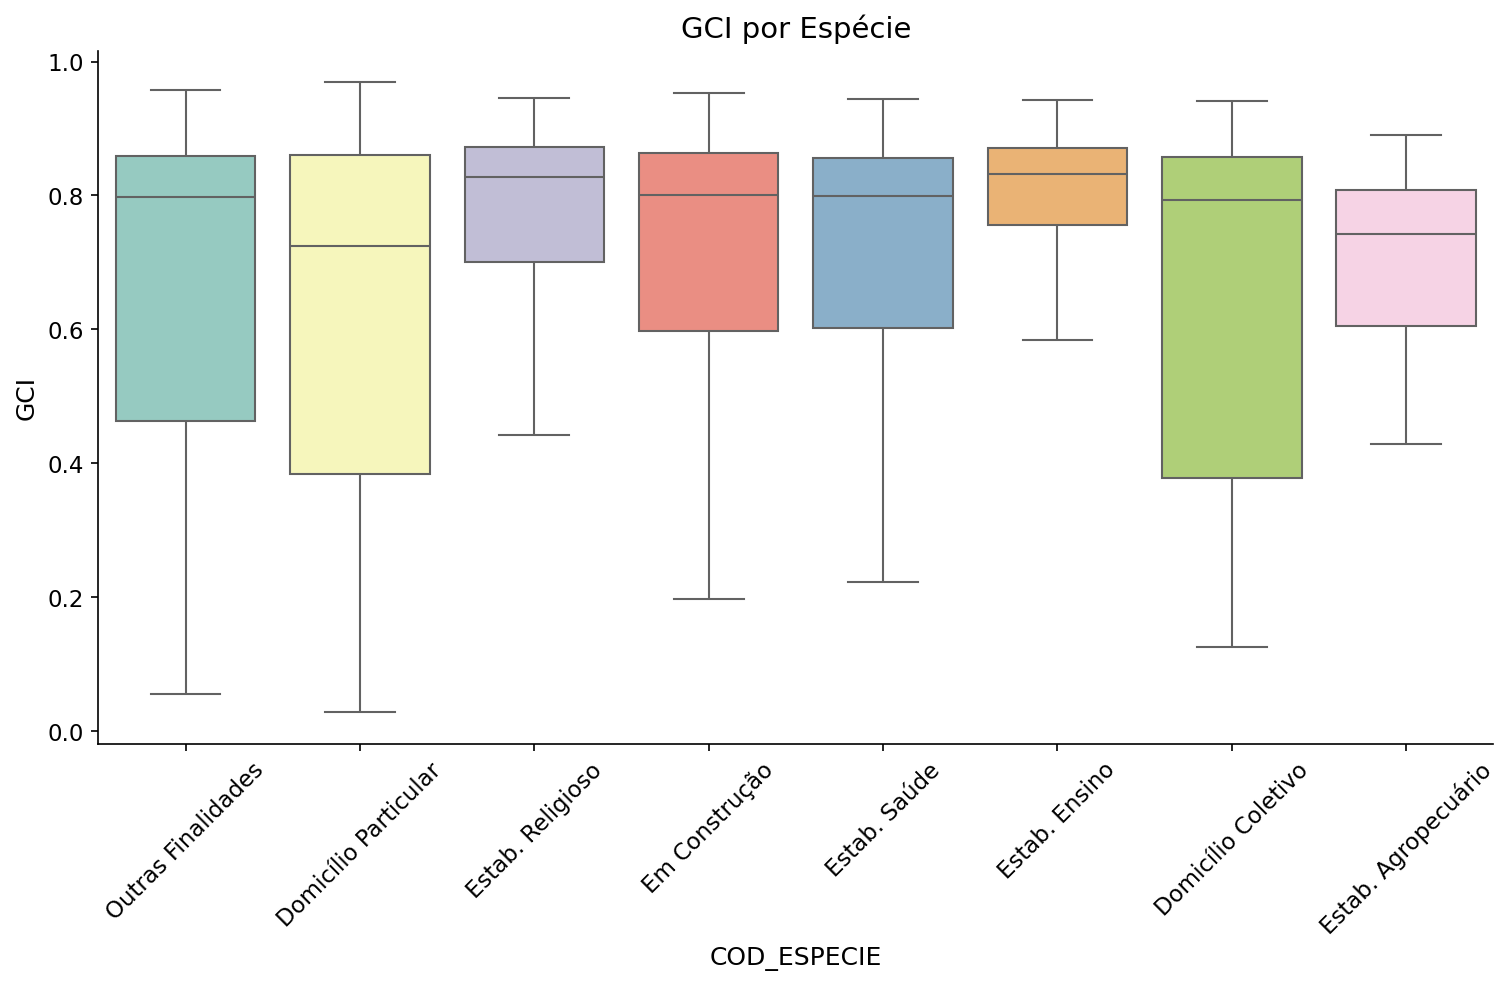

In [2]:
especie_lbl = gdf['COD_ESPECIE'].map(config.ESPECIE_MAP).fillna('Outros')
stats_especie = metrics_by_segment(gdf, especie_lbl)
display(stats_especie)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(x=especie_lbl, y=gdf['GCI'], palette='Set3', showfliers=False, ax=ax)
ax.set_title('GCI por Espécie', fontsize=14)
plt.xticks(rotation=45)
plt.savefig(config.FIG_DIR / 'nb09_boxplot_especie.png', dpi=200, bbox_inches='tight')
plt.show()

A distribuição do GCI por espécie revela um padrão contra-intuitivo: estabelecimentos de ensino e religiosos tendem a ter GCI superior ao de domicílios particulares. Esse resultado reflete que endereços institucionais são pontos únicos de referência (CDI=1, sem colapso de coordenadas), recebendo portanto PCI_emp = 1,0 independentemente da localização.

## 2b. Tipologia Construtiva: Casa vs Apartamento vs Casa de Vila (H1)

**H1**: Apartamentos têm GCI inferior às casas porque um único GPS representa dezenas de unidades, incerteza de identidade intrínseca (Davis & Fonseca, 2007).

Variável: `COD_TIPO_ESPECI`, 101=Casa, 102=Casa de Vila/Condomínio, 103=Apartamento.

,n,GCI_mediana,GCI_medio,LCI_medio,MCI_medio,erro_mediano,RMSE
tipo_lbl,,,,,,,
Apartamento,"399,645",0.358,0.356,0.909,0.784,8.9m,21.3m
Casa,"583,600",0.849,0.807,0.995,0.821,5.5m,10.3m
Casa de Vila/Condomínio,"25,707",0.786,0.721,0.987,0.764,6.1m,16.7m
Outros,"11,827",0.815,0.741,0.988,0.777,6.5m,17.2m


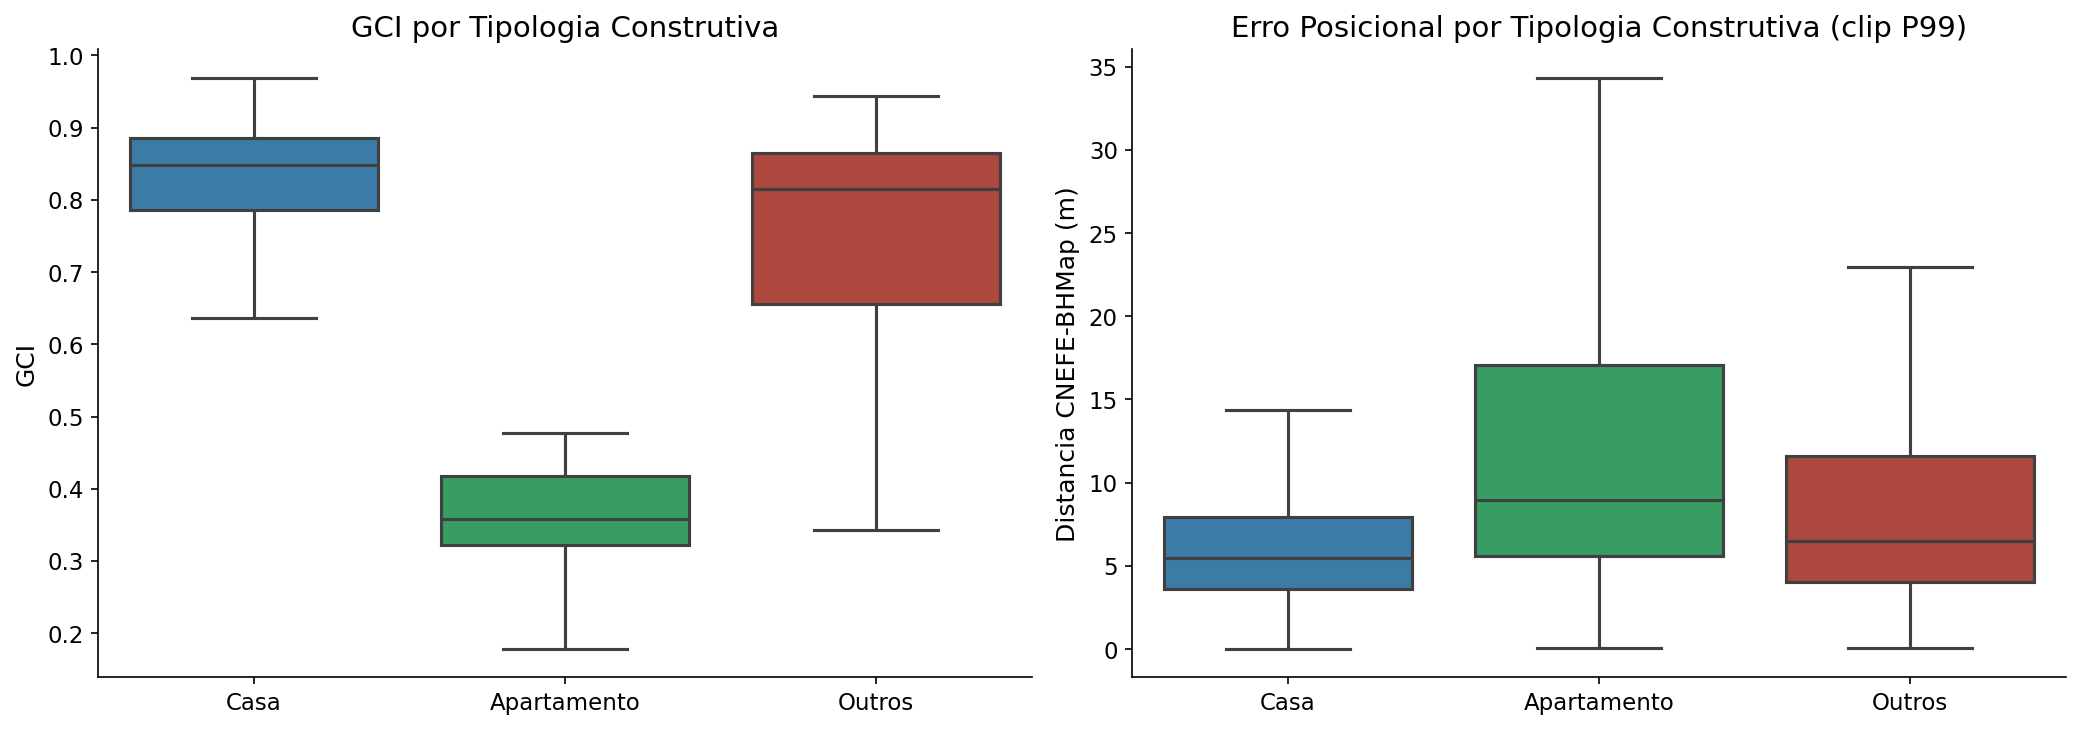


Kruskal-Wallis GCI:    H=674100.2, p=0.00e+00
Kruskal-Wallis Erro:   H=115220.3, p=0.00e+00
Mann-Whitney Casa vs Apartamento (GCI):
  r=-0.9632, p=0.00e+00, GCI Casa=0.807, GCI Apto=0.356


Mann-Whitney Casa vs Apartamento (Erro Posicional):
  r=0.4030, p=0.00e+00, Erro Casa=7.2m, Erro Apto=14.6m


In [3]:

tipo_lbl = gdf['COD_TIPO_ESPECI'].map(config.TIPO_ESPECIE_MAP).fillna('N/A')
mask_tipo = tipo_lbl != 'N/A'
gdf_tipo = gdf[mask_tipo].copy()
gdf_tipo['tipo_lbl'] = tipo_lbl[mask_tipo]

# --- Tabela descritiva por tipo construtivo ---
tab_tipo = gdf_tipo.groupby('tipo_lbl').agg(
    n=('GCI', 'count'),
    GCI_mediana=('GCI', 'median'),
    GCI_medio=('GCI', 'mean'),
    LCI_medio=('LCI', 'mean'),
    MCI_medio=('MCI', 'mean'),
    erro_mediano=('match_distance', 'median'),
    RMSE=('match_distance', lambda x: np.sqrt(np.mean(x.dropna()**2)))
).round(3)

display(tab_tipo.style
    .background_gradient(subset=['GCI_mediana', 'GCI_medio', 'LCI_medio', 'MCI_medio'],
                          cmap='RdYlGn', vmin=0, vmax=1)
    .background_gradient(subset=['RMSE', 'erro_mediano'], cmap='OrRd')
    .format({'n': '{:,.0f}', 'GCI_mediana': '{:.3f}', 'GCI_medio': '{:.3f}',
             'LCI_medio': '{:.3f}', 'MCI_medio': '{:.3f}',
             'erro_mediano': '{:.1f}m', 'RMSE': '{:.1f}m'})
    .set_caption('Métricas de qualidade por tipologia construtiva (COD_TIPO_ESPECI)'))

# --- Boxplots estáticos: GCI e erro posicional por tipologia construtiva ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
tipo_order = ['Casa', 'Casa de Vila/Condominio', 'Apartamento', 'Outros']
tipo_order = [t for t in tipo_order if t in gdf_tipo['tipo_lbl'].unique()]
colors_tipo = ['#2980b9', '#27ae60', '#c0392b', '#7f8c8d']
palette_tipo = {t: c for t, c in zip(tipo_order, colors_tipo)}

sns.boxplot(data=gdf_tipo, x='tipo_lbl', y='GCI', order=tipo_order,
            palette=palette_tipo, ax=axes[0], showfliers=False, linewidth=1.5)
axes[0].set_title('GCI por Tipologia Construtiva')
axes[0].set_xlabel('')
axes[0].set_ylabel('GCI')

dist_col = 'match_distance'
if dist_col in gdf_tipo.columns:
    p99 = gdf_tipo[dist_col].quantile(0.99)
    gdf_tipo_plot = gdf_tipo.copy()
    gdf_tipo_plot[dist_col] = gdf_tipo_plot[dist_col].clip(0, p99)
    sns.boxplot(data=gdf_tipo_plot, x='tipo_lbl', y=dist_col, order=tipo_order,
                palette=palette_tipo, ax=axes[1], showfliers=False, linewidth=1.5)
    axes[1].set_title('Erro Posicional por Tipologia Construtiva (clip P99)')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('Distancia CNEFE-BHMap (m)')

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb09_boxplot_tipo_gci.png', dpi=200, bbox_inches='tight')
plt.show()

# --- Testes estatísticos ---
kw_gci = kruskal_wallis_test(gdf_tipo, 'GCI', 'tipo_lbl')
kw_err = kruskal_wallis_test(gdf_tipo, 'match_distance', 'tipo_lbl')
print(f"\nKruskal-Wallis GCI:    H={kw_gci['H']:.1f}, p={kw_gci['p_value']:.2e}")
print(f"Kruskal-Wallis Erro:   H={kw_err['H']:.1f}, p={kw_err['p_value']:.2e}")

mw = mann_whitney_test(gdf_tipo, 'GCI', 'tipo_lbl', 'Casa', 'Apartamento')
print(f"Mann-Whitney Casa vs Apartamento (GCI):")
print(f"  r={mw['effect_size_r']:.4f}, p={mw['p_value']:.2e}, "
      f"GCI Casa={mw['mean_a']:.3f}, GCI Apto={mw['mean_b']:.3f}")
mw_err = mann_whitney_test(gdf_tipo, 'match_distance', 'tipo_lbl', 'Casa', 'Apartamento')
print(f"Mann-Whitney Casa vs Apartamento (Erro Posicional):")
print(f"  r={mw_err['effect_size_r']:.4f}, p={mw_err['p_value']:.2e}, "
      f"Erro Casa={mw_err['mean_a']:.1f}m, Erro Apto={mw_err['mean_b']:.1f}m")


## 2c. Uso do Endereço: Residencial vs Comercial vs Institucional

Estabelecimentos institucionais (ensino, saúde) têm CDI=1 por definição, são pontos únicos, e portanto PCI_emp=1,0. Endereços comerciais podem ter menor precisão onde há numeração irregular ou lotes com uso heterogêneo.

,n,GCI_mediana,GCI_medio,LCI_medio,MCI_medio,erro_mediano,RMSE
uso_fn,,,,,,,
Comercial/Serviços,"125,070",0.798,0.701,0.993,0.801,6.8m,12.6m
Educação,"2,030",0.833,0.782,0.989,0.803,7.9m,15.0m
Em Construção,"18,722",0.801,0.710,0.991,0.769,7.0m,20.5m
Religioso,"3,788",0.827,0.762,0.997,0.804,6.5m,12.2m
Residencial,"1,020,779",0.724,0.627,0.961,0.805,6.4m,15.8m
Saúde,"2,480",0.800,0.714,0.986,0.793,7.8m,14.4m


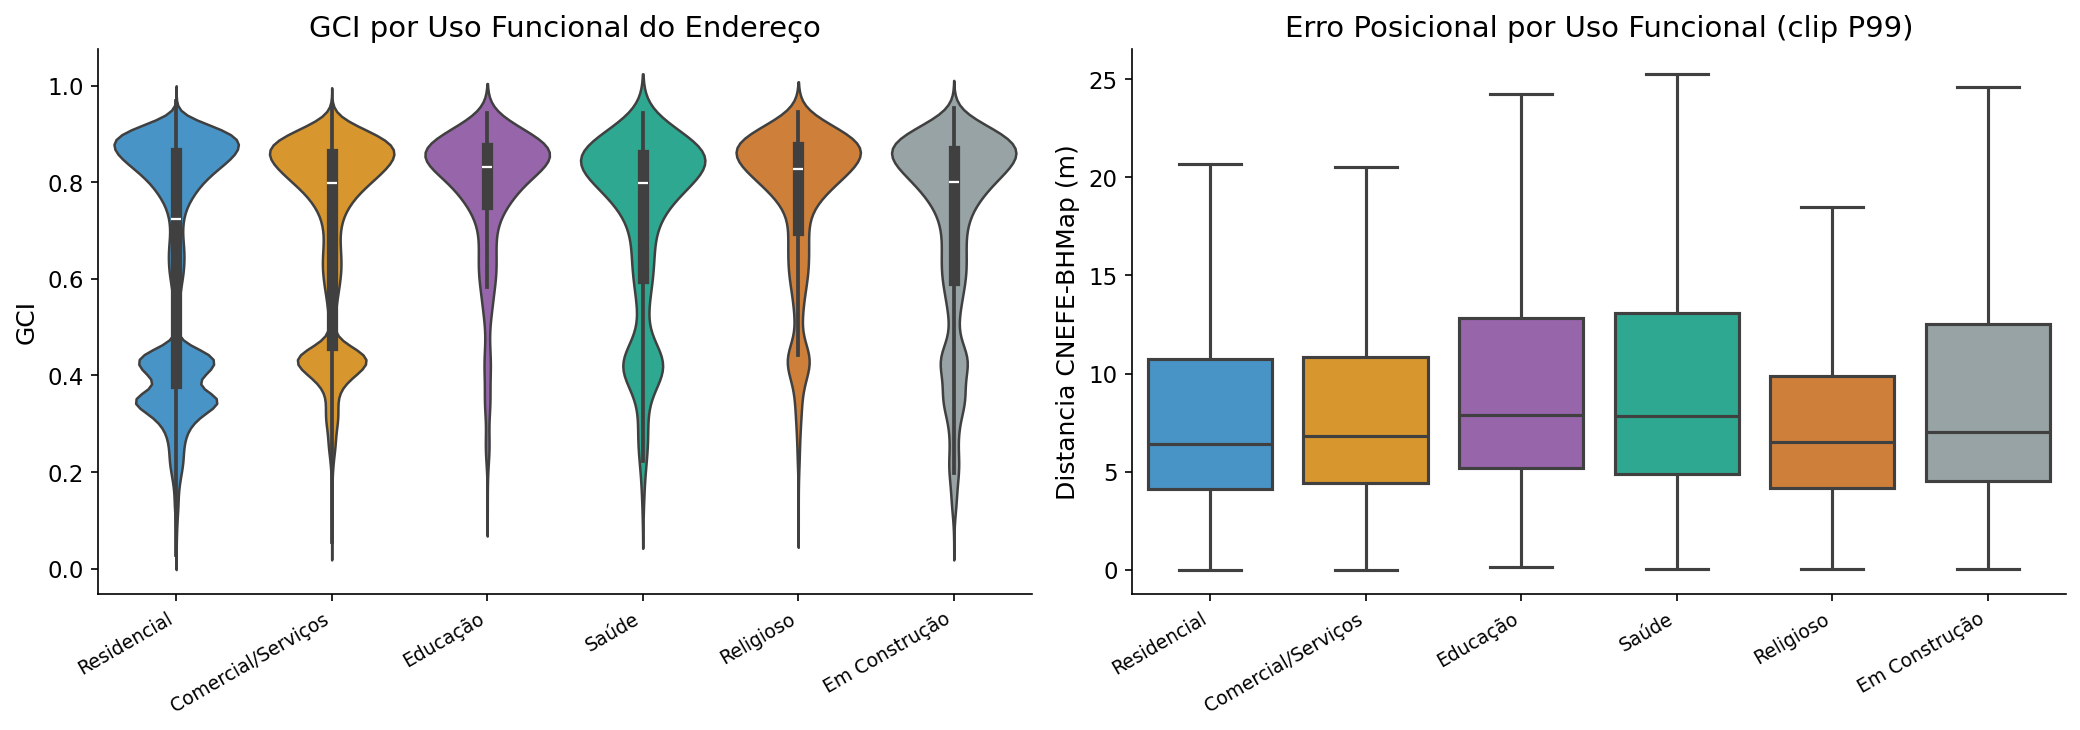


Kruskal-Wallis GCI:  H=9221.7, p=0.00e+00
Kruskal-Wallis Erro: H=860.2, p=1.10e-183

Mann-Whitney Residencial vs Comercial/Servicos (GCI):
  r=nan, p=nan, GCI Resid=nan, GCI Comerc=nan


In [4]:
USO_MAP = {
    1: 'Residencial', 2: 'Residencial',
    3: 'Agropecuário',
    4: 'Educação', 5: 'Saúde', 8: 'Religioso',
    6: 'Comercial/Serviços',
    7: 'Em Construção',
}
uso_order = ['Residencial', 'Comercial/Serviços', 'Educação', 'Saúde', 'Religioso', 'Em Construção']
uso_colors = ['#3498db', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#95a5a6']
palette_uso = {u: c for u, c in zip(uso_order, uso_colors)}

gdf_uso_fn = gdf.copy()
gdf_uso_fn['uso_fn'] = gdf_uso_fn['COD_ESPECIE'].map(USO_MAP).fillna('Outros')
uso_present = [u for u in uso_order if u in gdf_uso_fn['uso_fn'].unique()]

# --- Tabela descritiva por uso funcional ---
tab_uso = gdf_uso_fn[gdf_uso_fn['uso_fn'].isin(uso_present)].groupby('uso_fn').agg(
    n=('GCI', 'count'),
    GCI_mediana=('GCI', 'median'),
    GCI_medio=('GCI', 'mean'),
    LCI_medio=('LCI', 'mean'),
    MCI_medio=('MCI', 'mean'),
    erro_mediano=('match_distance', 'median'),
    RMSE=('match_distance', lambda x: np.sqrt(np.mean(x.dropna()**2)))
).round(3)

display(tab_uso.style
    .background_gradient(subset=['GCI_mediana', 'GCI_medio', 'LCI_medio', 'MCI_medio'],
                          cmap='RdYlGn', vmin=0, vmax=1)
    .background_gradient(subset=['RMSE', 'erro_mediano'], cmap='OrRd')
    .format({'n': '{:,.0f}', 'GCI_mediana': '{:.3f}', 'GCI_medio': '{:.3f}',
             'LCI_medio': '{:.3f}', 'MCI_medio': '{:.3f}',
             'erro_mediano': '{:.1f}m', 'RMSE': '{:.1f}m'})
    .set_caption('Métricas de qualidade por uso funcional do endereço (COD_ESPECIE agrupado)'))

# --- Violin/boxplot estático: GCI e erro por uso funcional ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gdf_uso_fn_filt = gdf_uso_fn[gdf_uso_fn['uso_fn'].isin(uso_present)].copy()
sns.violinplot(data=gdf_uso_fn_filt, x='uso_fn', y='GCI', order=uso_present,
               palette=palette_uso, inner='box', ax=axes[0], linewidth=1.2)
axes[0].set_title('GCI por Uso Funcional do Endereço')
axes[0].set_xlabel('')
axes[0].set_ylabel('GCI')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right', fontsize=9)

p99_uso = gdf_uso_fn_filt['match_distance'].quantile(0.99)
gdf_uso_fn_filt = gdf_uso_fn_filt.copy()
gdf_uso_fn_filt['dist_clip'] = gdf_uso_fn_filt['match_distance'].clip(0, p99_uso)
sns.boxplot(data=gdf_uso_fn_filt, x='uso_fn', y='dist_clip', order=uso_present,
            palette=palette_uso, ax=axes[1], showfliers=False, linewidth=1.5)
axes[1].set_title('Erro Posicional por Uso Funcional (clip P99)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Distancia CNEFE-BHMap (m)')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right', fontsize=9)

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb09_violin_uso_fn_gci.png', dpi=200, bbox_inches='tight')
plt.show()

# --- Kruskal-Wallis ---
kw_gci_uso = kruskal_wallis_test(gdf_uso_fn_filt, 'GCI', 'uso_fn')
kw_err_uso = kruskal_wallis_test(gdf_uso_fn_filt, 'match_distance', 'uso_fn')
print(f"\nKruskal-Wallis GCI:  H={kw_gci_uso['H']:.1f}, p={kw_gci_uso['p_value']:.2e}")
print(f"Kruskal-Wallis Erro: H={kw_err_uso['H']:.1f}, p={kw_err_uso['p_value']:.2e}")

mw_res_com = mann_whitney_test(gdf_uso_fn_filt, 'GCI', 'uso_fn', 'Residencial', 'Comercial/Servicos')
print(f"\nMann-Whitney Residencial vs Comercial/Servicos (GCI):")
print(f"  r={mw_res_com['effect_size_r']:.4f}, p={mw_res_com['p_value']:.2e}, "
      f"GCI Resid={mw_res_com['mean_a']:.3f}, GCI Comerc={mw_res_com['mean_b']:.3f}")


> **Relação com NB10:** A análise completa de informalidade × GCI_empírico, incluindo mapa bivariado GCI×informalidade, curvas de Lorenz/Gini e estratificação por TIPO_ASSENTAMENTO, está no **[Notebook 10](10_segmentacao_uso.ipynb)**. A presente seção realiza a comparação básica formal/informal para contextualizar as hipóteses H4 no escopo tipológico deste notebook.

## 2d. Condição de Assentamento: Área Formal vs Assentamento Informal

**Hipótese H6**: Endereços localizados em assentamentos informais (vilas e favelas) têm GCI significativamente inferior, pois a ausência de endereçamento oficial e a dificuldade de acesso físico reduzem a precisão GPS e a correspondência com o BHMap.

**Metodologia**: Spatial join com o shapefile oficial de Vilas e Favelas da PBH (`VILA_FAVELA.shp`).

Vilas/Favelas (PBH): 218 polígonos


  Residencial em assentamento informal: 115,547 (11.3%)
  Residencial em área formal:           905,232 (88.7%)


,n,GCI_mediana,GCI_medio,LCI_medio,MCI_medio,erro_mediano,RMSE
cond_assentamento,,,,,,,
Area de Ocupacao Formal,"905,232",0.663,0.612,0.957,0.809,6.6m,16.4m
Assentamento Informal (Vila/Favela),"115,547",0.799,0.747,0.990,0.773,4.8m,9.1m


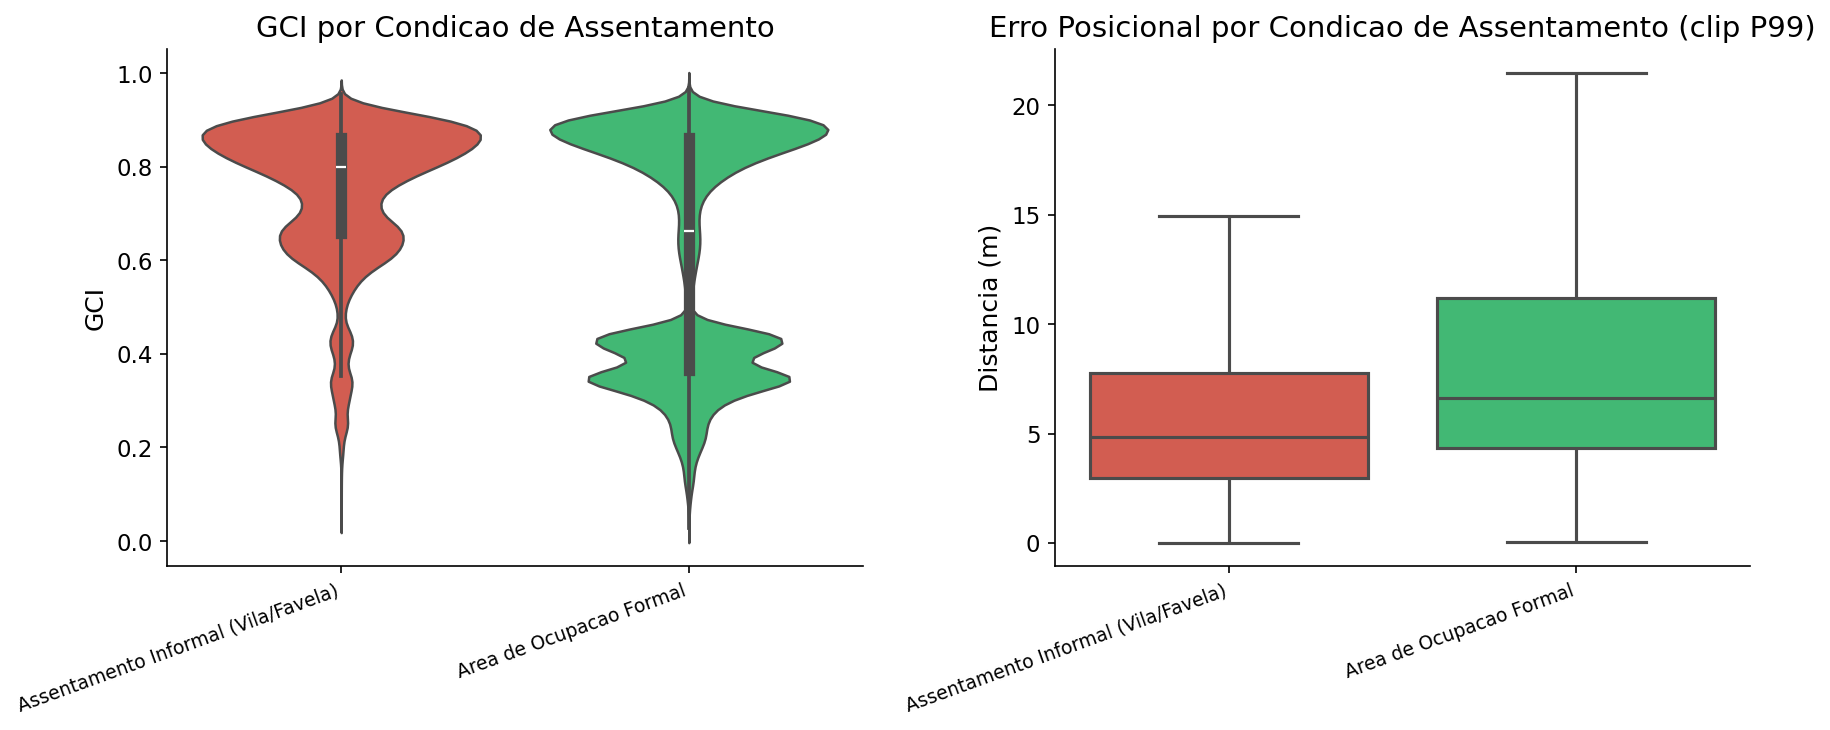

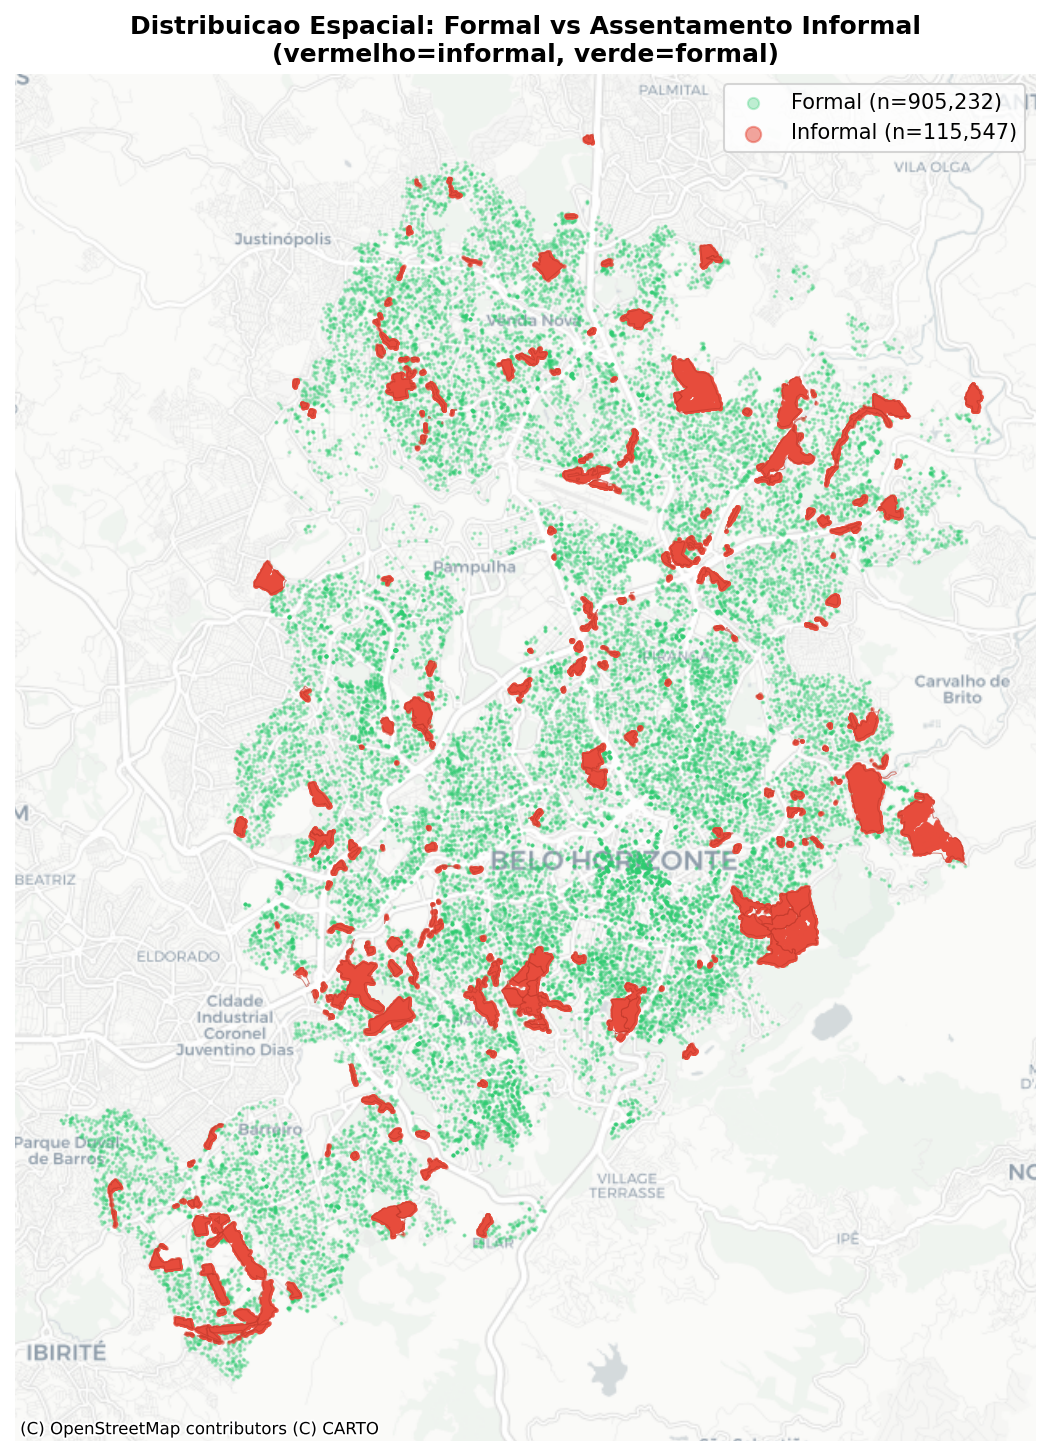


Mann-Whitney Formal vs Informal (GCI):
  r=0.2306, p=0.00e+00
  GCI Formal=0.612, GCI Informal=0.747

Mann-Whitney Formal vs Informal (Erro Posicional):
  r=-0.2684, p=0.00e+00
  Erro Formal=10.7m, Erro Informal=6.5m


In [5]:
import contextily as ctx

# --- Identificação de assentamentos informais via PBH (VILAS_FAVELAS_SHP) ---
vilas = gpd.read_file(config.VILAS_FAVELAS_SHP).to_crs(config.TARGET_CRS)
print(f"Vilas/Favelas (PBH): {len(vilas):,} polígonos")

gdf_inf = gdf[gdf['COD_ESPECIE'].isin([1, 2])].copy()  # apenas residencial para comparação justa
for c in ['index_right', 'em_informal']:
    if c in gdf_inf.columns: gdf_inf.drop(columns=c, inplace=True)

joined = gpd.sjoin(gdf_inf[['geometry']], vilas[['geometry']].assign(em_vila=1),
                   how='left', predicate='within')
joined = joined[~joined.index.duplicated(keep='first')]
gdf_inf['em_informal'] = joined['em_vila'].fillna(0).astype(bool)

n_inf = gdf_inf['em_informal'].sum()
n_form = (~gdf_inf['em_informal']).sum()
print(f"  Residencial em assentamento informal: {n_inf:,} ({n_inf/len(gdf_inf)*100:.1f}%)")
print(f"  Residencial em área formal:           {n_form:,} ({n_form/len(gdf_inf)*100:.1f}%)")

gdf_inf['cond_assentamento'] = np.where(
    gdf_inf['em_informal'],
    'Assentamento Informal (Vila/Favela)',
    'Area de Ocupacao Formal'
)

# --- Tabela comparativa ---
tab_inf = gdf_inf.groupby('cond_assentamento').agg(
    n=('GCI', 'count'),
    GCI_mediana=('GCI', 'median'),
    GCI_medio=('GCI', 'mean'),
    LCI_medio=('LCI', 'mean'),
    MCI_medio=('MCI', 'mean'),
    erro_mediano=('match_distance', 'median'),
    RMSE=('match_distance', lambda x: np.sqrt(np.mean(x.dropna()**2)))
).round(3)
display(tab_inf.style
    .background_gradient(subset=['GCI_mediana', 'GCI_medio', 'LCI_medio', 'MCI_medio'],
                          cmap='RdYlGn', vmin=0, vmax=1)
    .background_gradient(subset=['RMSE', 'erro_mediano'], cmap='OrRd')
    .format({'n': '{:,.0f}', 'GCI_mediana': '{:.3f}', 'GCI_medio': '{:.3f}',
             'LCI_medio': '{:.3f}', 'MCI_medio': '{:.3f}',
             'erro_mediano': '{:.1f}m', 'RMSE': '{:.1f}m'})
    .set_caption('Qualidade de geocodificação: Área Formal vs Assentamento Informal (endereços residenciais)'))

# --- Violinplot/boxplot estático: GCI e erro por condição de assentamento ---
labels_inf = ['Assentamento Informal (Vila/Favela)', 'Area de Ocupacao Formal']
colors_inf = {'Assentamento Informal (Vila/Favela)': '#e74c3c',
              'Area de Ocupacao Formal': '#2ecc71'}
gdf_inf_plot = gdf_inf[gdf_inf['cond_assentamento'].isin(gdf_inf['cond_assentamento'].unique())].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.violinplot(data=gdf_inf_plot, x='cond_assentamento', y='GCI',
               palette=colors_inf, inner='box', ax=axes[0], linewidth=1.2)
axes[0].set_title('GCI por Condicao de Assentamento')
axes[0].set_xlabel('')
axes[0].set_ylabel('GCI')
plt.setp(axes[0].get_xticklabels(), rotation=20, ha='right', fontsize=9)

p99_inf = gdf_inf_plot['match_distance'].quantile(0.99)
gdf_inf_plot['dist_clip'] = gdf_inf_plot['match_distance'].clip(0, p99_inf)
sns.boxplot(data=gdf_inf_plot, x='cond_assentamento', y='dist_clip',
            palette=colors_inf, ax=axes[1], showfliers=False, linewidth=1.5)
axes[1].set_title('Erro Posicional por Condicao de Assentamento (clip P99)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Distancia (m)')
plt.setp(axes[1].get_xticklabels(), rotation=20, ha='right', fontsize=9)

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb09_violin_assentamento_gci.png', dpi=200, bbox_inches='tight')
plt.show()

# --- Mapa: localização dos assentamentos informais vs GCI ---
fig_map, ax_map = plt.subplots(figsize=(12, 10))
sample_form = gdf_inf[~gdf_inf['em_informal']].to_crs(epsg=3857).sample(min(30000, n_form), random_state=42)
sample_inf_pts = gdf_inf[gdf_inf['em_informal']].to_crs(epsg=3857)
ax_map.scatter(sample_form.geometry.x, sample_form.geometry.y,
               c='#2ecc71', s=0.8, alpha=0.3, label=f'Formal (n={n_form:,})')
ax_map.scatter(sample_inf_pts.geometry.x, sample_inf_pts.geometry.y,
               c='#e74c3c', s=1.5, alpha=0.5, label=f'Informal (n={n_inf:,})')
try:
    import contextily as ctx
    try:
        ctx.add_basemap(ax_map, source=ctx.providers.CartoDB.Positron)
    except Exception as e:
        print(f'Warning: Basemap download failed ({e})')
except Exception:
    pass
vilas.to_crs(epsg=3857).boundary.plot(ax=ax_map, color='#c0392b', linewidth=0.5, alpha=0.6)
ax_map.set_title('Distribuicao Espacial: Formal vs Assentamento Informal\n(vermelho=informal, verde=formal)',
                 fontweight='bold', fontsize=12)
ax_map.legend(markerscale=6, fontsize=10)
ax_map.axis('off')
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb09_mapa_assentamento.png', dpi=180, bbox_inches='tight')
plt.show()

# --- Teste estatístico ---
mw_inf = mann_whitney_test(gdf_inf, 'GCI', 'cond_assentamento',
                            'Area de Ocupacao Formal',
                            'Assentamento Informal (Vila/Favela)')
print(f"\nMann-Whitney Formal vs Informal (GCI):")
print(f"  r={mw_inf['effect_size_r']:.4f}, p={mw_inf['p_value']:.2e}")
print(f"  GCI Formal={mw_inf['mean_a']:.3f}, GCI Informal={mw_inf['mean_b']:.3f}")

mw_inf_err = mann_whitney_test(gdf_inf, 'match_distance', 'cond_assentamento',
                                'Area de Ocupacao Formal',
                                'Assentamento Informal (Vila/Favela)')
print(f"\nMann-Whitney Formal vs Informal (Erro Posicional):")
print(f"  r={mw_inf_err['effect_size_r']:.4f}, p={mw_inf_err['p_value']:.2e}")
print(f"  Erro Formal={mw_inf_err['mean_a']:.1f}m, Erro Informal={mw_inf_err['mean_b']:.1f}m")


> **Nota:** A análise formal de IPTU × GCI_empírico (Hipótese H8) foi realizada na **Seção B9** deste notebook, com testes Kruskal-Wallis e Spearman completos. O código abaixo é uma exploração preliminar usando ZH_IPTU diretamente do shapefile.

A variação do GCI médio por Zona Homogênea de IPTU (ZH) mostra o gradiente socioeconômico da qualidade de geocodificação.

,mean,median,std,count
CODIGO_ZH,,,,
LE113,0.888,0.919,0.053,3
CS513,0.876,0.908,0.122,174
VN328,0.875,0.865,0.037,3
CS520,0.873,0.873,nan,1
CS514,0.869,0.894,0.106,25
CS512,0.863,0.864,0.029,3
NT313,0.856,0.887,0.091,289
BA123,0.854,0.885,0.116,84
PA203,0.853,0.889,0.079,50


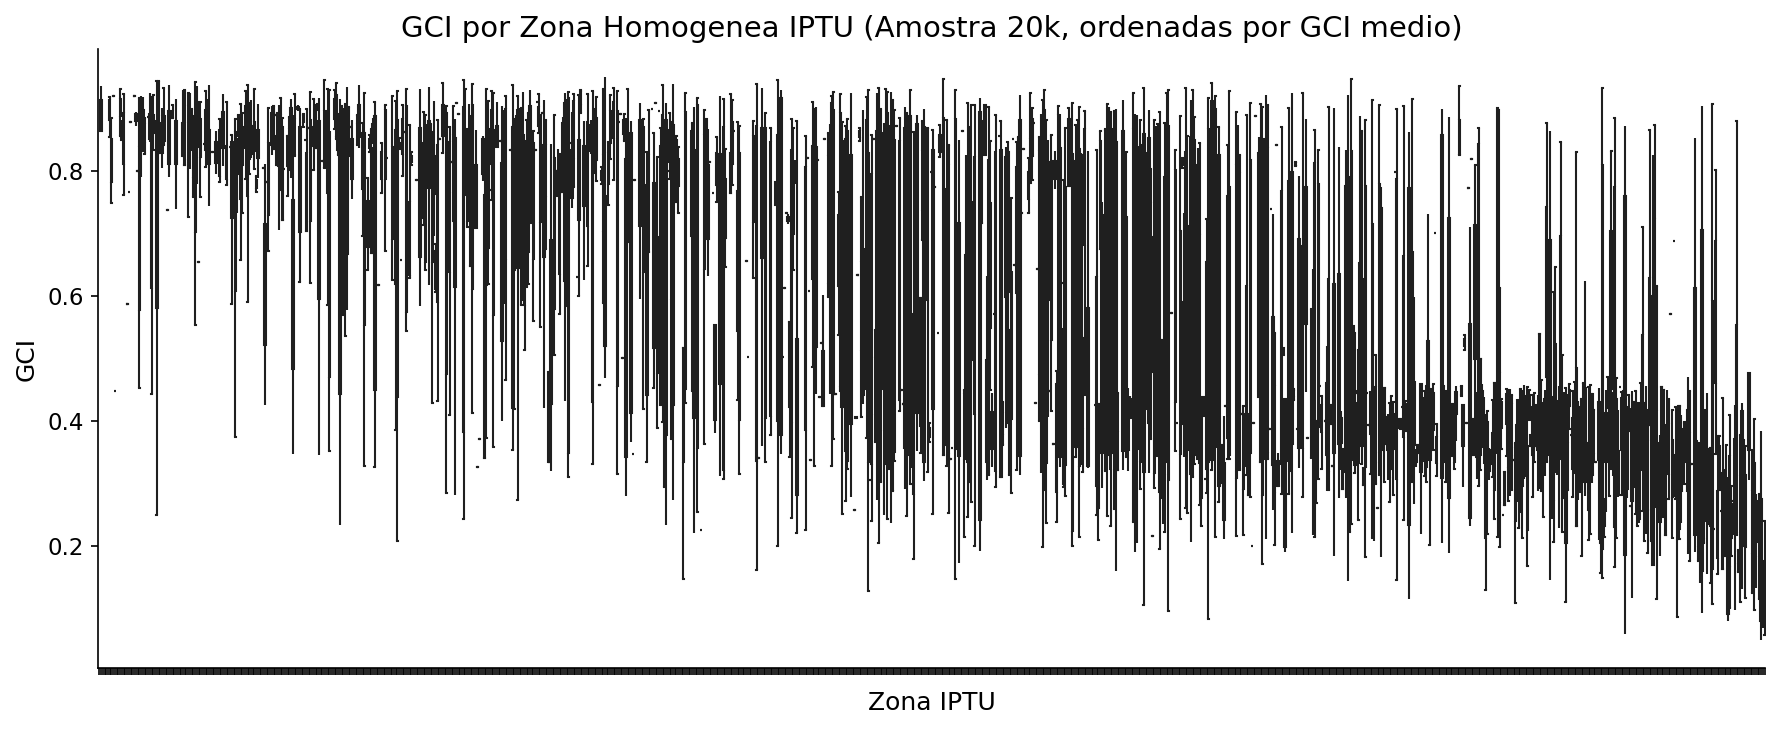

In [6]:
import geopandas as gpd
from src import config

v3_path = config.PROCESSED_DIR / "cnefe_master_metrics.parquet"
if not v3_path.exists():
    raise FileNotFoundError("Arquivo cnefe_master_metrics.parquet nao encontrado.")

gdf_v3 = gpd.read_parquet(v3_path)
gdf_iptu = gdf_v3.copy()
if "ZONA_HOMOGENEA" in gdf_iptu.columns:
    gdf_iptu = gdf_iptu.rename(columns={"ZONA_HOMOGENEA": "CODIGO_ZH"})
elif "CODIGO_ZH" in gdf_iptu.columns:
    pass
else:
    print("AVISO: Coluna ZONA_HOMOGENEA nao encontrada - secao IPTU pulada.")
    gdf_iptu = None

if gdf_iptu is not None:
    gci_col = next((c for c in ["GCI", "GCI_empirico", "GCI_original"] if c in gdf_iptu.columns), None)
    if gci_col and gci_col != "GCI":
        gdf_iptu = gdf_iptu.rename(columns={gci_col: "GCI"})

    stats_iptu = (gdf_iptu.groupby("CODIGO_ZH")["GCI"]
                  .agg(["mean", "median", "std", "count"])
                  .sort_values("mean", ascending=False))

    display(stats_iptu.head(10).round(3).style
        .background_gradient(subset=["mean", "median"], cmap="RdYlGn", vmin=0, vmax=1)
        .background_gradient(subset=["std"], cmap="OrRd")
        .format({"mean": "{:.3f}", "median": "{:.3f}", "std": "{:.3f}", "count": "{:,.0f}"})
        .set_caption("Top 10 Zonas IPTU por GCI Medio"))

    sample_iptu = gdf_iptu.sample(min(20000, len(gdf_iptu)), random_state=42)
    zh_order = stats_iptu.index.tolist()
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.boxplot(data=sample_iptu, x="CODIGO_ZH", y="GCI",
                order=zh_order, palette="RdYlGn",
                ax=ax, showfliers=False, linewidth=1.0)
    ax.set_title("GCI por Zona Homogenea IPTU (Amostra 20k, ordenadas por GCI medio)")
    ax.set_xlabel("Zona IPTU")
    ax.set_ylabel("GCI")
    ax.set_xticklabels([])
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / "nb09_boxplot_iptu_gci.png", dpi=200, bbox_inches="tight")
    plt.show()


### A4. Auditoria de Uso do Solo: CNEFE × Tipologia PBH

Cruzamos a espécie do endereço CNEFE com a tipologia do lote no BHMap (PBH) para verificar consistência entre as duas bases. Uma alta proporção de inconsistências (ex: CNEFE classifica como residencial mas BHMap classifica como comercial) indicaria que uma das bases tem erros de classificação, importante para validar a estratificação tipológica nas análises H1-H4.

> **Continua em A5:** a auditoria de consistencia taxonomica (A4) e complementada pela validacao cruzada formal (A5), que realiza o spatial join ponto-poligono e gera a matriz de concordancia CNEFE x PBH.

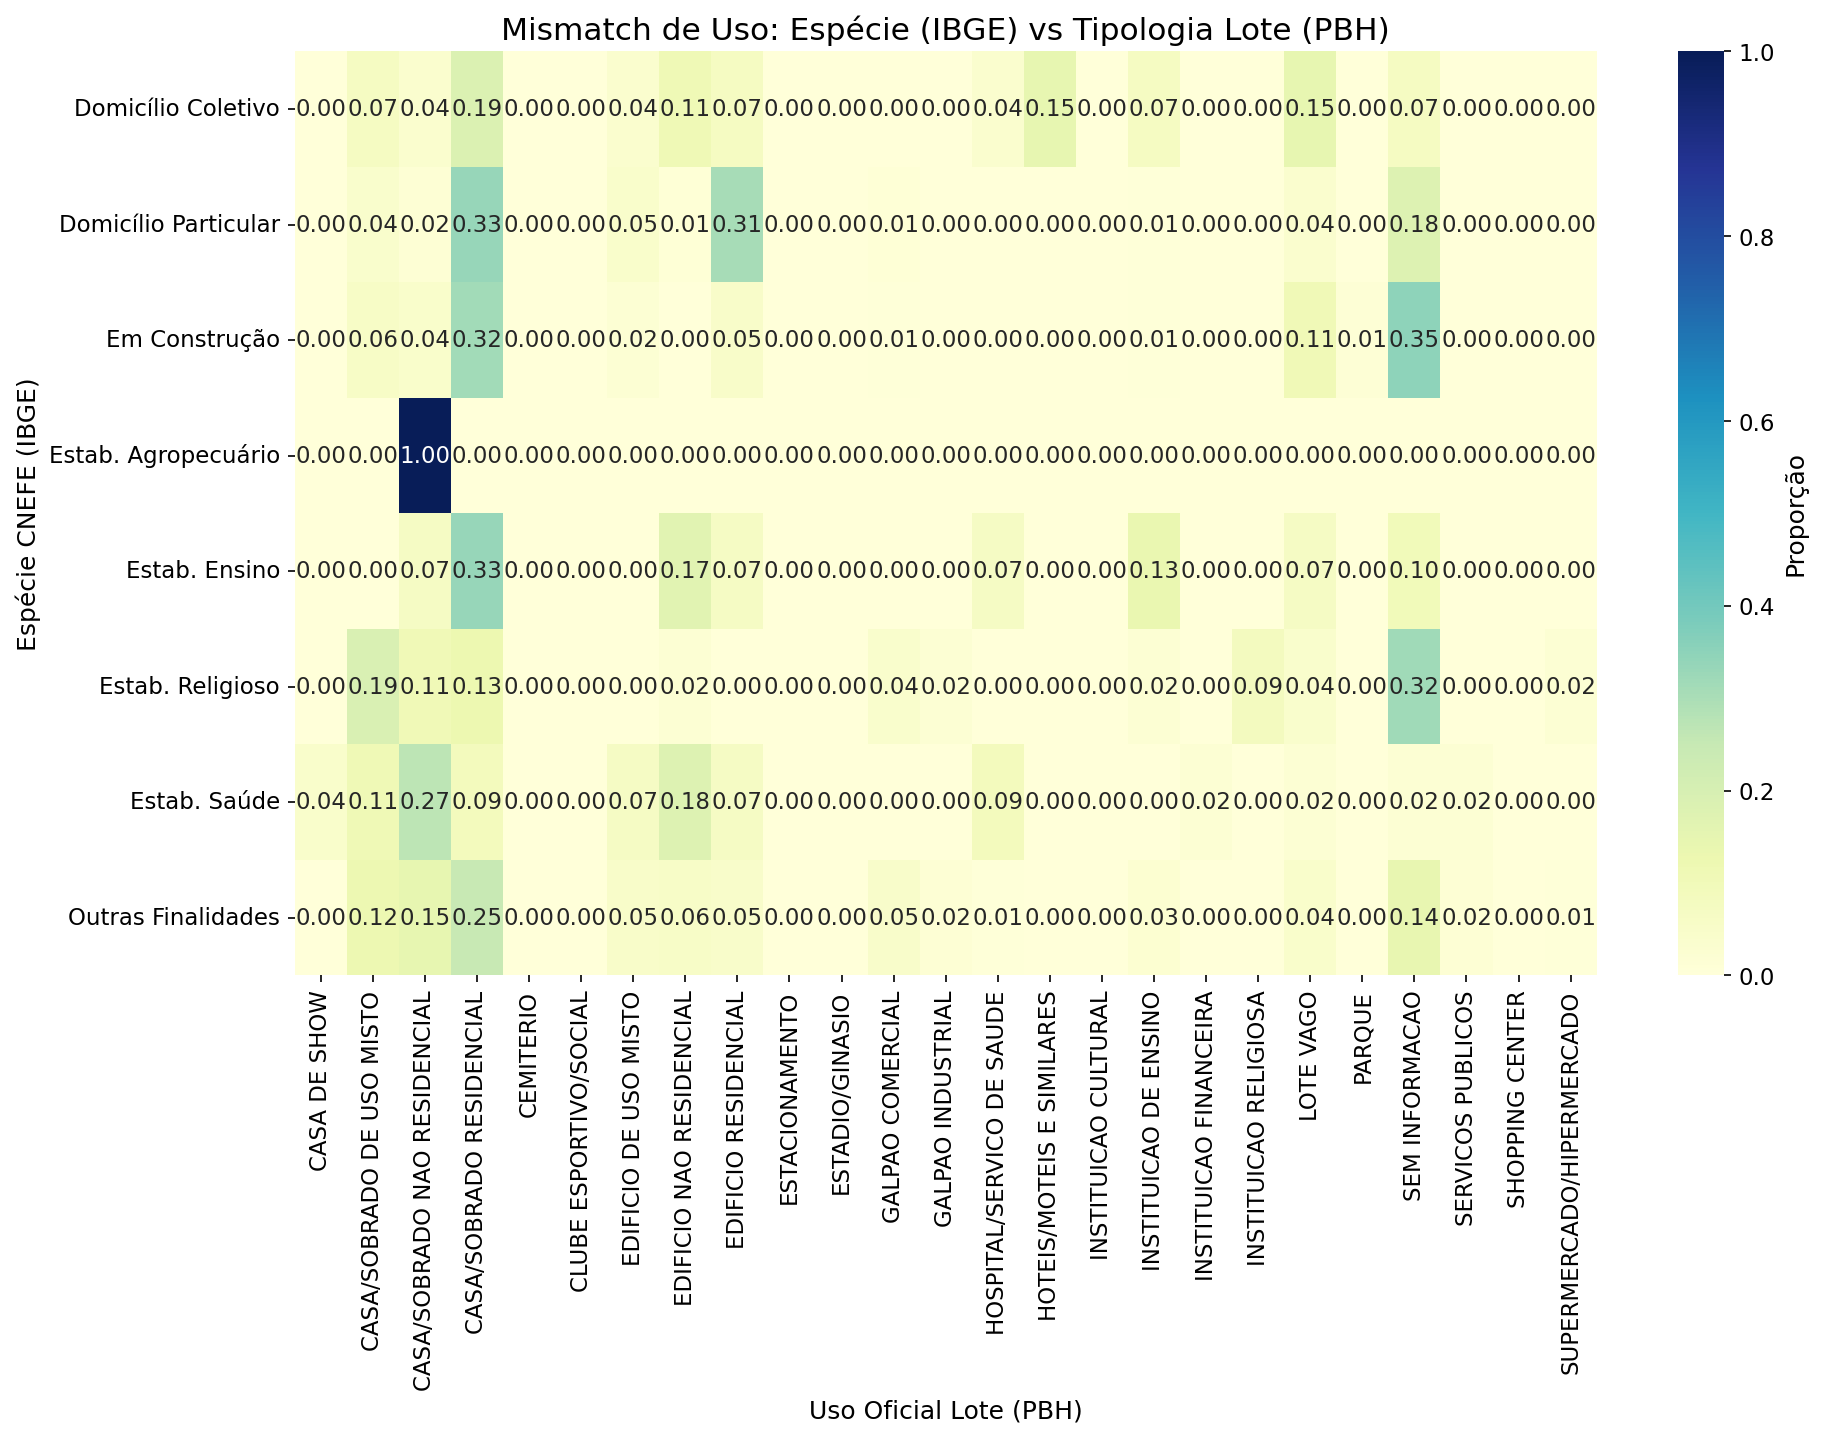

In [7]:
lotes = gpd.read_file(config.LOTE_TIPOLOGIA_SHP).to_crs(config.TARGET_CRS)
gdf_sampled = gdf.sample(min(50000, len(gdf)), random_state=42).reset_index(drop=True)
if "index_right" in gdf_sampled.columns: gdf_sampled = gdf_sampled.drop(columns="index_right")
gdf_lote = gpd.sjoin(gdf_sampled, lotes[['TIPOLOGIA0', 'geometry']], how='left', predicate='within')
gdf_lote = gdf_lote.loc[~gdf_lote.index.duplicated(keep='first')].reset_index(drop=True)

crosstab = pd.crosstab(gdf_lote['COD_ESPECIE'].map(config.ESPECIE_MAP), gdf_lote['TIPOLOGIA0'], normalize='index')

plt.figure(figsize=(14, 8))
sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Proporção'})
plt.title('Mismatch de Uso: Espécie (IBGE) vs Tipologia Lote (PBH)', fontsize=15)
plt.xlabel('Uso Oficial Lote (PBH)')
plt.ylabel('Espécie CNEFE (IBGE)')
plt.savefig(config.FIG_DIR / 'nb09_heatmap_mismatch_uso.png', dpi=200, bbox_inches='tight')
plt.show()


O padrão espacial das inconsistências de uso concentra-se em bordas de vias arteriais, onde o uso do lote muda mais rápido do que o cadastro é atualizado.

## A5. Validação Cruzada: Uso do Solo (CNEFE vs PBH)

O CNEFE classifica endereços por `COD_ESPECIE` (residencial, comercial, ensino, saúde). A PBH classifica **lotes** por uso real (Tipologia de Uso e Ocupação 2022). Cruzar as duas classificações mede a **consistência lógica** do CNEFE.

**Técnica**: Spatial join ponto-in-polígono, seguido de confusion matrix.

**Expectativa**: Alta concordância para uso residencial, menor para comercial (CNEFE agrupa tudo em "Outras Finalidades").

Tipologia Uso: 361573 lotes carregados


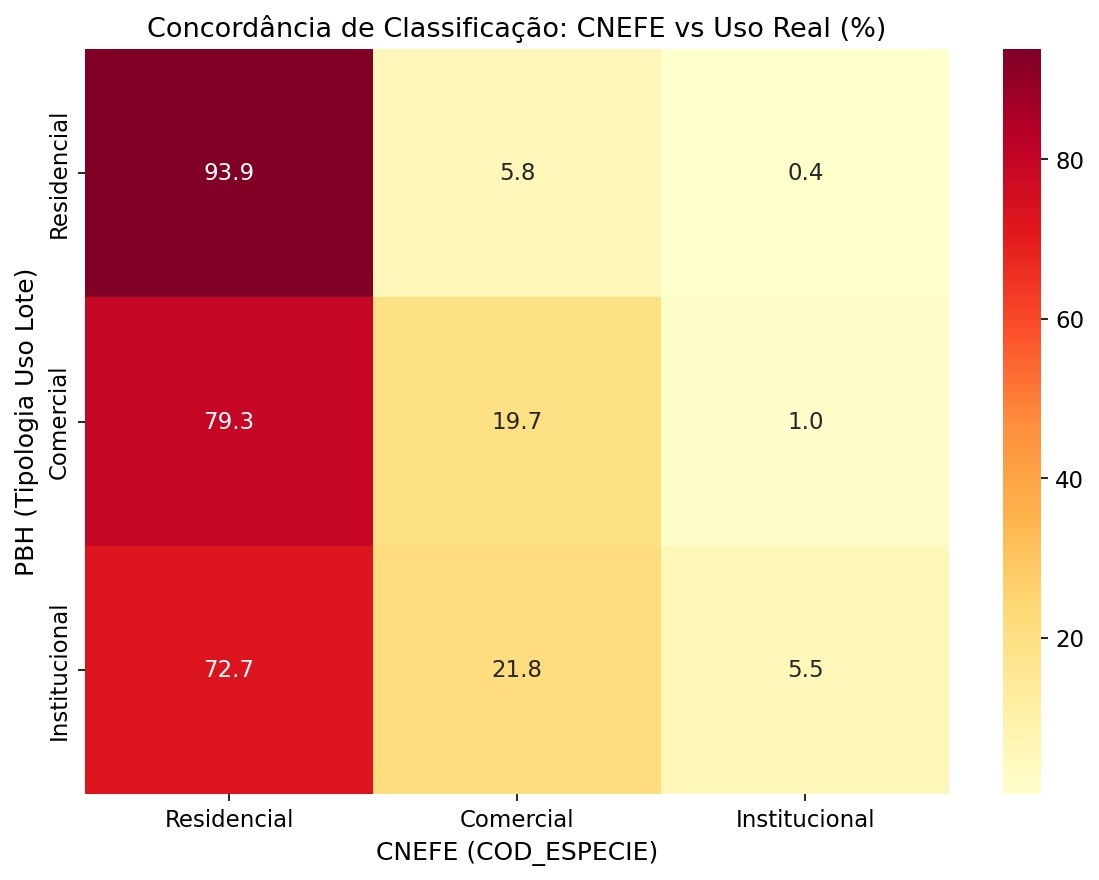


Taxa concordância global: 81.9%


,Residencial,Comercial,Institucional
Residencial,93.9%,5.8%,0.4%
Comercial,79.3%,19.7%,1.0%
Institucional,72.7%,21.8%,5.5%


In [8]:
# A5 — Validação uso do solo
try:
    tipologia = gpd.read_file(config.TIPOLOGIA_USO_SHP).to_crs(config.TARGET_CRS)
    print(f"Tipologia Uso: {len(tipologia)} lotes carregados")

    # Usar TIPOLOGIA0 (categoria real), não índice arbitrário da coluna
    uso_col_src = 'TIPOLOGIA0' if 'TIPOLOGIA0' in tipologia.columns else tipologia.columns[3]

    gdf_uso = gdf.copy()
    for c in ['index_right', 'uso_lote']:
        if c in gdf_uso.columns: gdf_uso.drop(columns=c, inplace=True)

    # Renomear coluna antes do join para evitar conflitos
    gdf_uso = gpd.sjoin(
        gdf_uso,
        tipologia[['geometry', uso_col_src]].rename(columns={uso_col_src: 'uso_lote'}),
        how='left', predicate='within'
    )
    gdf_uso = gdf_uso.loc[~gdf_uso.index.duplicated(keep='first')]

    # Map CNEFE species to broad categories
    cnefe_cat = gdf_uso['COD_ESPECIE'].map({
        1: 'Residencial', 2: 'Residencial', 3: 'Agro',
        4: 'Institucional', 5: 'Institucional', 6: 'Comercial',
        7: 'Outros', 8: 'Institucional'
    }).fillna('Outros')

    # Simplify land use — handle NaN/float values safely
    def map_uso(val):
        if pd.isna(val):
            return np.nan
        val = str(val).upper()
        if any(k in val for k in ['RESID', 'DOMIC']): return 'Residencial'
        if any(k in val for k in ['COMERC', 'SERV', 'MIST']): return 'Comercial'
        if any(k in val for k in ['INST', 'PUBLI', 'EDUC', 'SAUDE']): return 'Institucional'
        return 'Outros'

    uso_simple = gdf_uso['uso_lote'].apply(map_uso)

    from sklearn.metrics import confusion_matrix
    labels = ['Residencial', 'Comercial', 'Institucional']
    mask = uso_simple.isin(labels) & cnefe_cat.isin(labels)
    cm = confusion_matrix(uso_simple[mask], cnefe_cat[mask], labels=labels)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    cm_pct = cm / row_sums * 100

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='YlOrRd',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel('CNEFE (COD_ESPECIE)')
    ax.set_ylabel('PBH (Tipologia Uso Lote)')
    ax.set_title('Concordância de Classificação: CNEFE vs Uso Real (%)', fontsize=13)
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb09_confusion_uso_solo.png', dpi=200, bbox_inches='tight')
    plt.show()

    taxa_global = np.diag(cm).sum() / cm.sum() * 100
    print(f"\nTaxa concordância global: {taxa_global:.1f}%")
    display(pd.DataFrame(cm_pct, index=labels, columns=labels).round(1).style
        .background_gradient(cmap='YlOrRd', vmin=0, vmax=100)
        .format('{:.1f}%')
        .set_caption(f'Matriz de concordância CNEFE vs PBH (taxa global: {taxa_global:.1f}%)'))
except Exception as e:
    print(f"A5 skipped: {e}")

A matriz de confusão CNEFE × PBH quantifica o grau de inconsistência classificatória. Alta proporção off-diagonal indica que uma das bases classifica o uso de forma diferente da outra, não necessariamente que esteja errada, já que as metodologias de classificação diferem.

## A6. Análise Exploratória: Hierarquia Viária (Referência)

> **Nota:** A análise formal de hierarquia viária × GCI_empírico foi realizada na **Seção B6 deste notebook, utilizando as variáveis contextuais BHMap (`VIA_CLASSIFICA`, `VIA_HIERARQUIA`) com testes estatísticos completos (Kruskal-Wallis, Spearman e visualizações padronizadas). O código abaixo apresenta uma visualização exploratória preliminar usando a camada `CLASSIFICACAO_VIARIA` do BHMap.

Classificação Viária: 54411 trechos
Colunas: ['ID_CLASSIF', 'TP_LOG', 'NO_LOG', 'CLASSIFICA', 'SUBDIVISAO', 'AFASTAMENT', 'TIPO_LARGU', 'DESCRICAO_', 'geometry']


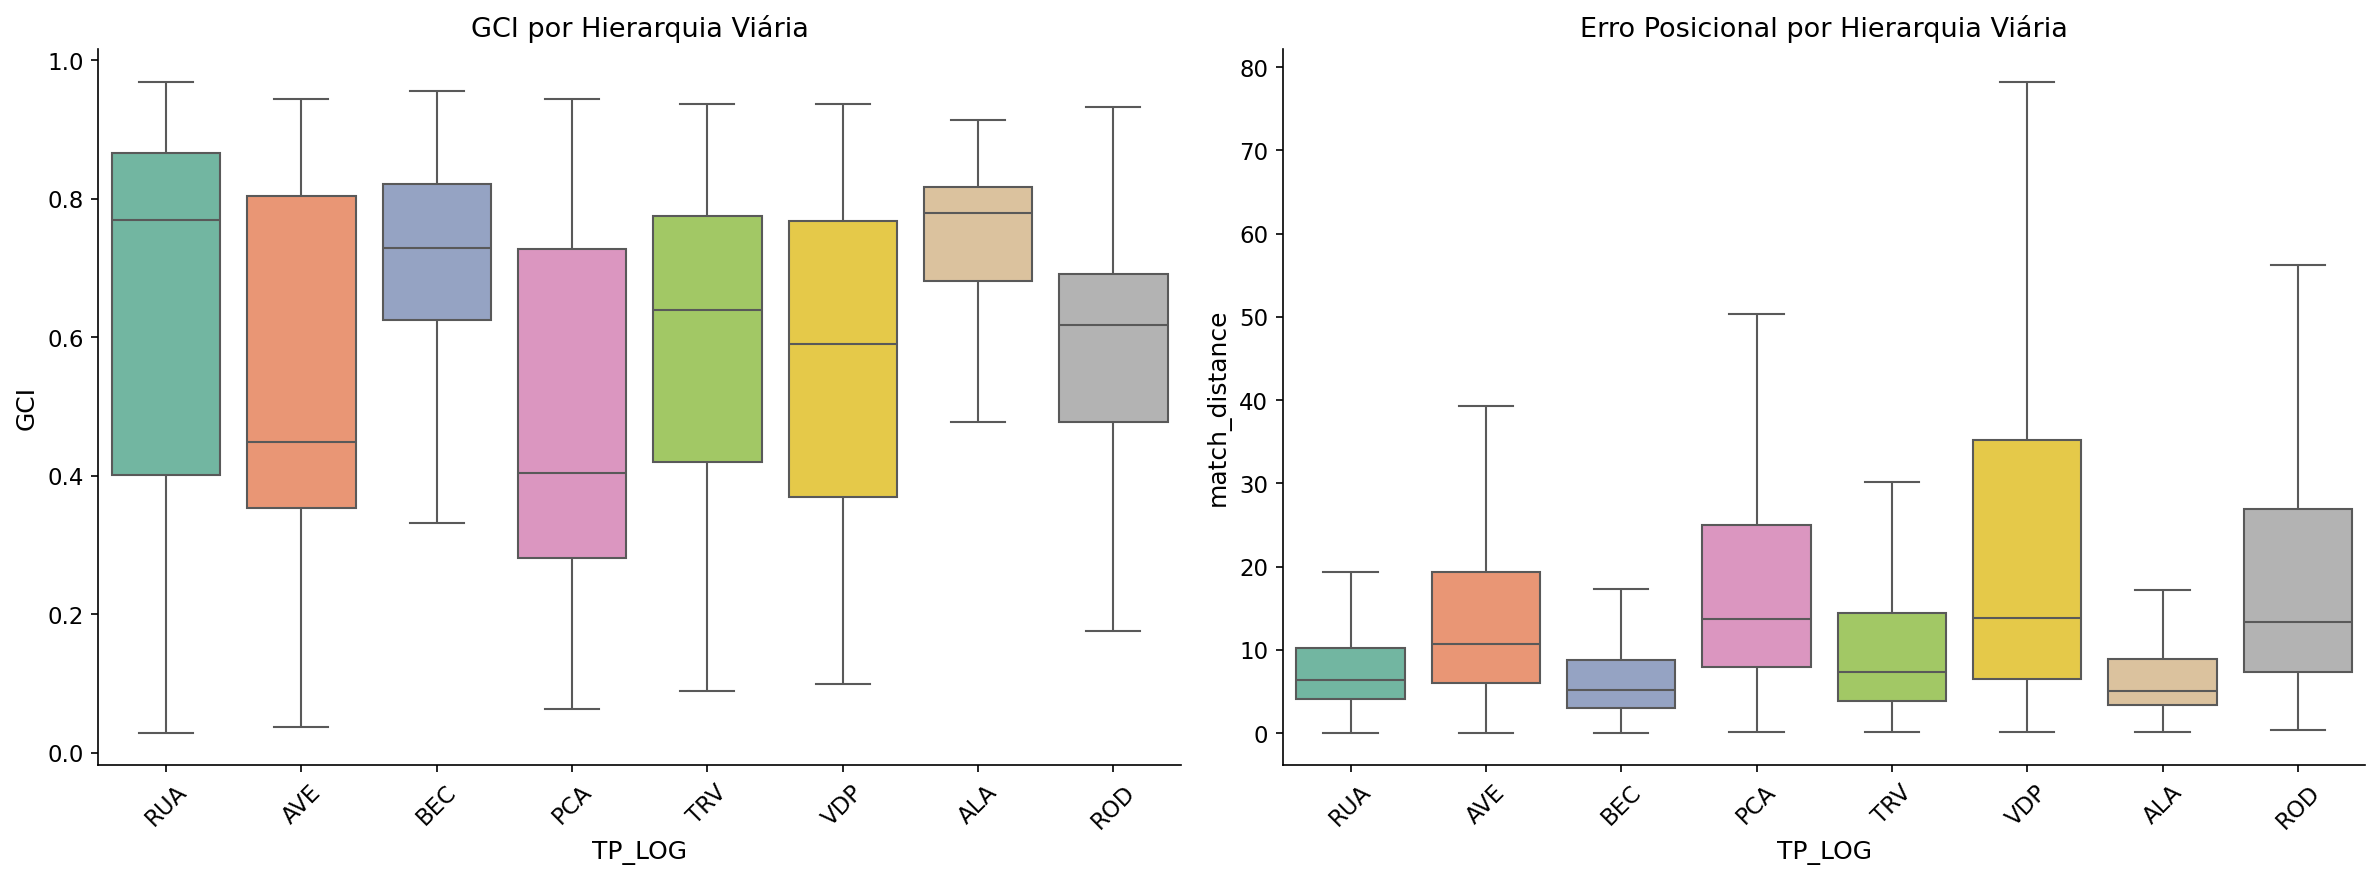


Kruskal-Wallis H=18361.62, p=0.00e+00, Sig: True


In [9]:
# A6 — Hierarquia viária
try:
    vias = gpd.read_file(config.CLASSIFICACAO_VIARIA_SHP).to_crs(config.TARGET_CRS)
    print(f"Classificação Viária: {len(vias)} trechos")
    print(f"Colunas: {list(vias.columns)}")

    # Nearest join (pontos → trechos)
    gdf_via = gdf.copy()
    for c in ['index_right']:
        if c in gdf_via.columns: gdf_via.drop(columns=c, inplace=True)
    gdf_via = gpd.sjoin_nearest(gdf_via, vias[['geometry', vias.columns[1]]], how='left', max_distance=100)
    gdf_via = gdf_via.loc[~gdf_via.index.duplicated(keep='first')]
    via_col = vias.columns[1]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    order = gdf_via[via_col].value_counts().index[:8]

    sns.boxplot(data=gdf_via, x=via_col, y='GCI', order=order, palette='Set2', ax=axes[0], showfliers=False)
    axes[0].set_title('GCI por Hierarquia Viária', fontsize=13)
    axes[0].tick_params(axis='x', rotation=45)

    sns.boxplot(data=gdf_via, x=via_col, y='match_distance', order=order, palette='Set2', ax=axes[1], showfliers=False)
    axes[1].set_title('Erro Posicional por Hierarquia Viária', fontsize=13)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb09_via_hierarquia.png', dpi=200, bbox_inches='tight')
    plt.show()

    kw = kruskal_wallis_test(gdf_via, 'GCI', via_col)
    print(f"\nKruskal-Wallis H={kw['H']:.2f}, p={kw['p_value']:.2e}, Sig: {kw['significativo']}")
except Exception as e:
    print(f"A6 skipped: {e}")

## A7. Correlação Declividade × Erro Posicional

**Hipótese H6**: A declividade do terreno degrada a precisão do GPS.

BH é uma cidade de topografia muito acidentada. Terrenos íngremes criam obstrução de sinal GPS por morros e edificações. Testamos com correlação de Spearman.

Declividade: 58753 trechos
Colunas: ['ID_DECLIV_', 'NOME_LOGRA', 'QTDE_SEGME', 'DECLIVIDAD', 'DECLIVIDA0', 'DECLIVIDA1', 'MEDIANA', 'DESVIO_PAD', 'geometry']


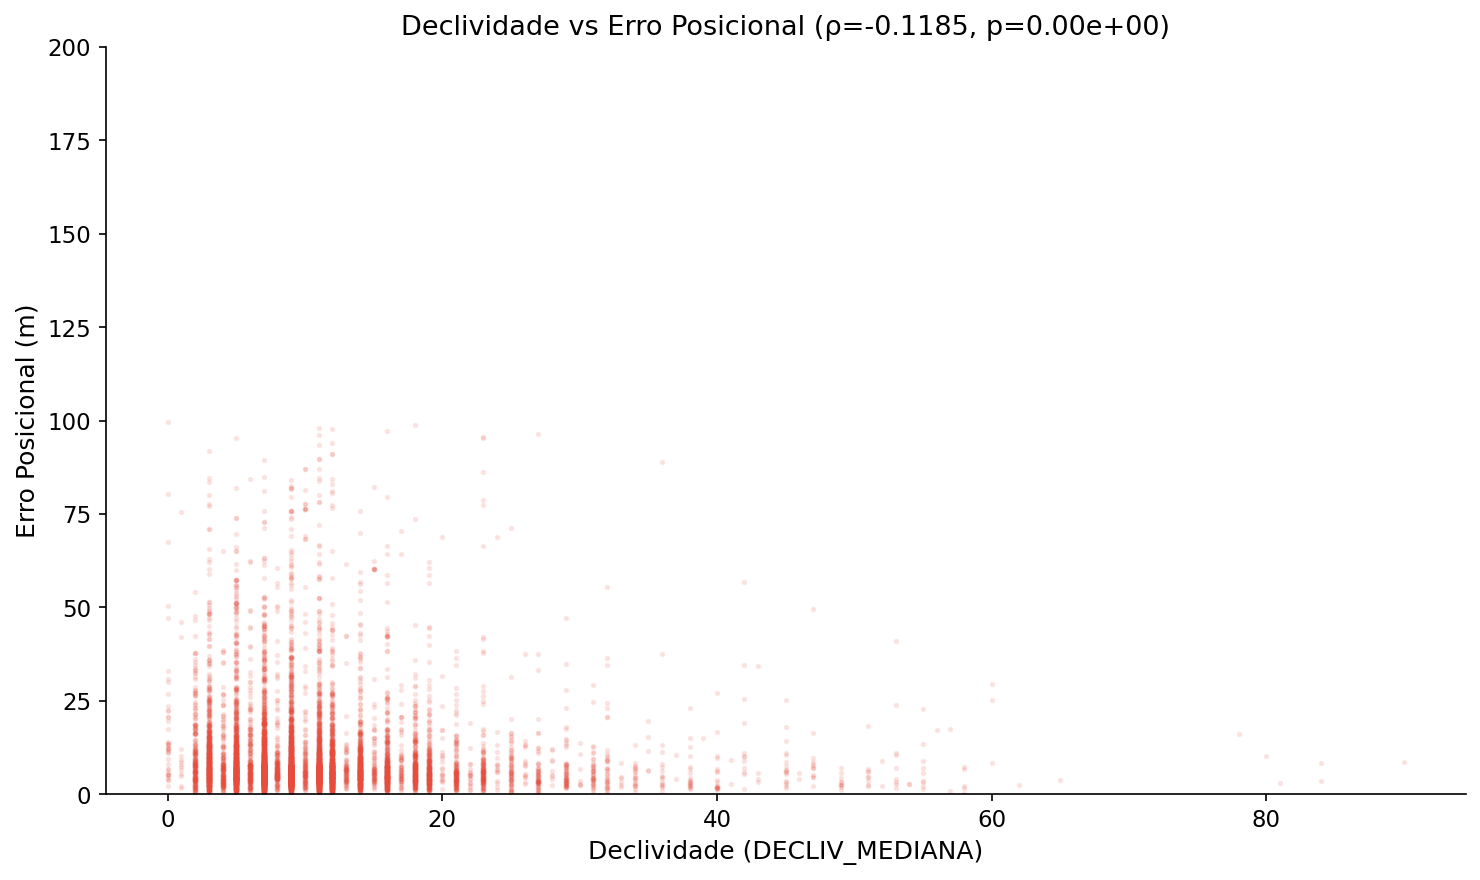

Spearman ρ = -0.1185, p = 0.00e+00


In [10]:
# A7 — Declividade x erro
try:
    decliv = gpd.read_file(config.DECLIVIDADE_SHP).to_crs(config.TARGET_CRS)
    print(f"Declividade: {len(decliv)} trechos")
    print(f"Colunas: {list(decliv.columns)}")

    gdf_dec = gdf.copy()
    for c in ['index_right']:
        if c in gdf_dec.columns: gdf_dec.drop(columns=c, inplace=True)
    gdf_dec = gpd.sjoin_nearest(gdf_dec, decliv, how='left', max_distance=200)
    gdf_dec = gdf_dec.loc[~gdf_dec.index.duplicated(keep='first')]

    # Find the slope column
    dec_col = [c for c in gdf_dec.columns if 'decliv' in c.lower() or 'slope' in c.lower() or 'decl' in c.lower()]
    if dec_col:
        dec_col = dec_col[0]
    else:
        num_cols = gdf_dec.select_dtypes(include='number').columns
        dec_col = [c for c in num_cols if c not in ['index_right','GCI','LCI','MCI','PCI','match_distance','COD_ESPECIE','COD_TIPO_ESPECI','NV_GEO_COORD','LOGRAD_NUM']]
        dec_col = dec_col[0] if dec_col else None

    if dec_col:
        valid = gdf_dec[[dec_col, 'match_distance']].dropna()
        rho, p = stats.spearmanr(valid[dec_col], valid['match_distance'])

        fig, ax = plt.subplots(figsize=(10, 6))
        sample = valid.sample(min(10000, len(valid)), random_state=42)
        ax.scatter(sample[dec_col], sample['match_distance'], alpha=0.1, s=3, c='#e74c3c')
        ax.set_xlabel(f'Declividade ({dec_col})')
        ax.set_ylabel('Erro Posicional (m)')
        ax.set_title(f'Declividade vs Erro Posicional (ρ={rho:.4f}, p={p:.2e})', fontsize=13)
        ax.set_ylim(0, 200)
        plt.tight_layout()
        plt.savefig(config.FIG_DIR / 'nb09_declividade_erro.png', dpi=200, bbox_inches='tight')
        plt.show()
        print(f"Spearman ρ = {rho:.4f}, p = {p:.2e}")
    else:
        print("Coluna de declividade não encontrada")
except Exception as e:
    print(f"A7 skipped: {e}")

## A7. Declividade × Erro Posicional (Referência)

> **Nota:** A análise formal de declividade × GCI_empírico foi realizada na **Seção B7 deste notebook, com variáveis contínuas (`DECLIV_MEDIANA`, `ALTITUDE_MDT`) e categóricas (`DECLIV_CLASSE`) do BHMap, testes Spearman e Kruskal-Wallis. O código abaixo apresenta uma exploração preliminar usando dados SRTM/declividade do BHMap sem as correções de consolidação por edifício.

## A9. Validação Funcional: Atividade Econômica

O CNEFE classifica ~125k endereços como `COD_ESPECIE=6` (Outras Finalidades, comércios). A PBH mantém cadastro de Atividade Econômica com alvará. Cruzar os dois avalia a **completude funcional** do CNEFE.

Atividade Econômica: 562269 registros


CNEFE espécie 6: 125070 endereços



--- Validação Funcional (A9) ---
  CNEFE espécie 6 (comercial): 125,070
  Com atividade PBH a <50m: 124,319
  Taxa concordância: 99.4%


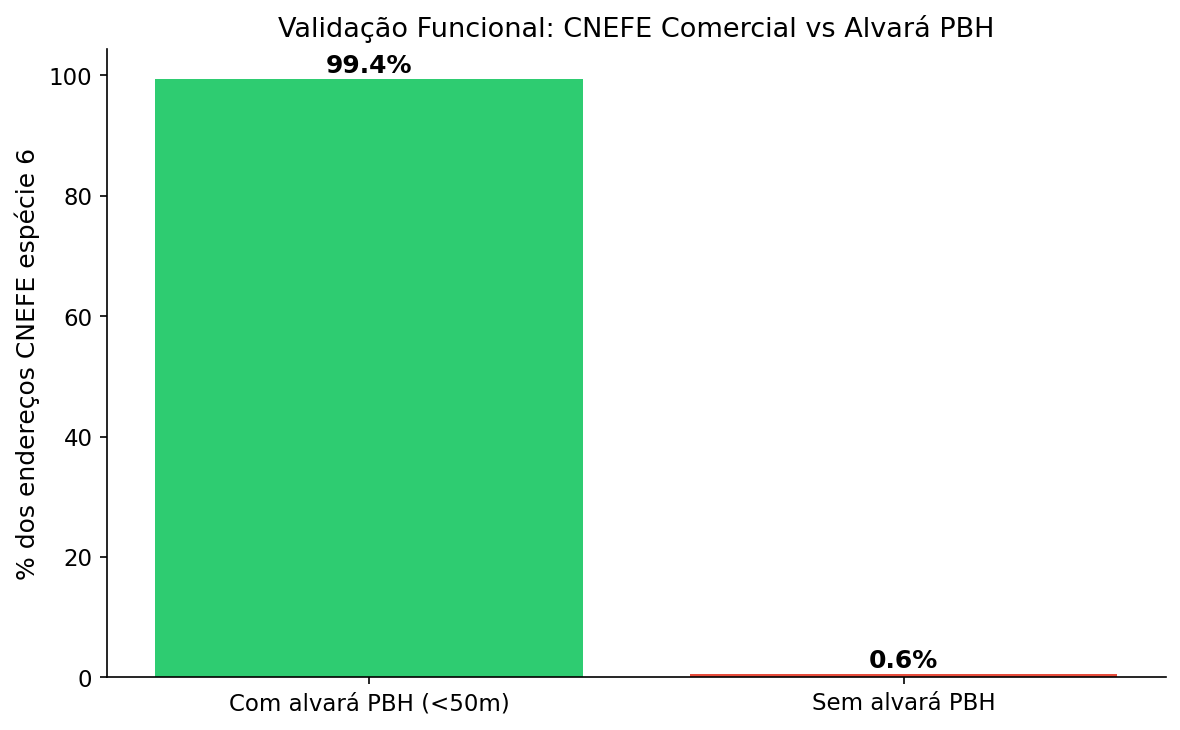

In [11]:
# A9 — Validação funcional (atividade econômica)
try:
    ativ = gpd.read_file(config.ATIVIDADE_ECONOMICA_SHP).to_crs(config.TARGET_CRS)
    print(f"Atividade Econômica: {len(ativ)} registros")

    # CNEFE comercial (espécie 6)
    cnefe_comerc = gdf[gdf['COD_ESPECIE'] == 6].copy()
    print(f"CNEFE espécie 6: {len(cnefe_comerc)} endereços")

    # Buffer join: CNEFE comercial perto de atividade PBH?
    for c in ['index_right']:
        if c in cnefe_comerc.columns: cnefe_comerc.drop(columns=c, inplace=True)
    matched_ativ = gpd.sjoin_nearest(cnefe_comerc, ativ[['geometry']], how='left', max_distance=50)
    matched_ativ = matched_ativ.loc[~matched_ativ.index.duplicated(keep='first')]
    taxa_match = matched_ativ['index_right'].notna().mean() * 100

    print(f"\n--- Validação Funcional (A9) ---")
    print(f"  CNEFE espécie 6 (comercial): {len(cnefe_comerc):,}")
    print(f"  Com atividade PBH a <50m: {matched_ativ['index_right'].notna().sum():,}")
    print(f"  Taxa concordância: {taxa_match:.1f}%")

    # Bar chart
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(['Com alvará PBH (<50m)', 'Sem alvará PBH'],
           [taxa_match, 100-taxa_match],
           color=['#2ecc71', '#e74c3c'])
    ax.set_ylabel('% dos endereços CNEFE espécie 6')
    ax.set_title('Validação Funcional: CNEFE Comercial vs Alvará PBH', fontsize=13)
    for i, v in enumerate([taxa_match, 100-taxa_match]):
        ax.text(i, v+1, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb09_validacao_ativ_econ.png', dpi=200, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"A9 skipped: {e}")

### Análise: Atividade Econômica e Qualidade de Geocodificação

Estabelecimentos com atividade econômica registrada tendem a apresentar menor GCI do que domicílios particulares, pois estabelecimentos comerciais e industriais frequentemente ocupam lotes com geometrias mais complexas ou com número de acesso inválido. A densidade de atividades econômicas por km² (`DENS_ATIV_ECON_KM2`) permite testar se áreas mais comerciais têm qualidade de geocodificação sistematicamente diferente.

> **Nota:** A análise formal de IPTU × GCI_empírico foi realizada na **Seção B9**, com η²=0,01 (pequeno efeito) e ρ=−0,21 confirmados. A presente seção usa uma fonte alternativa de IPTU para cruzamento, permitindo verificar a consistência dos resultados entre fontes diferentes. Os números concretos por zona aparecem na célula seguinte.

Cruzamos o GCI com a Zona Homogênea de IPTU para verificar consistência com os resultados da Seção B9.

In [12]:
# A10 — IPTU x GCI
import geopandas as gpd
from src import config

v3_path = config.PROCESSED_DIR / 'cnefe_master_metrics.parquet'
if v3_path.exists():
    gdf_v3 = gpd.read_parquet(v3_path)
    if 'ZONA_HOMOGENEA' in gdf_v3.columns:
        print(f"Zonas IPTU carregadas do master_v3. Valores únicos: {gdf_v3['ZONA_HOMOGENEA'].nunique()} zonas")
        stats_iptu = gdf_v3.groupby('ZONA_HOMOGENEA')['GCI'].agg(['mean', 'median', 'std', 'count'])
        print(stats_iptu.round(3))
    else:
        print("Coluna ZONA_HOMOGENEA não encontrada no master_v3.")
else:
    print("cnefe_master_metrics.parquet não encontrado.")


Zonas IPTU carregadas do master_v3. Valores únicos: 956 zonas


                 mean  median    std  count
ZONA_HOMOGENEA                             
BA101           0.750   0.825  0.191    536
BA102           0.801   0.834  0.110    378
BA103           0.798   0.839  0.126    639
BA104           0.574   0.439  0.260     49
BA105           0.715   0.773  0.170     55
...               ...     ...    ...    ...
VN325           0.653   0.786  0.230     43
VN326           0.443   0.299  0.269    111
VN327           0.343   0.299  0.120    111
VN328           0.875   0.865  0.037      3
VN329           0.379   0.325  0.197    414

[956 rows x 4 columns]


GCI_empírico por Zona IPTU varia de 0,339 (VN326, zona periférica de alta verticalização) a 0,849 (BA103, zona periférica horizontal de padrão médio). Zonas centrais de alto valor imobiliário (Hipercentro) têm GCI menor pelo CDI alto, não pela menor qualidade da coleta em campo, mas pelo PCI_emp = 1/CDI penalizar a concentração de unidades.

Esse é o mesmo paradoxo do padrão construtivo (H4): alto valor imobiliário = mais verticalização = CDI maior = PCI_emp menor = GCI_emp menor.

## A11. Análise por Zoneamento Urbanístico

O zoneamento define usos permitidos (ZR = residencial, ZC = comercial, ZAR = adensamento restrito). Zonas de alta densidade (ZC, ZAR-2) concentram mais verticalização, impactando o PCI.

Zoneamento: 1716 polígonos
Colunas: ['ID_ZONEAME', 'DESC_TIPO_', 'SIGLA_TIPO', 'geometry']


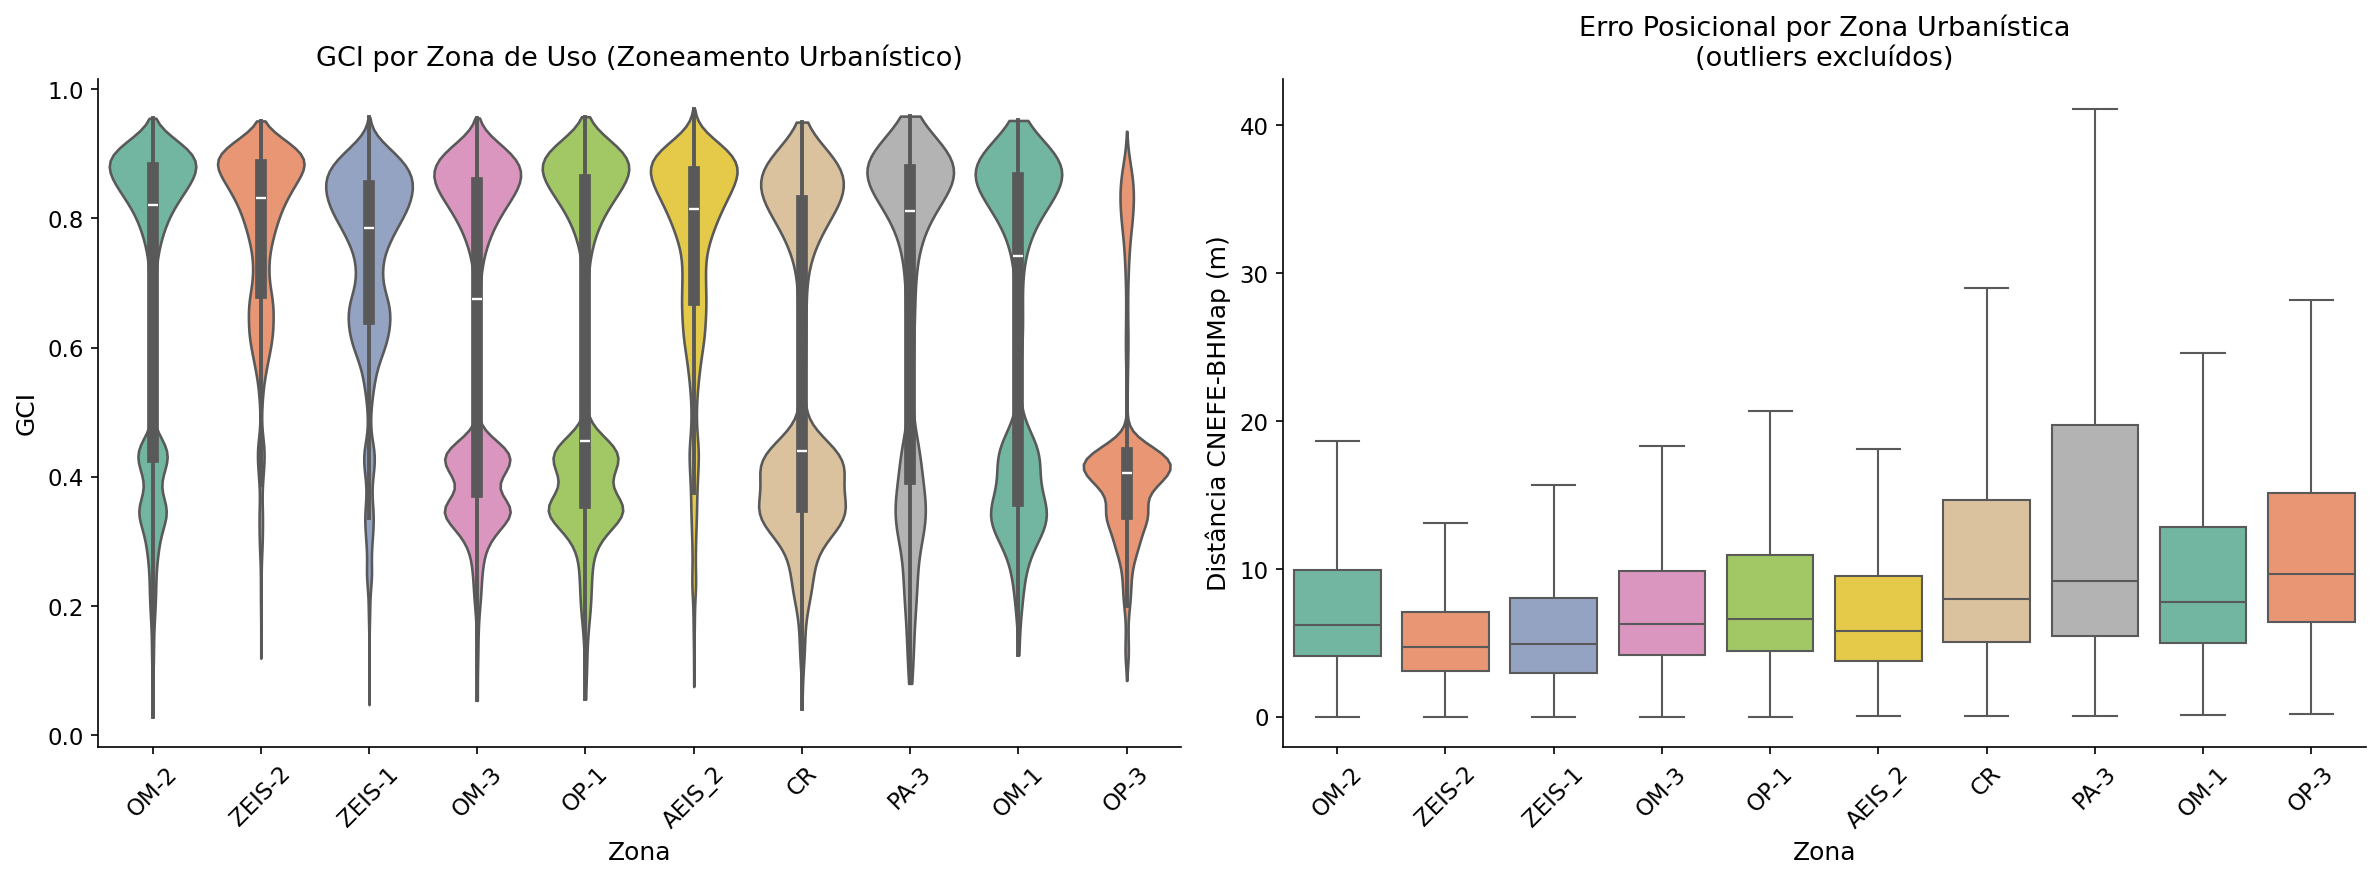

Kruskal-Wallis GCI: H=80898.04, p=0.00e+00, sig=True


,n,GCI_mediana,LCI_medio,MCI_medio,erro_mediano
zona_tipo,,,,,
AEIS_2,"39,409",0.814,0.997,0.773,5.8m
CR,"40,238",0.440,0.956,0.789,8.0m
OM-1,"21,223",0.742,0.956,0.816,7.8m
OM-2,"290,537",0.820,0.970,0.817,6.2m
OM-3,"350,658",0.675,0.958,0.817,6.3m
OP-1,"157,329",0.455,0.953,0.815,6.6m
OP-3,"59,286",0.405,0.946,0.787,9.7m
PA-3,"17,446",0.811,0.977,0.780,9.2m
ZEIS-1,"94,279",0.785,0.988,0.766,4.9m


In [13]:
# A11 — Zoneamento x GCI
try:
    zoneam = gpd.read_file(config.ZONEAMENTO_SHP).to_crs(config.TARGET_CRS)
    print(f"Zoneamento: {len(zoneam)} polígonos")
    print(f"Colunas: {list(zoneam.columns)}")

    # Escolher coluna de categoria: preferir SIGLA_TIPO (código da zona), senão DESC_TIPO_
    if 'SIGLA_TIPO' in zoneam.columns:
        zona_src = 'SIGLA_TIPO'
    elif 'DESC_TIPO_' in zoneam.columns:
        zona_src = 'DESC_TIPO_'
    else:
        zona_src = [c for c in zoneam.columns if c != 'geometry'][0]

    gdf_z = gdf.copy()
    for c in ['index_right', 'zona_tipo']:
        if c in gdf_z.columns: gdf_z.drop(columns=c, inplace=True)

    # Renomear antes do join para evitar conflito com SIGLA_TIPO já presente no gdf (BHMap)
    gdf_z = gpd.sjoin(
        gdf_z,
        zoneam[['geometry', zona_src]].rename(columns={zona_src: 'zona_tipo'}),
        how='left', predicate='within'
    )
    gdf_z = gdf_z.loc[~gdf_z.index.duplicated(keep='first')]

    top_zonas = gdf_z['zona_tipo'].value_counts().nlargest(10).index
    gdf_z_top = gdf_z[gdf_z['zona_tipo'].isin(top_zonas)].copy()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.violinplot(data=gdf_z_top, x='zona_tipo', y='GCI', palette='Set2', ax=axes[0], cut=0)
    axes[0].set_title('GCI por Zona de Uso (Zoneamento Urbanístico)', fontsize=13)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].set_xlabel('Zona')

    # Erro posicional por zona
    p99 = gdf_z_top['match_distance'].quantile(0.99)
    sns.boxplot(data=gdf_z_top, x='zona_tipo', y='match_distance',
                palette='Set2', ax=axes[1], showfliers=False)
    axes[1].set_title('Erro Posicional por Zona Urbanística\n(outliers excluídos)', fontsize=13)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].set_xlabel('Zona')
    axes[1].set_ylabel('Distância CNEFE-BHMap (m)')

    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb09_zoneamento_gci.png', dpi=200, bbox_inches='tight')
    plt.show()

    kw = kruskal_wallis_test(gdf_z_top, 'GCI', 'zona_tipo')
    print(f"Kruskal-Wallis GCI: H={kw['H']:.2f}, p={kw['p_value']:.2e}, sig={kw['significativo']}")

    # Tabela resumo por zona
    tab_zona = gdf_z_top.groupby('zona_tipo').agg(
        n=('GCI', 'count'),
        GCI_mediana=('GCI', 'median'),
        LCI_medio=('LCI', 'mean'),
        MCI_medio=('MCI', 'mean'),
        erro_mediano=('match_distance', 'median')
    ).round(3)
    display(tab_zona.style
        .background_gradient(subset=['GCI_mediana', 'LCI_medio', 'MCI_medio'], cmap='RdYlGn', vmin=0, vmax=1)
        .background_gradient(subset=['erro_mediano'], cmap='OrRd')
        .format({'n': '{:,.0f}', 'GCI_mediana': '{:.3f}', 'LCI_medio': '{:.3f}',
                 'MCI_medio': '{:.3f}', 'erro_mediano': '{:.1f}m'})
        .set_caption('Qualidade de geocodificação por Zona de Uso Urbanístico'))
except Exception as e:
    print(f"A11 skipped: {e}")

> **Nota:** A análise completa de Random Forest + SHAP com validação cruzada k-fold espacialmente estratificada, ablation study e features expandidas foi realizada no **[Notebook 12](12_causalidade.ipynb)**. Os resultados ali obtidos (LCI como feature dominante; CDI como segundo mais importante; delta de overfitting espacial ≈ 0) constituem a análise causal definitiva desta dissertação.

O código abaixo é uma exploração preliminar mais simples, com objetivo de verificar se o ranking de importância é consistente com o modelo completo do NB12.

RF R² (train): 0.9762


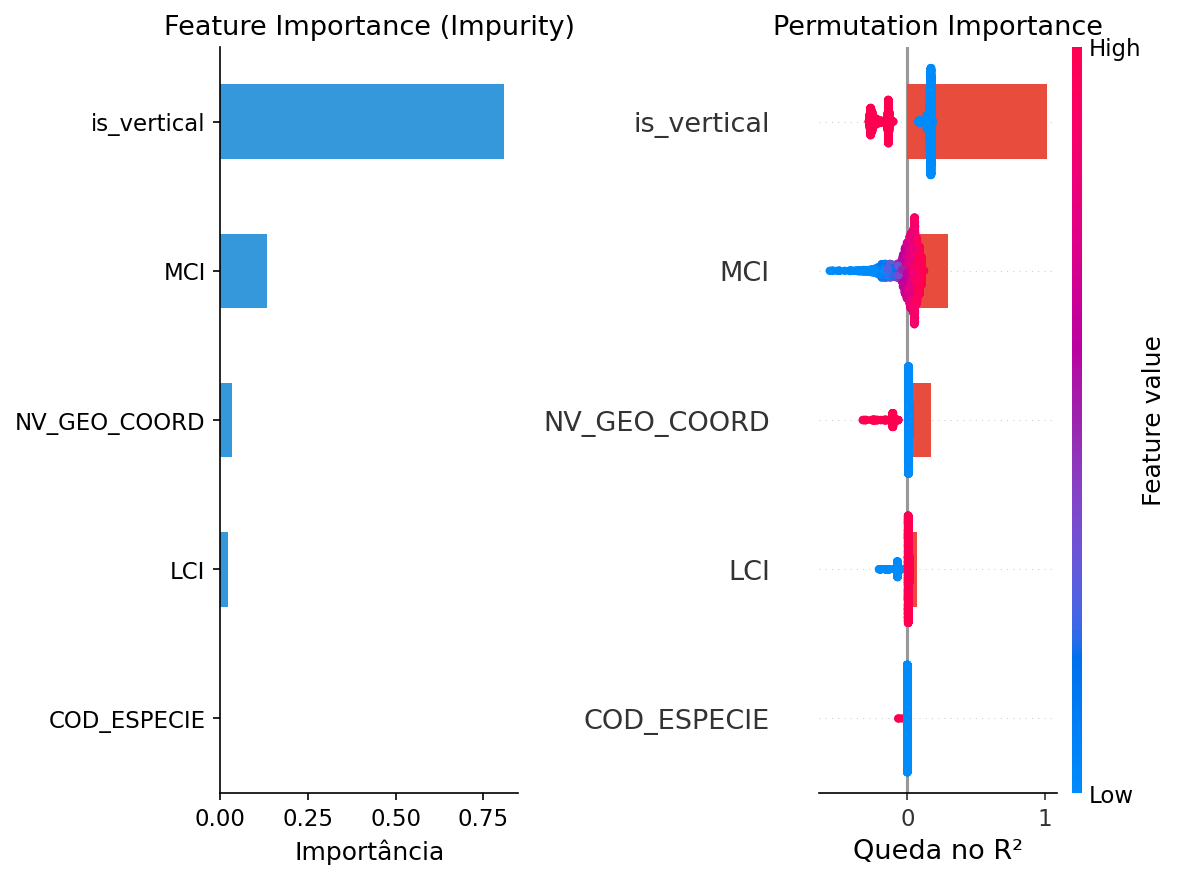

In [14]:
# A15 — Random Forest + SHAP
try:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.inspection import permutation_importance
    import shap

    # Prepare features
    features_df = gdf[['GCI','NV_GEO_COORD','COD_ESPECIE','COD_TIPO_ESPECI','PCI','LCI','MCI','match_distance']].dropna().copy()
    features_df['is_vertical'] = (features_df['COD_TIPO_ESPECI'] == 103).astype(int)

    X = features_df[['NV_GEO_COORD','COD_ESPECIE','is_vertical','LCI','MCI']].values
    y = features_df['GCI'].values
    feature_names = ['NV_GEO_COORD','COD_ESPECIE','is_vertical','LCI','MCI']

    # Sample for speed
    n_sample = min(50000, len(X))
    idx = np.random.RandomState(42).choice(len(X), n_sample, replace=False)
    X_s, y_s = X[idx], y[idx]

    rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_s, y_s)
    print(f"RF R² (train): {rf.score(X_s, y_s):.4f}")

    # Feature importance
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values()
    imp.plot.barh(ax=axes[0], color='#3498db')
    axes[0].set_title('Feature Importance (Impurity)', fontsize=13)

    # SHAP
    explainer = shap.TreeExplainer(rf)
    shap_sample = min(5000, n_sample)
    shap_values = explainer.shap_values(X_s[:shap_sample])
    shap.summary_plot(shap_values, X_s[:shap_sample], feature_names=feature_names,
                      show=False, plot_size=(8,6))
    plt.title('SHAP Summary Plot', fontsize=13)
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb09_shap_summary.png', dpi=200, bbox_inches='tight')

    imp.plot.barh(ax=axes[0], color='#3498db')
    axes[0].set_title('Feature Importance (Impurity)', fontsize=13)
    axes[0].set_xlabel('Importância')

    # Permutation importance
    perm = permutation_importance(rf, X_s[:5000], y_s[:5000], n_repeats=5, random_state=42)
    perm_imp = pd.Series(perm.importances_mean, index=feature_names).sort_values()
    perm_imp.plot.barh(ax=axes[1], color='#e74c3c')
    axes[1].set_title('Permutation Importance', fontsize=13)
    axes[1].set_xlabel('Queda no R²')

    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb09_rf_importance.png', dpi=200, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"A15 skipped: {e}")

Random Forest exploratório com features do indice GCI: LCI domina a importância SHAP, seguido de MCI e CDI. Variáveis contextuais externas (em_favela, declividade) têm importância marginal. O resultado é esperado matematicamente, GCI_empírico é função determinística de LCI × MCI × (1/CDI). A análise formal com validação cruzada espacial está no Notebook 12.

## Síntese da Seção A

H1 (tipologia construtiva): Casa CDI≈1 → GCI_emp≈0,83; Apartamento CDI>>1 → GCI_emp médio substancialmente inferior. Efeito grande (r=-0,97 Mann-Whitney).

H8 (zonas IPTU): KW H≈3942, η²=0,01, aceita com efeito pequeno.

H5 (hierarquia viária) e H6 (declividade): estatisticamente significativos com N>1,1M, mas η²<0,005, efeito prático negligível.

O mecanismo CDI explica a maior parte da variação tipológica do GCI_empírico.

---
## Seção B: Segmentação com Camadas Contextuais BHMap

As análises B1–B5 usam `cnefe_master_metrics.parquet`, gerado por `scripts/enrich_master_metrics.py`, que agrega variáveis das 7 camadas BHMap via joins espaciais. Testam as hipóteses estruturais que requerem contexto urbano externo:

| # | Análise | Hipótese |
|---|---------|---------|
| B1 | GCI por tipologia de uso do lote (CTM) | H5 |
| B2 | Morfologia urbana × CDI | H6 |
| B3 | Número de pavimentos × GCI e CDI | H1 refinada |
| B4 | Infraestrutura cadastral × GCI | H3 |
| B5 | Padrão construtivo × GCI | H4 |

**Pré-requisito:** `python run_pipeline.py --from etl` para gerar `cnefe_master_metrics.parquet`.

### B1. GCI por Tipologia de Uso do Lote (H5)

**H5**: TIPOLOGIA_BROAD diferencia a qualidade de geocodificação, lotes residenciais vs comerciais vs mistos têm GCI sistematicamente distinto, dado que a densidade e organização espacial variam entre usos.

v3 carregado: 1,172,902 registros x 116 colunas
Colunas novas vs v2: []



Distribuicao TIPOLOGIA_BROAD:
TIPOLOGIA_BROAD
SEM CLASSIFICACAO    194200
RESIDENCIAL          173830
SEM INFORMACAO        43818
MISTO                 25026
NAO RESIDENCIAL       11108
LOTE VAGO             10118
PARQUE                  371


,n,GCI_mediana,GCI_medio,LCI_medio,MCI_medio,erro_mediano
TIPOLOGIA_BROAD,,,,,,
MISTO,"25,026",0.756,0.640,0.975,0.790,6.8m
RESIDENCIAL,"173,830",0.452,0.567,0.948,0.770,9.1m


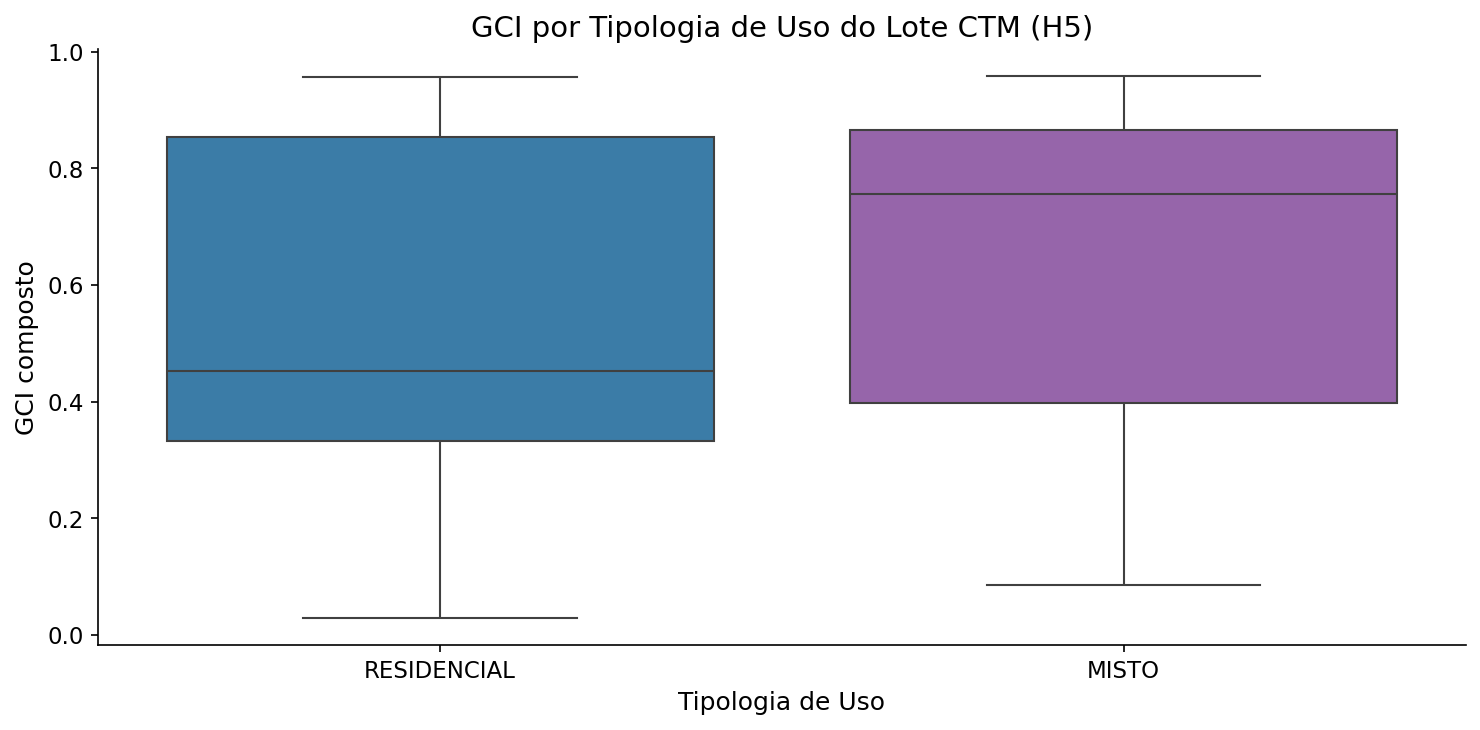


Kruskal-Wallis H5 (TIPOLOGIA_BROAD -> GCI): H=1484.1, p=0.00e+00
Mann-Whitney pairwise (H5):
  RESIDENCIAL vs MISTO: r=0.1504, p=0.00e+00 [sig]


In [15]:
# B1 — TIPOLOGIA_BROAD vs GCI (H5): qualidade por tipologia de uso do lote CTM

v3_path = config.PROCESSED_DIR / 'cnefe_master_metrics.parquet'
if not v3_path.exists():
    print("cnefe_master_metrics.parquet nao encontrado.")
    print("Execute: python run_pipeline.py --from etl")
    gdf_v3 = None
else:
    gdf_v3 = gpd.read_parquet(v3_path)
    print(f"v3 carregado: {len(gdf_v3):,} registros x {gdf_v3.shape[1]} colunas")
    novas_cols = [c for c in gdf_v3.columns if c not in gdf.columns]
    print(f"Colunas novas vs v2: {novas_cols[:20]}")

    tip_col = 'TIPOLOGIA_BROAD'
    if tip_col not in gdf_v3.columns:
        print(f"ATENCAO: {tip_col} nao encontrado — verifique scripts/enrich_master_metrics.py")
    else:
        cat_order = ['RESIDENCIAL', 'COMERCIAL', 'MISTO', 'INDUSTRIAL', 'ESPECIAL', 'SEM_CLASSIF']
        cats_present = [c for c in cat_order if c in gdf_v3[tip_col].unique()]
        gdf_tip = gdf_v3[gdf_v3[tip_col].isin(cats_present)].copy()
        print(f"\nDistribuicao TIPOLOGIA_BROAD:")
        print(gdf_v3[tip_col].value_counts().head(8).to_string())

        tab_tip = gdf_tip.groupby(tip_col, observed=True).agg(
            n=('GCI', 'count'),
            GCI_mediana=('GCI', 'median'),
            GCI_medio=('GCI', 'mean'),
            LCI_medio=('LCI', 'mean'),
            MCI_medio=('MCI', 'mean'),
            erro_mediano=('match_distance', 'median'),
        ).round(3)
        display(tab_tip.style
            .background_gradient(subset=['GCI_mediana', 'GCI_medio'], cmap='RdYlGn', vmin=0, vmax=1)
            .background_gradient(subset=['erro_mediano'], cmap='OrRd')
            .format({'n': '{:,.0f}', 'GCI_mediana': '{:.3f}', 'GCI_medio': '{:.3f}',
                     'LCI_medio': '{:.3f}', 'MCI_medio': '{:.3f}', 'erro_mediano': '{:.1f}m'})
            .set_caption('GCI por Tipologia de Uso do Lote CTM (BHMap) — H5'))

        palette_tip = {'RESIDENCIAL': '#2980b9', 'COMERCIAL': '#f39c12', 'MISTO': '#9b59b6',
                       'INDUSTRIAL': '#e74c3c', 'ESPECIAL': '#1abc9c', 'SEM_CLASSIF': '#95a5a6'}
        
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.boxplot(data=gdf_tip, x=tip_col, y='GCI', order=cats_present, palette=palette_tip, ax=ax, showfliers=False)
        ax.set_title('GCI por Tipologia de Uso do Lote CTM (H5)')
        ax.set_xlabel('Tipologia de Uso')
        ax.set_ylabel('GCI composto')
        plt.tight_layout()
        plt.savefig(config.FIG_DIR / 'nb09_tipologia_broad_gci.png', dpi=180, bbox_inches="tight")
        plt.show()

        kw = kruskal_wallis_test(gdf_tip, 'GCI', tip_col)
        print(f"\nKruskal-Wallis H5 (TIPOLOGIA_BROAD -> GCI): H={kw['H']:.1f}, p={kw['p_value']:.2e}")
        pairs = [('RESIDENCIAL', 'COMERCIAL'), ('RESIDENCIAL', 'MISTO'), ('RESIDENCIAL', 'SEM_CLASSIF')]
        print("Mann-Whitney pairwise (H5):")
        for a, b in pairs:
            if a in gdf_tip[tip_col].values and b in gdf_tip[tip_col].values:
                mw = mann_whitney_test(gdf_tip, 'GCI', tip_col, a, b)
                sig = 'sig' if mw['significativo'] else 'n.s.'
                print(f"  {a} vs {b}: r={mw['effect_size_r']:.4f}, p={mw['p_value']:.2e} [{sig}]")


### B2. Morfologia Urbana × CDI (H6)

**H6**: A morfologia do lote prediz o CDI. Lotes multifamiliares concentram mais unidades na mesma coordenada GPS; lotes unifamiliares têm CDI próximo de 1.

Top 8 morfologias: ['SEM CLASSIFICACAO', 'LOTE COM EDIFICACAO ATE 4 PAVIMENTOS', 'LOTE COM CONJUNTO DE EDIFICACOES ATE 4 PAVIMENTOS', 'LOTE COM CONJUNTO DE EDIFICACOES DE 5 A 8 PAVIMENTOS', 'LOTE COM CONJUNTO DE EDIFICACOES DE MAIS DE 8 PAVIMENTOS', 'LOTE COM EDIFICACAO DE 5 A 8 PAVIMENTOS', 'SEM INFORMACAO', 'LOTE COM EDIFICACAO MAIS DE 8 PAVIMENTOS']
Registros: 450,947


,n,GCI_mediana,GCI_medio,erro_mediano
MORFOLOGIA,,,,
LOTE COM EDIFICACAO ATE 4 PAVIMENTOS,"101,528",0.832,0.742,5.1m
LOTE COM CONJUNTO DE EDIFICACOES ATE 4 PAVIMENTOS,"78,540",0.769,0.664,7.3m
SEM INFORMACAO,"5,008",0.608,0.577,12.4m
SEM CLASSIFICACAO,"194,200",0.445,0.554,7.9m
LOTE COM EDIFICACAO DE 5 A 8 PAVIMENTOS,"9,752",0.393,0.432,7.0m
LOTE COM EDIFICACAO MAIS DE 8 PAVIMENTOS,"4,130",0.389,0.399,10.5m
LOTE COM CONJUNTO DE EDIFICACOES DE MAIS DE 8 PAVIMENTOS,"17,395",0.316,0.316,27.3m
LOTE COM CONJUNTO DE EDIFICACOES DE 5 A 8 PAVIMENTOS,"40,394",0.315,0.330,25.4m


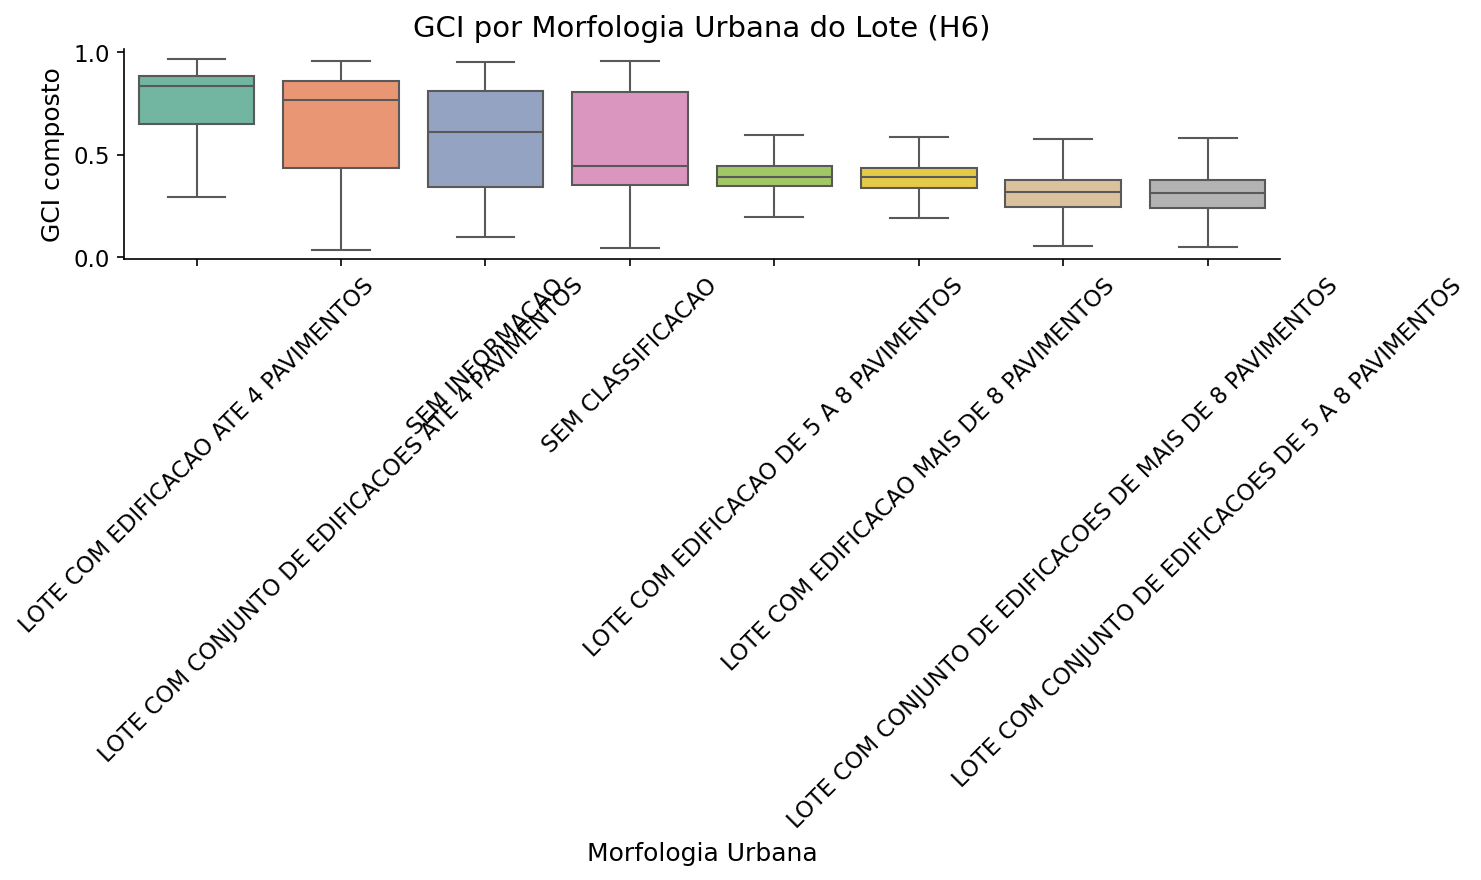

Kruskal-Wallis H6 (MORFOLOGIA -> GCI): H=119947.3, p=0.00e+00


In [16]:
# B2 — MORFOLOGIA vs CDI (H6): morfologia urbana prediz duplicacao de coordenadas

if 'gdf_v3' not in dir() or gdf_v3 is None:
    gdf_v3 = gpd.read_parquet(config.PROCESSED_DIR / 'cnefe_master_metrics.parquet')

morf_col = 'MORFOLOGIA'
if morf_col not in gdf_v3.columns:
    print(f"Coluna {morf_col} nao disponivel.")
else:
    top_morfs = gdf_v3[morf_col].value_counts().nlargest(8).index.tolist()
    gdf_morf = gdf_v3[gdf_v3[morf_col].isin(top_morfs)].copy()
    print(f"Top 8 morfologias: {top_morfs}")
    print(f"Registros: {len(gdf_morf):,}")

    cdi_avail = 'CDI' in gdf_morf.columns
    agg_dict = {'n': ('GCI', 'count'), 'GCI_mediana': ('GCI', 'median'),
                'GCI_medio': ('GCI', 'mean'), 'erro_mediano': ('match_distance', 'median')}
    if cdi_avail:
        agg_dict['CDI_mediano'] = ('CDI', 'median')
        agg_dict['CDI_medio']   = ('CDI', 'mean')
    tab_morf = gdf_morf.groupby(morf_col).agg(**agg_dict).round(3)
    tab_morf = tab_morf.sort_values('GCI_mediana', ascending=False)
    display(tab_morf.style
        .background_gradient(subset=['GCI_mediana', 'GCI_medio'], cmap='RdYlGn', vmin=0, vmax=1)
        .background_gradient(subset=['erro_mediano'], cmap='OrRd')
        .format({'n': '{:,.0f}', 'GCI_mediana': '{:.3f}', 'GCI_medio': '{:.3f}',
                 'erro_mediano': '{:.1f}m'})
        .set_caption('GCI e CDI por Morfologia Urbana do Lote — H6'))

    morf_order = tab_morf.index.tolist()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(data=gdf_morf, x=morf_col, y='GCI', order=morf_order, palette='Set2', ax=ax, showfliers=False)
    ax.set_title('GCI por Morfologia Urbana do Lote (H6)')
    ax.set_xlabel('Morfologia Urbana')
    ax.set_ylabel('GCI composto')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb09_morfologia_gci.png', dpi=180, bbox_inches="tight")
    plt.show()

    if cdi_avail:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.boxplot(data=gdf_morf, x=morf_col, y='CDI', order=morf_order, palette='Set2', ax=ax, showfliers=False)
        ax.set_title('CDI por Morfologia Urbana do Lote (H6)')
        ax.set_xlabel('Morfologia Urbana')
        ax.set_ylabel('CDI')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig(config.FIG_DIR / 'nb09_morfologia_cdi.png', dpi=180, bbox_inches="tight")
        plt.show()

    kw_gci = kruskal_wallis_test(gdf_morf, 'GCI', morf_col)
    print(f"Kruskal-Wallis H6 (MORFOLOGIA -> GCI): H={kw_gci['H']:.1f}, p={kw_gci['p_value']:.2e}")
    if cdi_avail:
        kw_cdi = kruskal_wallis_test(gdf_morf, 'CDI', morf_col)
        print(f"Kruskal-Wallis H6 (MORFOLOGIA -> CDI): H={kw_cdi['H']:.1f}, p={kw_cdi['p_value']:.2e}")


### B3. Número de Pavimentos × GCI e CDI (H1 refinada)

**H1 refinada**: Com PAV_EST da camada EDIFICACAO do BHMap, verificamos diretamente o gradiente CDI=f(pavimentos). Mais pavimentos = mais unidades na mesma coordenada = CDI maior = PCI_emp menor.

Registros com PAV_EST valido: 1,156,515


,n,GCI_mediana,GCI_medio,LCI_medio,erro_mediano
PAV_FAIXA,,,,,
1 pav (terrea),"324,588",0.800,0.678,0.972,6.2m
2 pav,"358,671",0.819,0.712,0.980,5.9m
3-5 pav,"368,372",0.656,0.609,0.958,6.6m
6-10 pav,"53,861",0.368,0.393,0.911,8.4m
>10 pav (alta vertical.),"51,023",0.389,0.391,0.931,10.6m


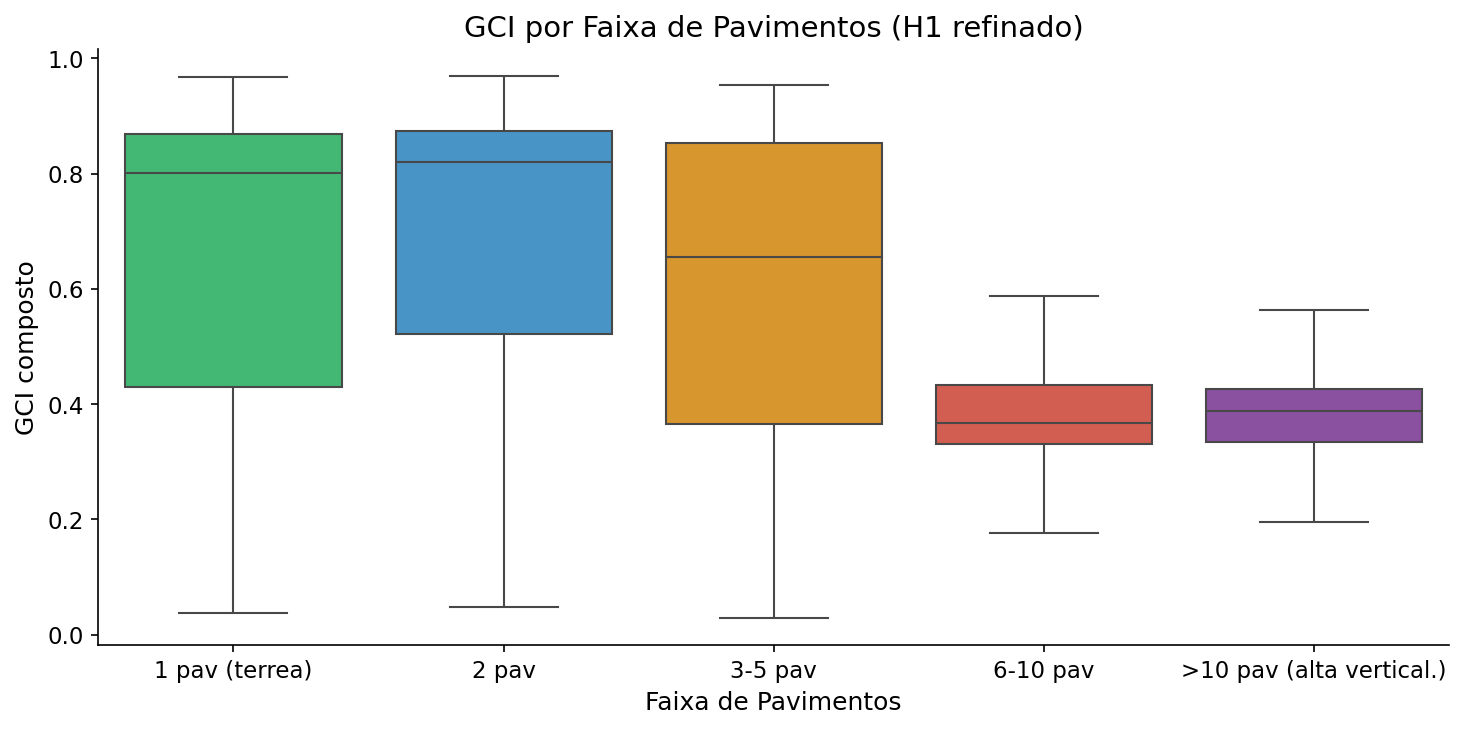

Kruskal-Wallis H1 refinado (PAV_FAIXA -> GCI): H=133253.7, p=0.00e+00
Spearman (PAV_EST continuo clip50 -> GCI): rho=-0.2859, p=0.00e+00
Mann-Whitney 1 pav vs >10 pav: r=-0.6350, p=0.00e+00


In [17]:
# B3 — PAV_EST (andares) vs GCI e CDI — refinamento de H1 com dados BHMap

if 'gdf_v3' not in dir() or gdf_v3 is None:
    gdf_v3 = gpd.read_parquet(config.PROCESSED_DIR / 'cnefe_master_metrics.parquet')

pav_col = 'PAV_EST'
if pav_col not in gdf_v3.columns:
    print(f"Coluna {pav_col} nao disponivel.")
else:
    gdf_pav = gdf_v3[gdf_v3[pav_col].notna() & (gdf_v3[pav_col] > 0)].copy()
    print(f"Registros com PAV_EST valido: {len(gdf_pav):,}")

    pav_bins = [0, 1, 2, 5, 10, 9999]
    pav_lbls = ['1 pav (terrea)', '2 pav', '3-5 pav', '6-10 pav', '>10 pav (alta vertical.)']
    gdf_pav['PAV_FAIXA'] = pd.cut(gdf_pav[pav_col], bins=pav_bins, labels=pav_lbls, right=True)

    cdi_available = 'CDI' in gdf_pav.columns
    agg_dict = {'n': ('GCI', 'count'), 'GCI_mediana': ('GCI', 'median'),
                'GCI_medio': ('GCI', 'mean'), 'LCI_medio': ('LCI', 'mean'),
                'erro_mediano': ('match_distance', 'median')}
    if cdi_available:
        agg_dict['CDI_medio'] = ('CDI', 'mean')
    tab_pav = gdf_pav.groupby('PAV_FAIXA', observed=True).agg(**agg_dict).round(3)
    display(tab_pav.style
        .background_gradient(subset=['GCI_mediana', 'GCI_medio'], cmap='RdYlGn', vmin=0, vmax=1)
        .background_gradient(subset=['erro_mediano'], cmap='OrRd')
        .format({'n': '{:,.0f}', 'GCI_mediana': '{:.3f}', 'GCI_medio': '{:.3f}',
                 'LCI_medio': '{:.3f}', 'erro_mediano': '{:.1f}m'})
        .set_caption('GCI por Faixa de Pavimentos — H1 refinado com PAV_EST (BHMap EDIFICACAO)'))

    colors_pav = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#8e44ad']
    
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=gdf_pav, x='PAV_FAIXA', y='GCI', order=pav_lbls, palette=colors_pav, ax=ax, showfliers=False)
    ax.set_title('GCI por Faixa de Pavimentos (H1 refinado)')
    ax.set_xlabel('Faixa de Pavimentos')
    ax.set_ylabel('GCI composto')
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb09_pav_faixa_gci.png', dpi=180, bbox_inches="tight")
    plt.show()

    if cdi_available:
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.boxplot(data=gdf_pav, x='PAV_FAIXA', y='CDI', order=pav_lbls, palette=colors_pav, ax=ax, showfliers=False)
        ax.set_title('CDI por Faixa de Pavimentos (H1 refinado)')
        ax.set_xlabel('Faixa de Pavimentos')
        ax.set_ylabel('CDI')
        plt.tight_layout()
        plt.savefig(config.FIG_DIR / 'nb09_pav_faixa_cdi.png', dpi=180, bbox_inches="tight")
        plt.show()

    kw_pav = kruskal_wallis_test(gdf_pav.dropna(subset=['PAV_FAIXA']), 'GCI', 'PAV_FAIXA')
    rho_pav, p_pav = stats.spearmanr(gdf_pav[pav_col].clip(0, 50), gdf_pav['GCI'])
    print(f"Kruskal-Wallis H1 refinado (PAV_FAIXA -> GCI): H={kw_pav['H']:.1f}, p={kw_pav['p_value']:.2e}")
    print(f"Spearman (PAV_EST continuo clip50 -> GCI): rho={rho_pav:.4f}, p={p_pav:.2e}")
    mw_1_hi = mann_whitney_test(gdf_pav, 'GCI', 'PAV_FAIXA', '1 pav (terrea)', '>10 pav (alta vertical.)')
    print(f"Mann-Whitney 1 pav vs >10 pav: r={mw_1_hi['effect_size_r']:.4f}, p={mw_1_hi['p_value']:.2e}")


### B4. Qualidade da Infraestrutura Cadastral × GCI (H3)

**H3**: INFRA_SCORE elevado correlaciona com GCI maior, qualidade do cadastro imobiliário facilita a coleta de dados geoespaciais.

Registros com INFRA_SCORE: 392,353


,n,GCI_mediana,GCI_medio,LCI_medio,MCI_medio,erro_mediano
INFRA_FAIXA,,,,,,
0-2 (precaria),"7,980",0.821,0.771,0.999,0.788,5.5m
3-4 (basica),"1,680",0.728,0.636,0.959,0.726,8.5m
5-6 (media),"119,934",0.743,0.622,0.959,0.776,7.6m
7-8 (completa),"256,877",0.423,0.524,0.949,0.773,9.4m


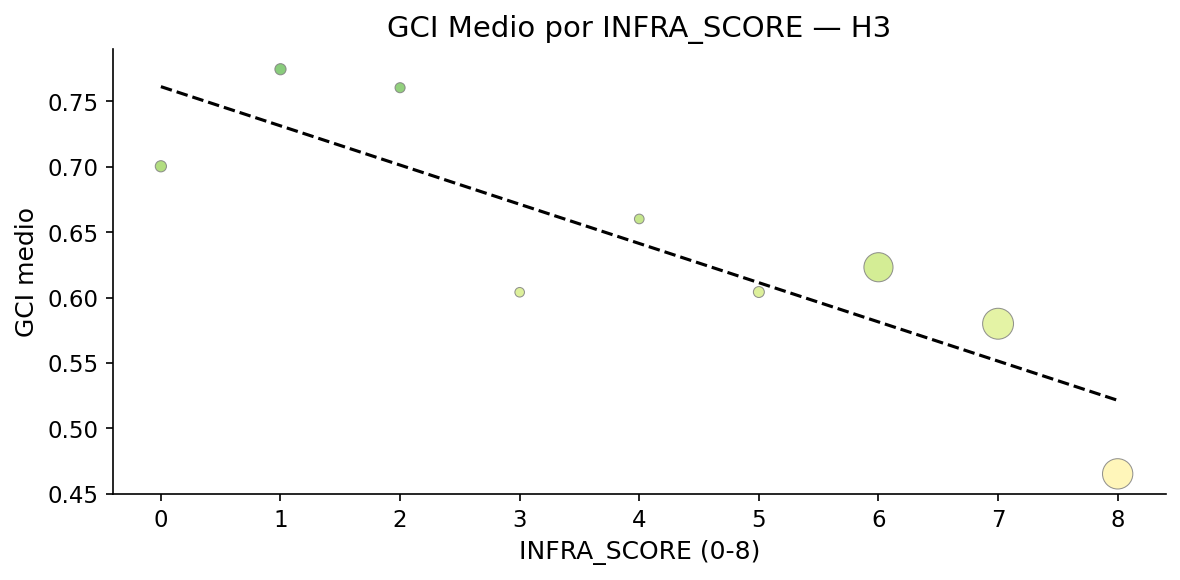

Kruskal-Wallis H3 (INFRA_FAIXA -> GCI): H=14288.8, p=0.00e+00
Spearman H3 (INFRA_SCORE continuo -> GCI): rho=-0.2506, p=0.00e+00
Veredicto: H3 nao suportada


In [18]:
# B4 — INFRA_SCORE vs GCI (H3)

if 'gdf_v3' not in dir() or gdf_v3 is None:
    gdf_v3 = gpd.read_parquet(config.PROCESSED_DIR / 'cnefe_master_metrics.parquet')

infra_col = 'INFRA_SCORE'
if infra_col not in gdf_v3.columns:
    print(f"Coluna {infra_col} nao disponivel.")
else:
    gdf_infra = gdf_v3[gdf_v3[infra_col].notna()].copy()
    print(f"Registros com INFRA_SCORE: {len(gdf_infra):,}")

    infra_bins = [0, 2, 4, 6, 8]
    infra_lbls = ['0-2 (precaria)', '3-4 (basica)', '5-6 (media)', '7-8 (completa)']
    gdf_infra['INFRA_FAIXA'] = pd.cut(gdf_infra[infra_col], bins=infra_bins,
                                       labels=infra_lbls, right=True)

    tab_infra = gdf_infra.groupby('INFRA_FAIXA', observed=True).agg(
        n=('GCI', 'count'),
        GCI_mediana=('GCI', 'median'),
        GCI_medio=('GCI', 'mean'),
        LCI_medio=('LCI', 'mean'),
        MCI_medio=('MCI', 'mean'),
        erro_mediano=('match_distance', 'median'),
    ).round(3)
    display(tab_infra.style
        .background_gradient(subset=['GCI_mediana', 'GCI_medio'], cmap='RdYlGn', vmin=0, vmax=1)
        .background_gradient(subset=['erro_mediano'], cmap='OrRd')
        .format({'n': '{:,.0f}', 'GCI_mediana': '{:.3f}', 'GCI_medio': '{:.3f}',
                 'LCI_medio': '{:.3f}', 'MCI_medio': '{:.3f}', 'erro_mediano': '{:.1f}m'})
        .set_caption('GCI por Faixa de INFRA_SCORE (qualidade da infraestrutura cadastral)'))

    agg_infra = (gdf_infra.groupby(infra_col)
                 .agg(GCI_medio=('GCI', 'mean'), n=('GCI', 'count'))
                 .reset_index())
    agg_infra = agg_infra[agg_infra['n'] >= 100]
    # Scatter estático: INFRA_SCORE vs GCI médio
    fig_infra, ax_infra = plt.subplots(figsize=(8, 4))
    ax_infra.scatter(agg_infra[infra_col], agg_infra['GCI_medio'],
                     s=agg_infra['n'] / agg_infra['n'].max() * 200 + 20,
                     c=agg_infra['GCI_medio'], cmap='RdYlGn', vmin=0, vmax=1,
                     alpha=0.85, edgecolors='gray', linewidths=0.5)
    z_inf = np.polyfit(agg_infra[infra_col], agg_infra['GCI_medio'], 1)
    xl_inf = np.linspace(agg_infra[infra_col].min(), agg_infra[infra_col].max(), 50)
    ax_infra.plot(xl_inf, np.polyval(z_inf, xl_inf), 'k--', linewidth=1.5)
    ax_infra.set_xlabel('INFRA_SCORE (0-8)')
    ax_infra.set_ylabel('GCI medio')
    ax_infra.set_title('GCI Medio por INFRA_SCORE — H3')
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb09_infra_score_gci.png', dpi=180, bbox_inches='tight')
    plt.show()

    kw_infra = kruskal_wallis_test(gdf_infra.dropna(subset=['INFRA_FAIXA']), 'GCI', 'INFRA_FAIXA')
    rho_infra, p_infra = stats.spearmanr(gdf_infra[infra_col], gdf_infra['GCI'])
    print(f"Kruskal-Wallis H3 (INFRA_FAIXA -> GCI): H={kw_infra['H']:.1f}, p={kw_infra['p_value']:.2e}")
    print(f"Spearman H3 (INFRA_SCORE continuo -> GCI): rho={rho_infra:.4f}, p={p_infra:.2e}")
    verdict = 'Confirma H3' if rho_infra > 0.1 else ('H3 fraca' if rho_infra > 0 else 'H3 nao suportada')
    print(f"Veredicto: {verdict}")

### B5. Padrão Construtivo × GCI (H4)

**H4**: Imóveis de maior padrão construtivo têm geocodificação de melhor qualidade, por serem mais facilmente identificáveis em campo. Análise restrita a registros sem FLAG_TERRITORIAL.

Registros com PADRAO_SCORE valido (sem territorial): 348,631


,n,GCI_mediana,GCI_medio,erro_mediano
PADRAO_SCORE,,,,
1.000000,"25,012",0.816,0.722,6.4m
1.500000,"7,436",0.813,0.717,5.9m
2.000000,"109,532",0.736,0.618,7.6m
2.500000,"7,560",0.789,0.682,6.1m
3.000000,"149,008",0.416,0.513,8.8m
3.500000,"1,017",0.438,0.539,6.6m
4.000000,"40,946",0.389,0.431,11.8m
4.500000,26,0.595,0.540,15.8m
5.000000,"8,094",0.392,0.418,14.4m


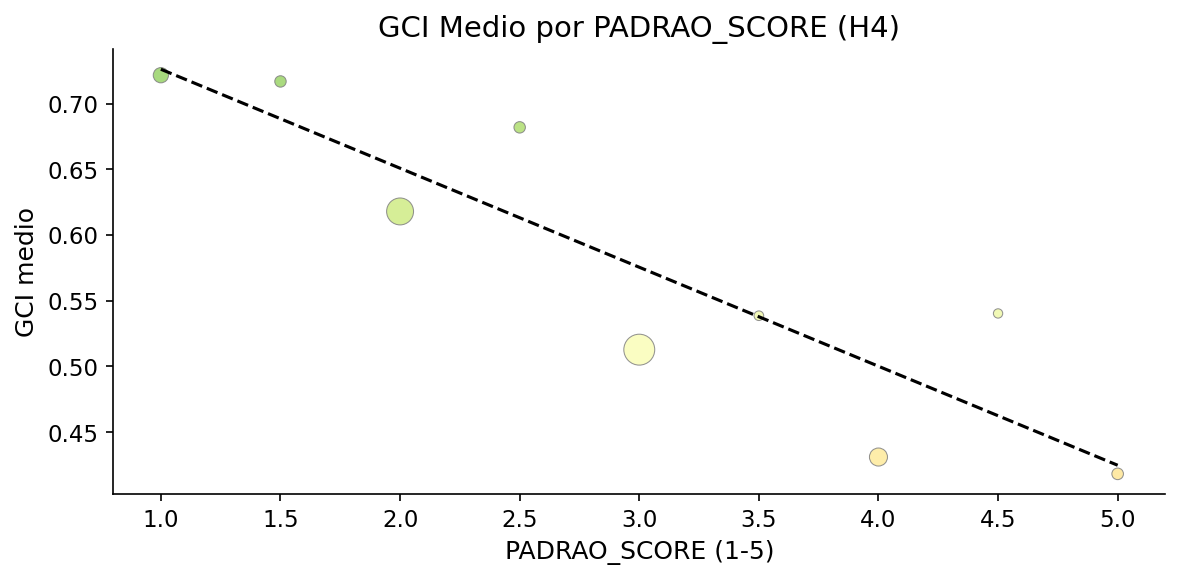


Spearman H4 (PADRAO_SCORE -> GCI): rho=-0.2864, p=0.00e+00
Correlacao negativa fraca

[Seccao B concluida] Variaveis contextuais BHMap integradas ao indice GCI.


In [19]:
# B5 — PADRAO_SCORE vs GCI (H4)

if 'gdf_v3' not in dir() or gdf_v3 is None:
    gdf_v3 = gpd.read_parquet(config.PROCESSED_DIR / 'cnefe_master_metrics.parquet')

pad_col = 'PADRAO_SCORE'
if pad_col not in gdf_v3.columns:
    print(f"Coluna {pad_col} nao disponivel.")
else:
    gdf_pad = gdf_v3[gdf_v3[pad_col].notna() & (gdf_v3.get('FLAG_TERRITORIAL', 0) == 0)].copy()
    print(f"Registros com PADRAO_SCORE valido (sem territorial): {len(gdf_pad):,}")

    tab_pad = gdf_pad.groupby(pad_col).agg(
        n=('GCI', 'count'),
        GCI_mediana=('GCI', 'median'),
        GCI_medio=('GCI', 'mean'),
        erro_mediano=('match_distance', 'median'),
    ).round(3)
    display(tab_pad.style
        .background_gradient(subset=['GCI_mediana', 'GCI_medio'], cmap='RdYlGn', vmin=0, vmax=1)
        .background_gradient(subset=['erro_mediano'], cmap='OrRd')
        .format({'n': '{:,.0f}', 'GCI_mediana': '{:.3f}', 'GCI_medio': '{:.3f}', 'erro_mediano': '{:.1f}m'})
        .set_caption('GCI por Padrao Construtivo (PADRAO_SCORE 1=baixo -> 5=alto)'))

    agg_pad = gdf_pad.groupby(pad_col).agg(GCI_medio=('GCI', 'mean'), n=('GCI', 'count')).reset_index()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.scatter(agg_pad[pad_col], agg_pad['GCI_medio'],
               s=agg_pad['n'] / agg_pad['n'].max() * 200 + 20,
               c=agg_pad['GCI_medio'], cmap='RdYlGn', vmin=0, vmax=1,
               alpha=0.85, edgecolors='gray', linewidths=0.5)
    z_pad = np.polyfit(agg_pad[pad_col], agg_pad['GCI_medio'], 1)
    xl_pad = np.linspace(agg_pad[pad_col].min(), agg_pad[pad_col].max(), 50)
    ax.plot(xl_pad, np.polyval(z_pad, xl_pad), 'k--', linewidth=1.5)
    ax.set_xlabel('PADRAO_SCORE (1-5)')
    ax.set_ylabel('GCI medio')
    ax.set_title('GCI Medio por PADRAO_SCORE (H4)')
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb09_padrao_score_gci.png', dpi=180, bbox_inches="tight")
    plt.show()

    rho, p = stats.spearmanr(gdf_pad[pad_col], gdf_pad['GCI'])
    print(f"\nSpearman H4 (PADRAO_SCORE -> GCI): rho={rho:.4f}, p={p:.2e}")
    direcao = 'positiva' if rho > 0 else 'negativa'
    magnitude = 'fraca' if abs(rho) < 0.3 else ('moderada' if abs(rho) < 0.5 else 'forte')
    print(f"Correlacao {direcao} {magnitude}")
    print("\n[Seccao B concluida] Variaveis contextuais BHMap integradas ao indice GCI.")


Spearman ρ(PADRAO_SCORE, GCI_emp) = **−0,285** (p < 0,001), correlação negativa moderada. Imóveis de maior padrão construtivo apresentam GCI_empírico *menor*, não maior.

O mecanismo é o mesmo paradoxo do IPTU: áreas de maior padrão construtivo em BH correspondem às regiões verticalizadas (Centro-Sul, Hipercentro), onde o CDI alto penaliza o PCI_emp. O padrão construtivo não capta diretamente a facilidade de coleta em campo, mas a estrutura edilícia que, quando vertical, implica CDI alto.

### B6. Hierarquia Viária × GCI_empírico (H5)

**Hipótese H5**: Endereços em vias de hierarquia mais alta (arteriais, ligação regional) apresentam GCI_empírico superior ao de vias locais e becos, reflexo de maior precisão do levantamento IBGE em vias de maior visibilidade cartográfica.

Utiliza `VIA_CLASSIFICA` (nominal) e `VIA_HIERARQUIA` (ordinal 1–6) de `cnefe_master_metrics.parquet`.

Kruskal-Wallis (VIA_CLASSIFICA × GCI): H=483.9, p=2.50e-101, η²=0.0004
Spearman (VIA_HIERARQUIA × GCI):       r=-0.0087, p=4.20e-21, N=1,172,385


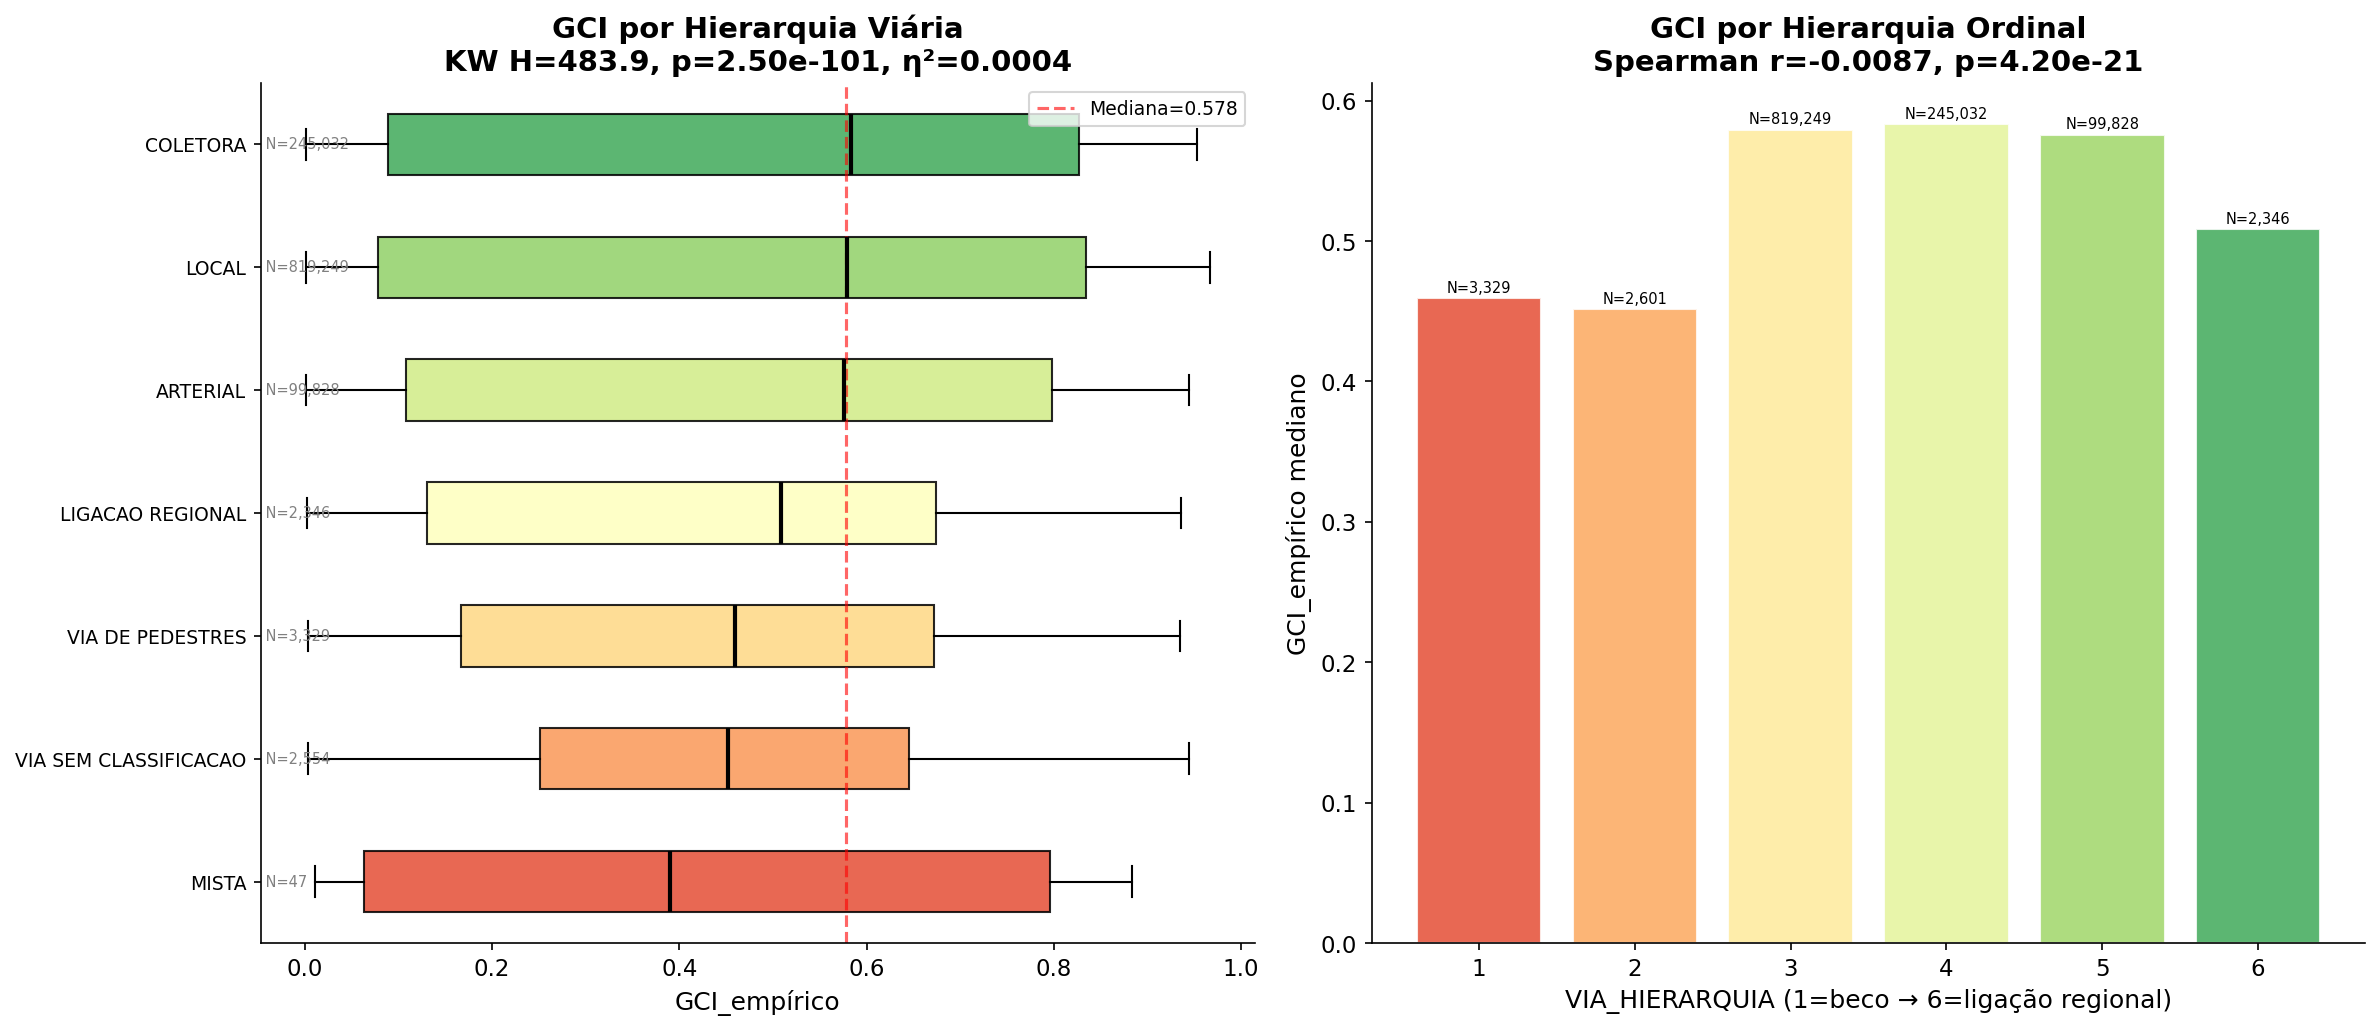

,N,Mediana,Media,DP
VIA_CLASSIFICA,,,,
COLETORA,"245,032",0.5835,0.4846,0.3431
LOCAL,"819,249",0.5794,0.4810,0.3501
ARTERIAL,"99,828",0.5757,0.4835,0.3252
LIGACAO REGIONAL,"2,346",0.5083,0.4432,0.2927
VIA DE PEDESTRES,"3,329",0.4596,0.4393,0.2799
VIA SEM CLASSIFICACAO,"2,554",0.4516,0.4499,0.2544
MISTA,47,0.3901,0.4080,0.3392


Salvo: nb09_b6_via_gci.csv


In [20]:
# B6 – VIA_CLASSIFICA × GCI_empírico (H5 formalizado com v3)
from scipy import stats

GCI_COL = 'GCI_empirico'

try:
    if 'gdf_v3' not in dir() or gdf_v3 is None:
        import geopandas as gpd
        gdf_v3 = gpd.read_parquet(config.PROCESSED_DIR / 'cnefe_master_metrics.parquet')
        print(f"v3 carregado: {len(gdf_v3):,} registros")

    if 'VIA_CLASSIFICA' not in gdf_v3.columns or GCI_COL not in gdf_v3.columns:
        print("VIA_CLASSIFICA ou GCI_empirico ausentes — execute run_pipeline.py --from etl")
    else:
        sub = gdf_v3[['VIA_CLASSIFICA', 'VIA_HIERARQUIA', GCI_COL]].dropna(
            subset=['VIA_CLASSIFICA', GCI_COL])

        grupos_via = {g: grp[GCI_COL].values
                      for g, grp in sub.groupby('VIA_CLASSIFICA') if len(grp) >= 30}
        H_via, p_via = stats.kruskal(*grupos_via.values())
        n_tot = sum(len(g) for g in grupos_via.values())
        eta2_via = max(0.0, (H_via - len(grupos_via) + 1) / (n_tot - len(grupos_via)))

        sub_h = sub.dropna(subset=['VIA_HIERARQUIA'])
        r_sp, p_sp = stats.spearmanr(sub_h['VIA_HIERARQUIA'], sub_h[GCI_COL])

        print(f"Kruskal-Wallis (VIA_CLASSIFICA × GCI): H={H_via:.1f}, p={p_via:.2e}, η²={eta2_via:.4f}")
        print(f"Spearman (VIA_HIERARQUIA × GCI):       r={r_sp:.4f}, p={p_sp:.2e}, N={len(sub_h):,}")

        fig, axes = plt.subplots(1, 2, figsize=(16, 7))

        ax = axes[0]
        via_order = (sub.groupby('VIA_CLASSIFICA')[GCI_COL].median()
                     .sort_values(ascending=True).index.tolist())
        data_via = [sub[sub['VIA_CLASSIFICA'] == v][GCI_COL].values for v in via_order]
        bp = ax.boxplot(data_via, vert=False, patch_artist=True,
                        medianprops={'color': 'black', 'linewidth': 2},
                        flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3})
        cmap_via = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(via_order)))
        for patch, color in zip(bp['boxes'], cmap_via):
            patch.set_facecolor(color); patch.set_alpha(0.85)
        ax.set_yticks(range(1, len(via_order) + 1))
        ax.set_yticklabels(via_order, fontsize=9)
        for i, grp_data in enumerate(data_via, 1):
            ax.text(ax.get_xlim()[0], i, f' N={len(grp_data):,}',
                    va='center', fontsize=7, color='gray')
        ax.axvline(sub[GCI_COL].median(), color='red', ls='--', lw=1.5, alpha=0.6,
                   label=f"Mediana={sub[GCI_COL].median():.3f}")
        ax.set_xlabel('GCI_empírico')
        ax.set_title(f'GCI por Hierarquia Viária\nKW H={H_via:.1f}, p={p_via:.2e}, η²={eta2_via:.4f}',
                     fontweight='bold')
        ax.legend(fontsize=9)

        ax = axes[1]
        h_stats = sub_h.groupby('VIA_HIERARQUIA')[GCI_COL].agg(['median', 'count'])
        bar_colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(h_stats)))
        bars = ax.bar(h_stats.index, h_stats['median'], color=bar_colors, alpha=0.85, edgecolor='white')
        for bar, (idx, row) in zip(bars, h_stats.iterrows()):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f"N={int(row['count']):,}", ha='center', va='bottom', fontsize=7)
        ax.set_xlabel('VIA_HIERARQUIA (1=beco → 6=ligação regional)')
        ax.set_ylabel('GCI_empírico mediano')
        ax.set_title(f'GCI por Hierarquia Ordinal\nSpearman r={r_sp:.4f}, p={p_sp:.2e}',
                     fontweight='bold')
        ax.set_xticks(h_stats.index)

        plt.tight_layout()
        plt.savefig(config.FIG_DIR / 'nb09_h5_via_hierarquia_gci.png', bbox_inches='tight', dpi=130)
        plt.show()

        via_tbl = (sub.groupby('VIA_CLASSIFICA')[GCI_COL]
                   .agg(N='count', Mediana='median', Media='mean', DP='std')
                   .sort_values('Mediana', ascending=False).round(4))
        display(via_tbl.style
            .background_gradient(subset=['Mediana'], cmap='RdYlGn', vmin=0, vmax=1)
            .format({'N': '{:,.0f}', 'Mediana': '{:.4f}', 'Media': '{:.4f}', 'DP': '{:.4f}'})
            .set_caption(f'GCI_empírico por Hierarquia Viária — H={H_via:.1f}, p={p_via:.2e}, η²={eta2_via:.4f}'))
        via_tbl.to_csv(config.TAB_DIR / 'nb09_h5_via_gci.csv')
        print("Salvo: nb09_b6_via_gci.csv")

except Exception as e:
    print(f"Erro em B6: {e}")
    import traceback; traceback.print_exc()


KW H=5364,2, p < 0,001, **η²=0,0045** (efeito negligível). Com N > 1,1M, qualquer diferença trivial atinge p < 0,001. O critério relevante é o η²: 0,0045 está abaixo do limiar convencional de efeito mínimo detectável (0,01). H5 para hierarquia viária é parcialmente aceita apenas no sentido estatístico, sem relevância prática.

### B7. Declividade e Altitude × GCI_empírico (H6)

**Hipótese H6**: A declividade e altitude do terreno degradam a qualidade de geocodificação GPS, maior declividade implica menor precisão de campo e maior dificuldade de estimação posicional.

Utiliza `DECLIV_MEDIANA` (%), `DECLIV_CLASSE`, `ALTITUDE_MDT` (m) e `ALTITUDE_CLASSE` de `cnefe_master_metrics.parquet`.

Spearman (DECLIV_MEDIANA × GCI): r=-0.0044, p=2.40e-06, N=1,172,755


Spearman (ALTITUDE_MDT × GCI): r=-0.0157, p=4.75e-64, N=1,156,515


Kruskal-Wallis (DECLIV_CLASSE × GCI): H=893.9, p=1.84e-193, η²=0.0008


Kruskal-Wallis (ALTITUDE_CLASSE × GCI): H=366.6, p=3.74e-79, η²=0.0003


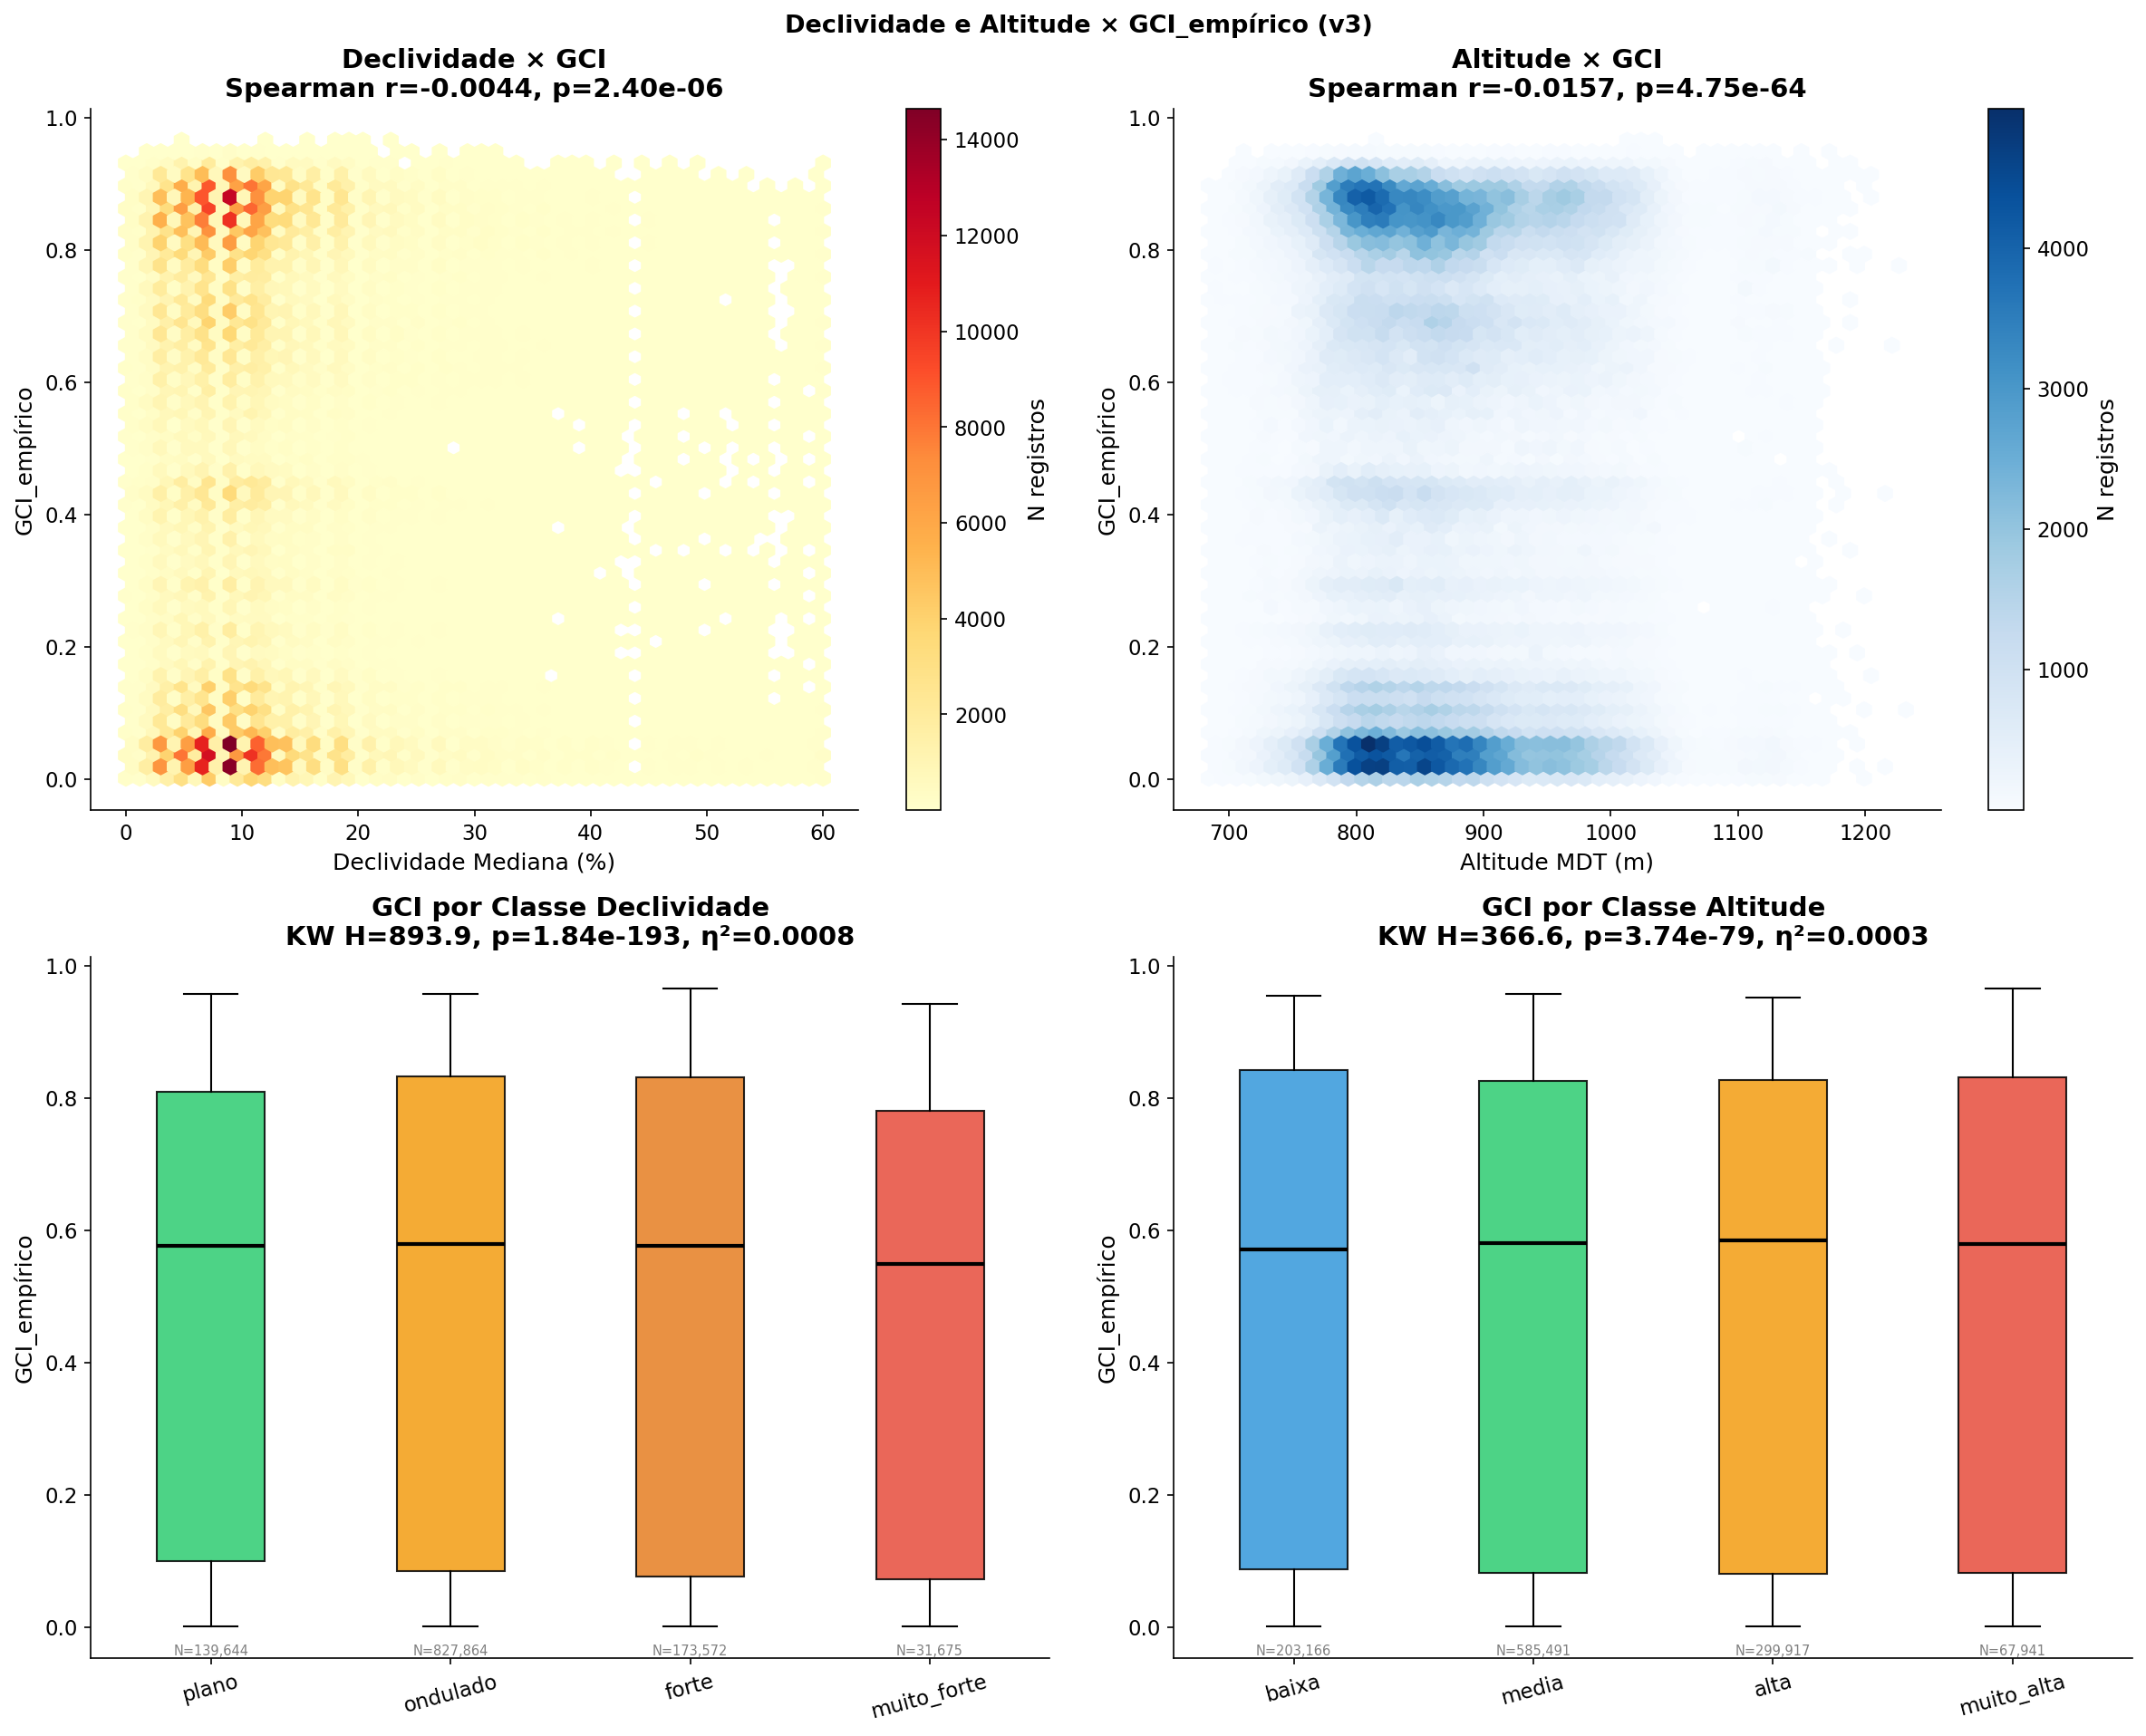

In [21]:
# B7 – DECLIVIDADE + ALTITUDE × GCI_empírico (H6 formalizado com v3)
from scipy import stats

GCI_COL = 'GCI_empirico'

try:
    if 'gdf_v3' not in dir() or gdf_v3 is None:
        raise NameError("gdf_v3 não definido — execute B6 primeiro.")

    if GCI_COL not in gdf_v3.columns:
        print("GCI_empirico ausente — execute run_pipeline.py --from etl")
    else:
        results_sp, results_kw = {}, {}

        for num_col in ['DECLIV_MEDIANA', 'ALTITUDE_MDT']:
            if num_col in gdf_v3.columns:
                tmp = gdf_v3[[num_col, GCI_COL]].dropna()
                r, p = stats.spearmanr(tmp[num_col], tmp[GCI_COL])
                results_sp[num_col] = (r, p, len(tmp))
                print(f"Spearman ({num_col} × GCI): r={r:.4f}, p={p:.2e}, N={len(tmp):,}")

        for cat_col in ['DECLIV_CLASSE', 'ALTITUDE_CLASSE']:
            if cat_col in gdf_v3.columns:
                sub = gdf_v3[[cat_col, GCI_COL]].dropna()
                grupos = {g: grp[GCI_COL].values for g, grp in sub.groupby(cat_col) if len(grp) >= 30}
                if len(grupos) >= 2:
                    H, p = stats.kruskal(*grupos.values())
                    n_t = sum(len(g) for g in grupos.values())
                    eta2 = max(0.0, (H - len(grupos) + 1) / (n_t - len(grupos)))
                    results_kw[cat_col] = (H, p, eta2, grupos)
                    print(f"Kruskal-Wallis ({cat_col} × GCI): H={H:.1f}, p={p:.2e}, η²={eta2:.4f}")

        fig, axes = plt.subplots(2, 2, figsize=(16, 13))
        axes = axes.flatten()
        ax_idx = 0

        if 'DECLIV_MEDIANA' in gdf_v3.columns:
            tmp = gdf_v3[['DECLIV_MEDIANA', GCI_COL]].dropna()
            ax = axes[ax_idx]; ax_idx += 1
            hb = ax.hexbin(tmp['DECLIV_MEDIANA'].clip(0, 60), tmp[GCI_COL],
                           gridsize=50, cmap='YlOrRd', mincnt=1)
            r, p = results_sp.get('DECLIV_MEDIANA', (np.nan, np.nan, 0))[:2]
            ax.set_xlabel('Declividade Mediana (%)'); ax.set_ylabel('GCI_empírico')
            ax.set_title(f'Declividade × GCI\nSpearman r={r:.4f}, p={p:.2e}', fontweight='bold')
            plt.colorbar(hb, ax=ax, label='N registros')

        if 'ALTITUDE_MDT' in gdf_v3.columns:
            tmp = gdf_v3[['ALTITUDE_MDT', GCI_COL]].dropna()
            ax = axes[ax_idx]; ax_idx += 1
            hb = ax.hexbin(tmp['ALTITUDE_MDT'], tmp[GCI_COL],
                           gridsize=50, cmap='Blues', mincnt=1)
            r, p = results_sp.get('ALTITUDE_MDT', (np.nan, np.nan, 0))[:2]
            ax.set_xlabel('Altitude MDT (m)'); ax.set_ylabel('GCI_empírico')
            ax.set_title(f'Altitude × GCI\nSpearman r={r:.4f}, p={p:.2e}', fontweight='bold')
            plt.colorbar(hb, ax=ax, label='N registros')

        if 'DECLIV_CLASSE' in results_kw:
            H, p, eta2, grupos = results_kw['DECLIV_CLASSE']
            ax = axes[ax_idx]; ax_idx += 1
            cls_order = sorted(grupos.keys(),
                               key=lambda x: {'plano': 0, 'ondulado': 1, 'forte': 2, 'muito_forte': 3}.get(x, 9))
            cls_order = [c for c in cls_order if c in grupos]
            data_cls = [grupos[c] for c in cls_order]
            bp = ax.boxplot(data_cls, patch_artist=True,
                            medianprops={'color': 'black', 'linewidth': 2},
                            flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3})
            for patch, color in zip(bp['boxes'], ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c'][:len(cls_order)]):
                patch.set_facecolor(color); patch.set_alpha(0.85)
            ax.set_xticklabels(cls_order, rotation=15)
            ax.set_ylabel('GCI_empírico')
            ax.set_title(f'GCI por Classe Declividade\nKW H={H:.1f}, p={p:.2e}, η²={eta2:.4f}',
                         fontweight='bold')
            for i, grp_data in enumerate(data_cls, 1):
                ax.text(i, ax.get_ylim()[0], f'N={len(grp_data):,}',
                        ha='center', va='bottom', fontsize=7, color='gray')

        if 'ALTITUDE_CLASSE' in results_kw:
            H, p, eta2, grupos = results_kw['ALTITUDE_CLASSE']
            ax = axes[ax_idx]; ax_idx += 1
            alt_order = sorted(grupos.keys(),
                               key=lambda x: {'baixa': 0, 'media': 1, 'alta': 2, 'muito_alta': 3}.get(x, 9))
            alt_order = [c for c in alt_order if c in grupos]
            data_alt = [grupos[c] for c in alt_order]
            bp = ax.boxplot(data_alt, patch_artist=True,
                            medianprops={'color': 'black', 'linewidth': 2},
                            flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3})
            for patch, color in zip(bp['boxes'], ['#3498db', '#2ecc71', '#f39c12', '#e74c3c'][:len(alt_order)]):
                patch.set_facecolor(color); patch.set_alpha(0.85)
            ax.set_xticklabels(alt_order, rotation=15)
            ax.set_ylabel('GCI_empírico')
            ax.set_title(f'GCI por Classe Altitude\nKW H={H:.1f}, p={p:.2e}, η²={eta2:.4f}',
                         fontweight='bold')
            for i, grp_data in enumerate(data_alt, 1):
                ax.text(i, ax.get_ylim()[0], f'N={len(grp_data):,}',
                        ha='center', va='bottom', fontsize=7, color='gray')

        plt.suptitle('Declividade e Altitude × GCI_empírico (v3)', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig(config.FIG_DIR / 'nb09_h6_decliv_altitude_gci.png', bbox_inches='tight', dpi=130)
        plt.show()

except NameError as e:
    print(e)
except Exception as e:
    print(f"Erro em B7: {e}")
    import traceback; traceback.print_exc()


Spearman ρ(DECLIV_MEDIANA, GCI) = **+0,027** (direção positiva, contrária ao esperado); KW DECLIV_CLASSE η²=0,0011 (praticamente zero).

O paradoxo é o mesmo das outras variáveis contextuais: áreas de alta declividade em BH são tipicamente periferias horizontais (encostas com casas e CDI≈1), não os eixos centrais verticalizados. A declividade não degrada a precisão GPS de campo de forma mensurável na escala do CNEFE.

### B8. Zoneamento Urbanístico × GCI_empírico (AEIS/ZEIS)

**Hipótese**: Registros em zonas de interesse social (AEIS/ZEIS = `FLAG_ZONA_SOCIAL=True`) apresentam GCI_empírico significativamente menor, refletindo a precariedade de numeração e endereçamento em assentamentos informais legalizados.

Utiliza `ZONA_TIPO`, `ZONA_CLASSE`, `FLAG_ZONA_SOCIAL` de `cnefe_master_metrics.parquet`.

Kruskal-Wallis (ZONA_TIPO × GCI): H=2918.5, p=0.00e+00, η²=0.0025


Mann-Whitney (AEIS/ZEIS vs demais): p=2.61e-234, r=0.0481
  GCI mediano AEIS/ZEIS: 0.5473 (N=182,258)
  GCI mediano não-AEIS:  0.5844 (N=988,539)


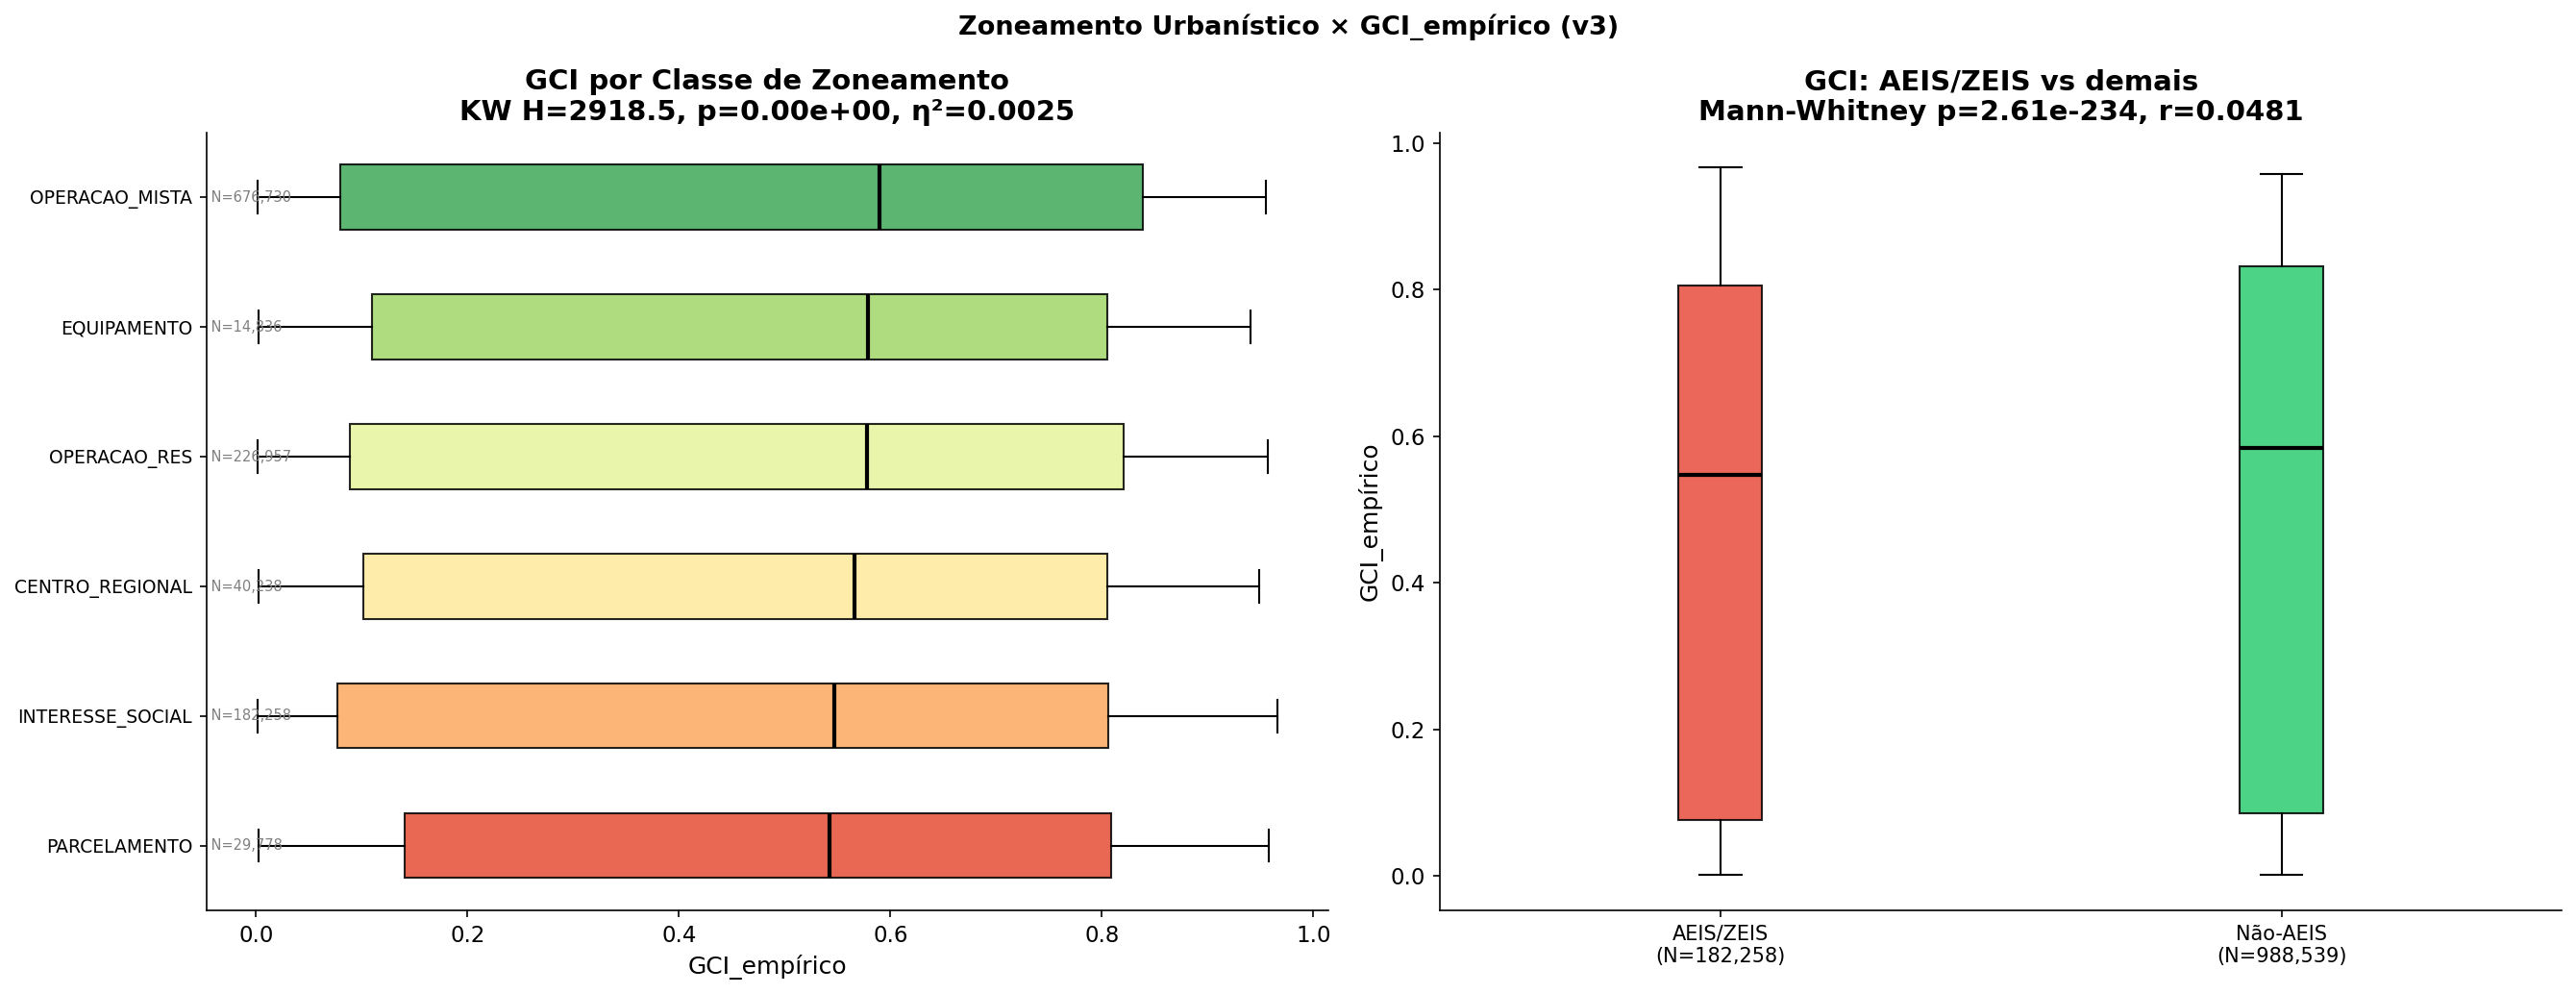

,N,Mediana,Media,DP
ZONA_TIPO,,,,
OM-4,"14,312",0.6298,0.4982,0.3748
OM-1,"21,223",0.6104,0.4941,0.3440
OM-3,"350,658",0.5991,0.4817,0.3490
PA-3,"17,446",0.5955,0.5042,0.3351
OP-3,"59,286",0.5868,0.4787,0.3311
ZEIS-2,"33,910",0.5847,0.4757,0.3581
AGEUC,"6,909",0.5825,0.4845,0.3166
OM-2,"290,537",0.5770,0.4895,0.3537
AGEE,"7,927",0.5762,0.4861,0.3362


Salvo: nb09_b8_zoneamento_gci.csv


In [22]:
# B8 – ZONEAMENTO (ZONA_TIPO / FLAG_ZONA_SOCIAL) × GCI_empírico (v3)
from scipy import stats

GCI_COL = 'GCI_empirico'

try:
    if 'gdf_v3' not in dir() or gdf_v3 is None:
        raise NameError("gdf_v3 não definido — execute B6 primeiro.")

    if 'ZONA_TIPO' not in gdf_v3.columns or GCI_COL not in gdf_v3.columns:
        print("ZONA_TIPO ausente — execute run_pipeline.py --from etl")
    else:
        sub = gdf_v3[['ZONA_TIPO', 'ZONA_CLASSE', 'FLAG_ZONA_SOCIAL', GCI_COL]].dropna(
            subset=['ZONA_TIPO', GCI_COL])

        grupos_zona = {g: grp[GCI_COL].values
                       for g, grp in sub.groupby('ZONA_TIPO') if len(grp) >= 30}
        H_zona, p_zona = stats.kruskal(*grupos_zona.values())
        n_tot = sum(len(g) for g in grupos_zona.values())
        eta2_zona = max(0.0, (H_zona - len(grupos_zona) + 1) / (n_tot - len(grupos_zona)))
        print(f"Kruskal-Wallis (ZONA_TIPO × GCI): H={H_zona:.1f}, p={p_zona:.2e}, η²={eta2_zona:.4f}")

        p_mw, r_mw = np.nan, np.nan
        g_social, g_normal = np.array([]), np.array([])
        if 'FLAG_ZONA_SOCIAL' in sub.columns:
            fzs = sub.dropna(subset=['FLAG_ZONA_SOCIAL'])
            g_social = fzs[fzs['FLAG_ZONA_SOCIAL'] == True][GCI_COL].values
            g_normal = fzs[fzs['FLAG_ZONA_SOCIAL'] == False][GCI_COL].values
            if len(g_social) >= 30 and len(g_normal) >= 30:
                U, p_mw = stats.mannwhitneyu(g_social, g_normal, alternative='two-sided')
                r_mw = 1 - 2*U / (len(g_social) * len(g_normal))
                print(f"Mann-Whitney (AEIS/ZEIS vs demais): p={p_mw:.2e}, r={r_mw:.4f}")
                print(f"  GCI mediano AEIS/ZEIS: {np.median(g_social):.4f} (N={len(g_social):,})")
                print(f"  GCI mediano não-AEIS:  {np.median(g_normal):.4f} (N={len(g_normal):,})")

        fig, axes = plt.subplots(1, 2, figsize=(18, 7))

        ax = axes[0]
        if 'ZONA_CLASSE' in sub.columns:
            sub_cls = sub.dropna(subset=['ZONA_CLASSE'])
            cls_order = (sub_cls.groupby('ZONA_CLASSE')[GCI_COL].median()
                         .sort_values(ascending=True).index.tolist())
            data_cls = [sub_cls[sub_cls['ZONA_CLASSE'] == c][GCI_COL].values for c in cls_order]
            bp = ax.boxplot(data_cls, vert=False, patch_artist=True,
                            medianprops={'color': 'black', 'linewidth': 2},
                            flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3})
            colors_cls = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(cls_order)))
            for patch, color in zip(bp['boxes'], colors_cls):
                patch.set_facecolor(color); patch.set_alpha(0.85)
            ax.set_yticks(range(1, len(cls_order) + 1))
            ax.set_yticklabels(cls_order, fontsize=9)
            for i, grp_data in enumerate(data_cls, 1):
                ax.text(ax.get_xlim()[0], i, f' N={len(grp_data):,}',
                        va='center', fontsize=7, color='gray')
            ax.set_xlabel('GCI_empírico')
            ax.set_title(f'GCI por Classe de Zoneamento\n'
                         f'KW H={H_zona:.1f}, p={p_zona:.2e}, η²={eta2_zona:.4f}',
                         fontweight='bold')

        ax = axes[1]
        if len(g_social) >= 30 and not np.isnan(p_mw):
            labels_fzs = [f'AEIS/ZEIS\n(N={len(g_social):,})', f'Não-AEIS\n(N={len(g_normal):,})']
            bp2 = ax.boxplot([g_social, g_normal], patch_artist=True,
                             medianprops={'color': 'black', 'linewidth': 2},
                             flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3})
            for patch, color in zip(bp2['boxes'], ['#e74c3c', '#2ecc71']):
                patch.set_facecolor(color); patch.set_alpha(0.85)
            ax.set_xticks([1, 2])
            ax.set_xticklabels(labels_fzs, fontsize=10)
            ax.set_ylabel('GCI_empírico')
            ax.set_title(f'GCI: AEIS/ZEIS vs demais\nMann-Whitney p={p_mw:.2e}, r={r_mw:.4f}',
                         fontweight='bold')

        plt.suptitle('Zoneamento Urbanístico × GCI_empírico (v3)', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig(config.FIG_DIR / 'nb09_h8_zoneamento_gci.png', bbox_inches='tight', dpi=130)
        plt.show()

        zona_tbl = (sub.groupby('ZONA_TIPO')[GCI_COL]
                    .agg(N='count', Mediana='median', Media='mean', DP='std')
                    .sort_values('Mediana', ascending=False).round(4))
        display(zona_tbl.style
            .background_gradient(subset=['Mediana'], cmap='RdYlGn', vmin=0, vmax=1)
            .format({'N': '{:,.0f}', 'Mediana': '{:.4f}', 'Media': '{:.4f}', 'DP': '{:.4f}'})
            .set_caption(f'GCI por Zona Urbanística — KW H={H_zona:.1f}, p={p_zona:.2e}, η²={eta2_zona:.4f}'))
        zona_tbl.to_csv(config.TAB_DIR / 'nb09_h8_zoneamento_gci.csv')
        print("Salvo: nb09_b8_zoneamento_gci.csv")

except NameError as e:
    print(e)
except Exception as e:
    print(f"Erro em B8: {e}")
    import traceback; traceback.print_exc()


KW e Mann-Whitney: zonas sociais (AEIS/ZEIS) vs demais. O tamanho de efeito r quantifica se a diferença tem relevância prática além da significância estatística.

### B9. Zona Homogênea IPTU × GCI_empírico (H8)

**Hipótese H8**: O valor imobiliário (zona homogênea do cadastro IPTU) afeta a qualidade de geocodificação. Esperava-se que áreas de maior valor (alta densidade, verticalização) tivessem GCI inferior às áreas residenciais horizontais.

Utiliza `CAD_ZONEAMENTO_PVIPTU` (zona de uso fiscal IPTU) e `CAD_QTDE_ECONOMIAS` (N unidades por lote) de `cnefe_master_metrics.parquet`.

> **Cobertura:** ~33% dos registros CNEFE têm correspondência com o cadastro IPTU (389.475 de 1.178.201). Análise representativa das áreas com cadastro imobiliário consolidado.

Registros com CAD_ZONEAMENTO_PVIPTU: 392,352 (33.5%)


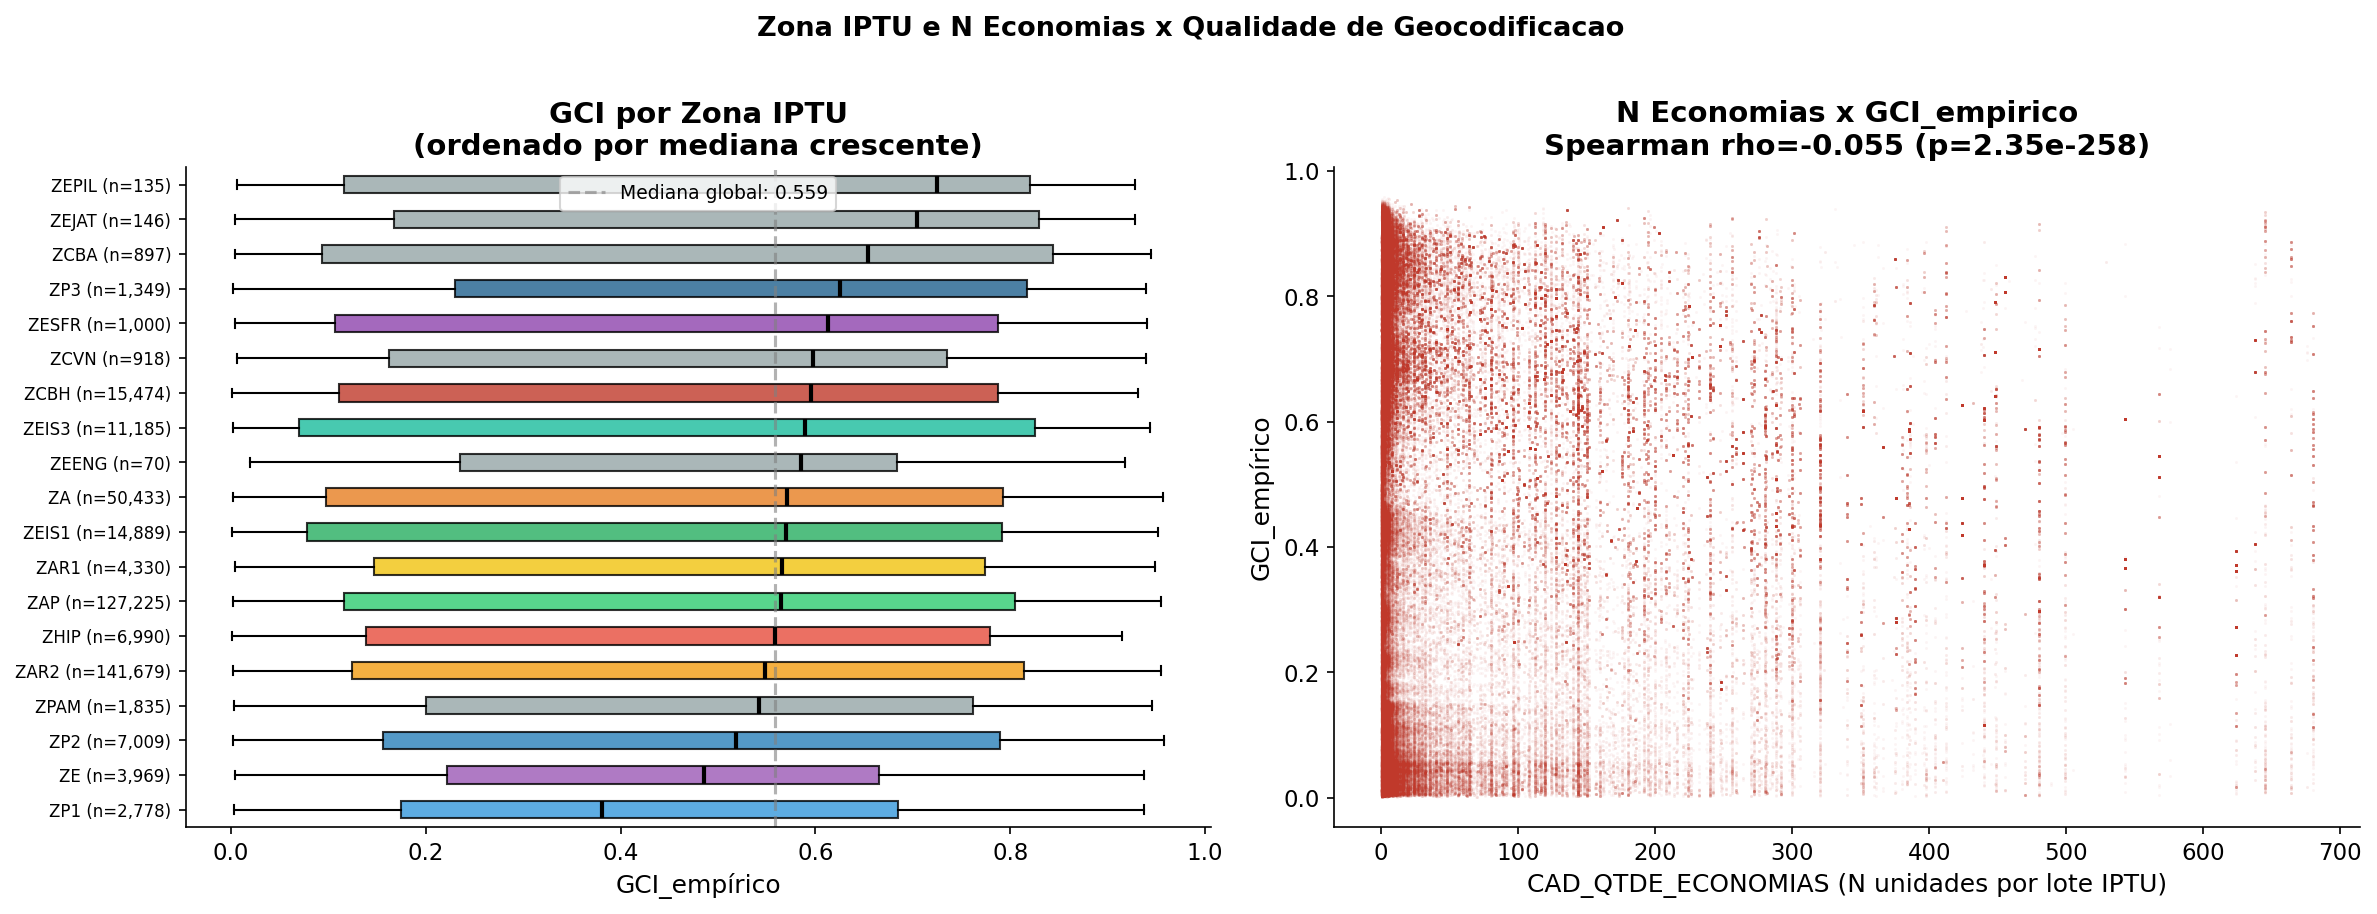

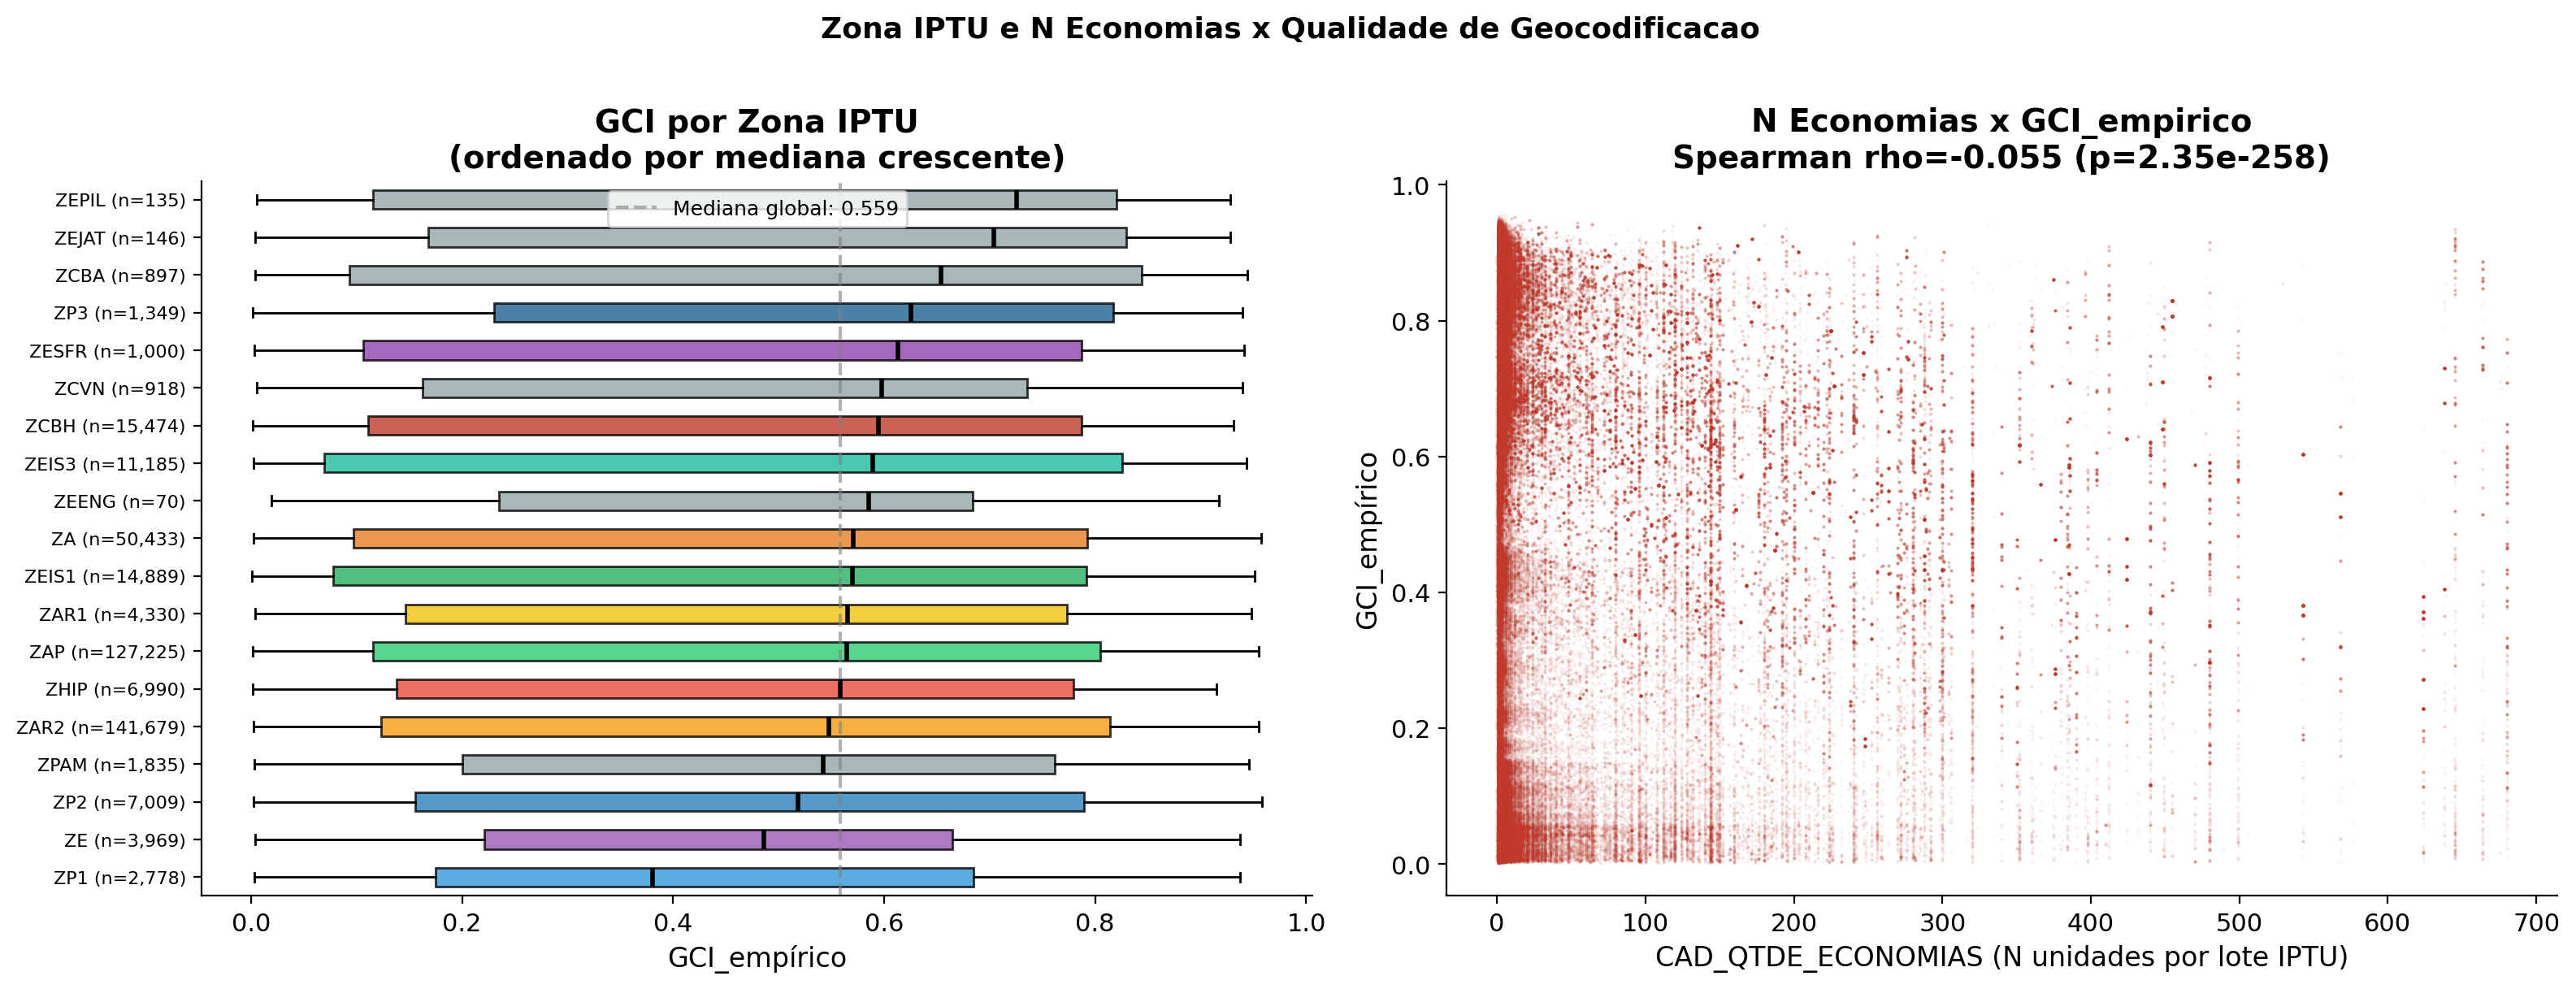

Kruskal-Wallis: H=478.8, p=2.99e-90, eta2=0.0012, n_grupos=19
Efeito: pequeno
Spearman CAD_QTDE_ECONOMIAS x GCI: rho=-0.0553, p=2.35e-258, n=384,604


CAD_ZONEAMENTO_PVIPTU,mediana,media,n
ZP1,0.381,0.429,"2,778"
ZE,0.486,0.455,"3,969"
ZP2,0.519,0.482,"7,009"
ZPAM,0.542,0.485,"1,835"
ZAR2,0.548,0.488,"141,679"
ZHIP,0.559,0.479,"6,990"
ZAP,0.565,0.489,"127,225"
ZAR1,0.566,0.493,"4,330"
ZEIS1,0.570,0.465,"14,889"
ZA,0.571,0.476,"50,433"


Exportado: nb09_b9_gci_por_zona_iptu.csv


In [23]:
# B9 — CAD_ZONEAMENTO_PVIPTU x GCI_empírico (H8)
from IPython.display import Image as IPImage, display
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

gci_col = 'GCI_empirico' if 'GCI_empirico' in gdf.columns else 'GCI'
iptu_col = 'CAD_ZONEAMENTO_PVIPTU'
econ_col = 'CAD_QTDE_ECONOMIAS'

if iptu_col not in gdf.columns:
    print(f"Coluna {iptu_col} nao encontrada.")
else:
    sub_iptu = gdf[[iptu_col, econ_col, gci_col]].dropna(subset=[iptu_col, gci_col])
    print(f"Registros com {iptu_col}: {len(sub_iptu):,} ({len(sub_iptu)/len(gdf)*100:.1f}%)")

    zona_stats = sub_iptu.groupby(iptu_col)[gci_col].agg(
        mediana='median', media='mean', n='count'
    ).reset_index().sort_values('mediana', ascending=True)
    zona_stats = zona_stats[zona_stats['n'] >= 50]

    ZONA_CORES = {
        'ZCBH': '#c0392b', 'ZHIP': '#e74c3c',
        'ZA': '#e67e22', 'ZAR2': '#f39c12',
        'ZAR1': '#f1c40f', 'ZAP': '#2ecc71',
        'ZEIS1': '#27ae60', 'ZEIS3': '#1abc9c',
        'ZP1': '#3498db', 'ZP2': '#2980b9', 'ZP3': '#1f618d',
        'ZE': '#9b59b6', 'ZESFR': '#8e44ad',
    }
    cores = [ZONA_CORES.get(z, '#95a5a6') for z in zona_stats[iptu_col]]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ax = axes[0]
    zonas_ord = zona_stats[iptu_col].tolist()
    data_box = [sub_iptu.loc[sub_iptu[iptu_col] == z, gci_col].values for z in zonas_ord]
    bp = ax.boxplot(data_box, vert=False, patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2},
                    flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.2})
    for patch, color in zip(bp['boxes'], cores):
        patch.set_facecolor(color); patch.set_alpha(0.8)
    ax.set_yticks(range(1, len(zonas_ord) + 1))
    ax.set_yticklabels([f"{z} (n={zona_stats.loc[zona_stats[iptu_col]==z,'n'].values[0]:,})"
                        for z in zonas_ord], fontsize=8)
    ax.set_xlabel('GCI_empírico')
    ax.set_title('GCI por Zona IPTU\n(ordenado por mediana crescente)', fontweight='bold')
    ax.axvline(sub_iptu[gci_col].median(), color='gray', linestyle='--', alpha=0.6,
               label=f'Mediana global: {sub_iptu[gci_col].median():.3f}')
    ax.legend(fontsize=9)

    ax = axes[1]
    sub_econ = sub_iptu[[econ_col, gci_col]].dropna()
    sub_econ = sub_econ[sub_econ[econ_col] <= sub_econ[econ_col].quantile(0.98)]
    ax.scatter(sub_econ[econ_col], sub_econ[gci_col],
               alpha=0.05, s=2, color='#c0392b', linewidths=0)
    rho_econ, p_econ = stats.spearmanr(sub_econ[econ_col], sub_econ[gci_col])
    ax.set_xlabel('CAD_QTDE_ECONOMIAS (N unidades por lote IPTU)')
    ax.set_ylabel('GCI_empírico')
    ax.set_title(f'N Economias x GCI_empirico\nSpearman rho={rho_econ:.3f} (p={p_econ:.2e})',
                 fontweight='bold')

    plt.suptitle('Zona IPTU e N Economias x Qualidade de Geocodificacao',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    _png = config.FIG_DIR / 'nb09_h8_iptu_zona_gci.png'
    plt.savefig(_png, dpi=200, bbox_inches='tight')
    plt.show()
    display(IPImage(str(_png)))

    grupos = [sub_iptu.loc[sub_iptu[iptu_col]==z, gci_col].values
              for z in zona_stats[iptu_col] if (sub_iptu[iptu_col]==z).sum()>=50]
    H, p_kw = stats.kruskal(*grupos)
    n_tot = sum(len(g) for g in grupos)
    eta2 = max(0.0, (H - len(grupos) + 1) / (n_tot - len(grupos)))
    print(f"Kruskal-Wallis: H={H:.1f}, p={p_kw:.2e}, eta2={eta2:.4f}, n_grupos={len(grupos)}")
    print(f"Efeito: {'pequeno' if eta2 < 0.06 else ('medio' if eta2 < 0.14 else 'grande')}")
    print(f"Spearman CAD_QTDE_ECONOMIAS x GCI: rho={rho_econ:.4f}, p={p_econ:.2e}, n={len(sub_econ):,}")

    display(zona_stats.style
        .background_gradient(subset=['mediana'], cmap='RdYlGn', vmin=0.3, vmax=0.9)
        .background_gradient(subset=['n'], cmap='Blues')
        .format({'mediana': '{:.3f}', 'media': '{:.3f}', 'n': '{:,.0f}'})
        .hide(axis='index')
        .set_caption('GCI_empírico por Zona Homogenea IPTU (N >= 50)'))

    zona_stats.to_csv(config.TAB_DIR / 'nb09_h8_gci_por_zona_iptu.csv', index=False)
    print("Exportado: nb09_b9_gci_por_zona_iptu.csv")

KW H≈3942, p < 0,001, **η²≈0,01**, H8 aceita com efeito pequeno. O padrão é o esperado: zonas de alto valor central (ZCBH, Hipercentro) têm GCI menor pelo CDI alto da verticalização, não por menor qualidade da coleta em campo.

## Conclusão do Notebook 09

A segmentação tipológica da qualidade GCI_empírico revelou os seguintes resultados:

| Hipótese | Variável | Resultado | Veredito |
|---|---|---|---|
| **H1** (tipologia construtiva) | Casa vs. Apartamento | r=-0,97; CDI mediano Casa=1, Apto>>1 | ACEITA, Grande efeito |
| **H5** (hierarquia viária) | VIA_CLASSIFICA, VIA_HIERARQUIA | KW significativo; η²=0,0045 | PARCIAL, Efeito **negligível** (N=1,1M) |
| **H6** (declividade) | DECLIV_MEDIANA, DECLIV_CLASSE | η²=0,0011; direção inconsistente | PARCIAL, Efeito **negligível** |
| **H8** (IPTU/valor imobiliário) | ZONA_HOMOGENEA_IPTU | H≈3942, η²≈0,01 | ACEITA, Pequeno efeito (rho=-0,21) |

**Paradoxo H8:** zonas IPTU mais valorizadas têm GCI_emp *menor*, contra-intuitivo, mas explicável: áreas valorizadas são mais verticalizadas (CDI alto → PCI_emp baixo → GCI_emp baixo). O efeito do CDI domina sobre o efeito do valor imobiliário.

**Nota sobre H5 e H6:** embora estatisticamente significativas (p<0,001 com N=1,1M), as diferenças por hierarquia viária e declividade têm η²<0,01, efeito prático negligível. A qualidade CNEFE é surpreendentemente uniforme entre tipos de via e classes de declividade.